<div style="
    display:flex;
    justify-content:center;
    align-items:center;
    width:78%;
    margin:40px auto;
    border-radius:14px;
    background: linear-gradient(45deg, #8a2be2, #ff3cac, #2bd2ff, #8a2be2);
    background-size: 300% 300%;
    animation: borderFlow 7s linear infinite;
    padding:2px;
    box-sizing:border-box;
">
  <div style="
      display:flex;
      align-items:center;
      justify-content:center;
      flex-wrap:wrap;
      gap:22px;
      background: linear-gradient(90deg, rgba(18,18,28,0.96), rgba(28,18,40,0.96));
      color: white;
      font-family: 'Segoe UI', Arial, sans-serif;
      font-size: 25px;
      font-weight: 650;
      letter-spacing: 1px;
      padding: 20px 34px;
      border-radius: 12px;
      width: 100%;
      height: 100%;
      box-sizing:border-box;
  ">
    <img src="assets/img/logo.png"
         alt="Logo La poule qui chante"
         style="height:120px; width:auto; filter: drop-shadow(0 0 10px rgba(255,195,90,0.30));">
    <div style="text-align:center;">
      <div style="font-size:30px; font-weight:700; letter-spacing:1px;">
        La poule qui chante
      </div>
      <span style="font-size:22px; opacity:0.95;">
        ACP, segmentation des pays et recommandations stratégiques
      </span><br>
      <span style="font-size:16px; opacity:0.78; letter-spacing:0.4px;">
        PCA, clustering and country targeting strategy
      </span>
    </div>
  </div>
</div>

<style>
@keyframes borderFlow {
  0% { background-position: 0% 50%; }
  50% { background-position: 100% 50%; }
  100% { background-position: 0% 50%; }
}
</style>

# 🎯 Objectif du notebook 2 • ACP & clustering 🌍

Ce notebook a pour objectif d’exploiter le dataset préparé dans le notebook 1 afin de :

- réduire la dimension de l’information via une **ACP** ;
- visualiser les relations entre variables et les proximités entre pays ;
- construire une **segmentation de pays** cohérente ;
- proposer des **recommandations de ciblage** pour l’entreprise **La poule qui chante**.

---

## 🧠 Finalité métier

L’enjeu n’est pas seulement statistique.  
L’objectif est de faire émerger des **groupes de pays aux profils comparables**, afin d’aider la direction à :

- prioriser certains marchés ;
- éviter une approche pays par pays trop coûteuse ;
- structurer une future stratégie d’exportation plus ciblée et plus efficace.

---

## 📌 Méthodologie retenue

L’approche suivie repose sur :

1. une **standardisation** des variables ;
2. une **ACP** pour synthétiser l’information ;
3. une **classification ascendante hiérarchique (CAH)** ;
4. un **K-means** pour stabiliser et comparer la segmentation ;
5. une **interprétation business** des groupes obtenus.

<a id="top"></a>

<h2 style="color:RGB(170,90,255);">📘 Sommaire</h2>

<ul style="list-style:none; line-height:1.8; font-size:17px; padding-left:0;">

  <li>
    <a href="#etape1" style="color:RGB(170,90,255); text-decoration:none;">📂 Étape 1 • Importation du dataset final</a>
    <ul style="list-style:none; margin-left:20px;">
      <li><a href="#etape1_1" style="color:RGB(170,90,255); text-decoration:none;">1.1 Importation des librairies</a></li>
      <li><a href="#etape1_2" style="color:RGB(170,90,255); text-decoration:none;">1.2 Chargement du dataset préparé</a></li>
      <li><a href="#etape1_3" style="color:RGB(170,90,255); text-decoration:none;">1.3 Sélection des variables numériques</a></li>
    </ul>
  </li>

  <li>
    <a href="#etape2" style="color:RGB(120,210,255); text-decoration:none;">⚙️ Étape 2 • Standardisation des données</a>
    <ul style="list-style:none; margin-left:20px;">
      <li><a href="#etape2_1" style="color:RGB(120,210,255); text-decoration:none;">2.1 Centrage-réduction</a></li>
      <li><a href="#etape2_2" style="color:RGB(120,210,255); text-decoration:none;">2.2 Vérification de la matrice standardisée</a></li>
    </ul>
  </li>

  <li>
    <a href="#etape3" style="color:RGB(255,170,80); text-decoration:none;">📉 Étape 3 • Analyse en composantes principales (ACP)</a>
    <ul style="list-style:none; margin-left:20px;">
      <li><a href="#etape3_1" style="color:RGB(255,170,80); text-decoration:none;">3.1 Calcul de l’ACP</a></li>
      <li><a href="#etape3_2" style="color:RGB(255,170,80); text-decoration:none;">3.2 Éboulis des valeurs propres</a></li>
      <li><a href="#etape3_3" style="color:RGB(255,170,80); text-decoration:none;">3.3 Choix du nombre d’axes retenus</a></li>
      <li><a href="#etape3_4" style="color:RGB(255,170,80); text-decoration:none;">3.4 Cercle des corrélations</a></li>
      <li><a href="#etape3_5" style="color:RGB(255,170,80); text-decoration:none;">3.5 Projection des individus</a></li>
    </ul>
  </li>

  <li>
    <a href="#etape4" style="color:RGB(120,255,170); text-decoration:none;">🌐 Étape 4 • Lecture et interprétation de l’ACP</a>
    <ul style="list-style:none; margin-left:20px;">
      <li><a href="#etape4_1" style="color:RGB(120,255,170); text-decoration:none;">4.1 Lecture des axes principaux</a></li>
      <li><a href="#etape4_2" style="color:RGB(120,255,170); text-decoration:none;">4.2 Corrélations entre variables</a></li>
      <li><a href="#etape4_3" style="color:RGB(120,255,170); text-decoration:none;">4.3 Positionnement des pays</a></li>
    </ul>
  </li>

  <li>
    <a href="#etape5" style="color:RGB(255,120,190); text-decoration:none;">🌳 Étape 5 • Classification ascendante hiérarchique (CAH)</a>
    <ul style="list-style:none; margin-left:20px;">
      <li><a href="#etape5_1" style="color:RGB(255,120,190); text-decoration:none;">5.1 Calcul de la CAH</a></li>
      <li><a href="#etape5_2" style="color:RGB(255,120,190); text-decoration:none;">5.2 Dendrogramme</a></li>
      <li><a href="#etape5_3" style="color:RGB(255,120,190); text-decoration:none;">5.3 Choix du nombre de clusters</a></li>
    </ul>
  </li>

  <li>
    <a href="#etape6" style="color:RGB(255,210,90); text-decoration:none;">🎯 Étape 6 • Clustering K-means</a>
    <ul style="list-style:none; margin-left:20px;">
      <li><a href="#etape6_1" style="color:RGB(255,210,90); text-decoration:none;">6.1 Méthode du coude / silhouette</a></li>
      <li><a href="#etape6_2" style="color:RGB(255,210,90); text-decoration:none;">6.2 Modèle K-means retenu</a></li>
      <li><a href="#etape6_3" style="color:RGB(255,210,90); text-decoration:none;">6.3 Comparaison avec la CAH</a></li>
    </ul>
  </li>

  <li>
    <a href="#etape7" style="color:RGB(255,120,80); text-decoration:none;">🧩 Étape 7 • Profilage des clusters</a>
    <ul style="list-style:none; margin-left:20px;">
      <li><a href="#etape7_1" style="color:RGB(255,120,80); text-decoration:none;">7.1 Caractéristiques moyennes par cluster</a></li>
      <li><a href="#etape7_2" style="color:RGB(255,120,80); text-decoration:none;">7.2 Pays représentatifs de chaque groupe</a></li>
      <li><a href="#etape7_3" style="color:RGB(255,120,80); text-decoration:none;">7.3 Identification des clusters les plus attractifs</a></li>
    </ul>
  </li>

  <li>
    <a href="#etape8" style="color:RGB(180,255,120); text-decoration:none;">📣 Étape 8 • Recommandations pour le COMEX</a>
    <ul style="list-style:none; margin-left:20px;">
      <li><a href="#etape8_1" style="color:RGB(180,255,120); text-decoration:none;">8.1 Synthèse non technique des résultats</a></li>
      <li><a href="#etape8_2" style="color:RGB(180,255,120); text-decoration:none;">8.2 Groupes de pays à prioriser</a></li>
      <li><a href="#etape8_3" style="color:RGB(180,255,120); text-decoration:none;">8.3 Limites et suites à donner</a></li>
    </ul>
  </li>

  <li>
    <a href="#conclusion2" style="color:RGB(39,245,211); text-decoration:none;">Conclusion du notebook 2</a>
  </li>

</ul>

<a id="etape1"></a>
<div style="
  width:78%;
  margin:16px auto 10px auto;
  border:1px solid rgba(168,85,247,0.34);
  border-radius:14px;
  background:linear-gradient(135deg, rgba(72,8,92,0.96), rgba(44,7,60,0.98));
  box-sizing:border-box;
">
  <h2 style="
    margin:0;
    padding:15px 20px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:22px;
    font-weight:750;
    gap:12px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:24px; height:24px; display:block;
        filter: brightness(0) saturate(100%) invert(82%) sepia(18%) saturate(2017%) hue-rotate(271deg) brightness(101%) contrast(101%);
      ">
    </a>
    <span style="color:#F4B8FF;">📂 Étape 1</span>
    <span>• Importation du dataset final</span>
  </h2>
</div>

<a id="etape1_1"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(196,132,252,0.28);
  border-radius:12px;
  background:rgba(196,132,252,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(88%) sepia(13%) saturate(1045%) hue-rotate(238deg) brightness(103%) contrast(103%);
      ">
    </a>
    <span>1.1 • Importation des librairies</span>
  </h3>
</div>

In [47]:
# Importation des librairies principales
# Ces librairies seront utilisées pour charger les données, les manipuler,
# standardiser les variables et préparer les analyses ACP / clustering
from IPython.display import display, HTML

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

import warnings
warnings.filterwarnings("ignore")

print("✅ Librairies importées avec succès.")

✅ Librairies importées avec succès.


<div style="max-width: 980px; margin: 35px auto; padding: 24px; border: 1px solid #A855F7; border-radius: 14px; background: linear-gradient(135deg, rgba(88, 28, 135, 0.92), rgba(30, 20, 35, 0.96)); color: #fff; box-shadow: 0 0 25px rgba(168, 85, 247, 0.25);">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <b style="font-size:19px; color:#E9D5FF;">📚 Étape 1.1 • Importation des librairies</b>
  </div>
  <p>
    Les librairies nécessaires à l'analyse multivariée ont été importées. Elles permettront de charger le dataset préparé,
    de manipuler les données, de standardiser les variables, puis de réaliser l’ACP, la CAH et le clustering K-means.
  </p>
  <div style="display:grid; grid-template-columns:1fr 1fr; gap:12px; margin-top:18px;">
    <div style="padding:2px; border:1px solid #22C55E; border-radius:10px; background:rgba(20,83,45,0.35);">
      <strong style="color:#86EFAC;">✅ Librairies de préparation</strong>
      <ul style="margin-bottom:0;">
        <li><strong>pandas</strong> et <strong>numpy</strong> pour la manipulation des données</li>
        <li><strong>matplotlib</strong> et <strong>seaborn</strong> pour les visualisations</li>
      </ul>
    </div>
    <div style="padding:2px; border:1px solid #38BDF8; border-radius:10px; background:rgba(8,47,73,0.35);">
      <strong style="color:#BAE6FD;">📊 Librairies d'analyse</strong>
      <ul style="margin-bottom:0;">
        <li><strong>StandardScaler</strong> pour le centrage-réduction</li>
        <li><strong>PCA</strong> pour l’analyse en composantes principales</li>
        <li><strong>KMeans</strong> et <strong>linkage</strong> pour le clustering</li>
      </ul>
    </div>
  </div>
  <div style="margin-top:14px; padding:6px; border:1px solid #22C55E; border-radius:10px; background:rgba(6,78,59,0.35);">
    <strong style="color:#86EFAC;">👉 En clair :</strong>
    <p style="margin-bottom:0;">
      L’environnement Python est prêt pour réaliser l’analyse ACP et les méthodes de regroupement de pays.
    </p>
  </div>
</div>

<a id="etape1_2"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(196,132,252,0.28);
  border-radius:12px;
  background:rgba(196,132,252,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(88%) sepia(13%) saturate(1045%) hue-rotate(238deg) brightness(103%) contrast(103%);
      ">
    </a>
    <span>1.2 • Chargement du dataset préparé</span>
  </h3>
</div>

In [48]:
# Chargement du dataset préparé dans le notebook 1
# Ce fichier correspond au dataset nettoyé, filtré et enrichi,
# qui servira de base pour l'ACP et le clustering
chemin_dataset = "data/dataset_pays_volaille_retenu.csv"

df = pd.read_csv(
    chemin_dataset,
    encoding="utf-8-sig"
)

print("✅ Dataset préparé chargé avec succès.")
print("Dimensions du dataset :", df.shape)

display(df.head())

✅ Dataset préparé chargé avec succès.
Dimensions du dataset : (125, 13)


,Zone,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Production,population_2017,PIB_2017,stabilite_politique_2017,taux_dependance_importations,balance_commerciale_quantite,PIB_par_habitant
0,Afrique du Sud,143.00,35.69,2 118.00,63.00,514.00,1 667.00,57 009 756.00,381 448 814 653.46,-0.28,23.57,-451.00,6 690.94
1,Albanie,85.00,16.36,47.00,0.00,38.00,13.00,2 884 169.00,13 258 268 435.60,0.37,74.51,-38.00,4 596.91
2,Algérie,22.00,6.38,277.00,0.00,2.00,275.00,41 389 189.00,189 880 896 903.07,-0.92,0.72,-2.00,4 587.69
3,Allemagne,71.00,19.47,1 739.00,646.00,842.00,1 514.00,82 658 409.00,3 765 351 626 105.89,0.57,35.74,-196.00,45 553.16
4,Angola,35.00,10.56,319.00,0.00,277.00,42.00,29 816 766.00,84 376 935 689.34,-0.39,86.83,-277.00,2 829.85


In [49]:
# Vérification des colonnes, des types et des valeurs manquantes
# Cette étape permet de confirmer que le fichier importé est exploitable
# pour l'analyse multivariée
print("Colonnes disponibles :")
print(df.columns.tolist())

print("\nTypes des colonnes :")
print(df.dtypes)

print("\nValeurs manquantes par colonne :")
display(df.isnull().sum()[df.isnull().sum() > 0])

Colonnes disponibles :
['Zone', 'Disponibilité alimentaire (Kcal/personne/jour)', 'Disponibilité alimentaire en quantité (kg/personne/an)', 'Disponibilité intérieure', 'Exportations - Quantité', 'Importations - Quantité', 'Production', 'population_2017', 'PIB_2017', 'stabilite_politique_2017', 'taux_dependance_importations', 'balance_commerciale_quantite', 'PIB_par_habitant']

Types des colonnes :
Zone                                                          str
Disponibilité alimentaire (Kcal/personne/jour)            float64
Disponibilité alimentaire en quantité (kg/personne/an)    float64
Disponibilité intérieure                                  float64
Exportations - Quantité                                   float64
Importations - Quantité                                   float64
Production                                                float64
population_2017                                           float64
PIB_2017                                                  float64
stabi

Series([], dtype: int64)

In [50]:
# Amélioration de l'affichage des nombres
# Cette option rend les grands nombres plus lisibles dans les tableaux,
# sans modifier les valeurs réelles utilisées pour les calculs
pd.set_option("display.float_format", lambda x: f"{x:,.2f}".replace(",", " "))

print("✅ Format d'affichage numérique configuré.")
print("Les valeurs restent numériques : seule leur présentation est modifiée.")

✅ Format d'affichage numérique configuré.
Les valeurs restent numériques : seule leur présentation est modifiée.


<div style="max-width: 980px; margin: 35px auto; padding: 24px; border: 1px solid #A855F7; border-radius: 14px; background: linear-gradient(135deg, rgba(88, 28, 135, 0.92), rgba(30, 20, 35, 0.96)); color: #fff; box-shadow: 0 0 25px rgba(168, 85, 247, 0.25);">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <b style="font-size:19px; color:#E9D5FF;">📂 Étape 1.2 • Chargement du dataset préparé</b>
  </div>
  <p>
    Le fichier <strong>dataset_pays_volaille_retenu.csv</strong>, produit à la fin du premier notebook,
    a été chargé comme base de travail pour l’ACP et le clustering.
  </p>
  <div style="display:grid; grid-template-columns:1fr 1fr; gap:12px; margin-top:18px;">
    <div style="padding:3px; border:1px solid #22C55E; border-radius:10px; background:rgba(20,83,45,0.35);">
      <strong style="color:#86EFAC;">✅ Dataset importé</strong>
      <ul style="margin-bottom:0;">
        <li><strong>125</strong> pays disponibles</li>
        <li><strong>13</strong> colonnes au total</li>
        <li>Dataset issu du nettoyage et du filtrage final</li>
      </ul>
    </div>
    <div style="padding:3px; border:1px solid #38BDF8; border-radius:10px; background:rgba(8,47,73,0.35);">
      <strong style="color:#BAE6FD;">📊 Utilisation prévue</strong>
      <ul style="margin-bottom:0;">
        <li>Analyse exploratoire complémentaire</li>
        <li>Centrage-réduction des variables</li>
        <li>ACP</li>
        <li>CAH et K-means</li>
      </ul>
    </div>
  </div>
  <div style="margin-top:14px; padding:6px; border:1px solid #F59E0B; border-radius:10px; background:rgba(120,53,15,0.35);">
    <strong style="color:#FDE68A;">📌 Point de contrôle :</strong>
    <p style="margin-bottom:0;">
      Le dataset doit contenir uniquement les pays retenus à l’issue du notebook 1. La colonne <strong>Zone</strong>
      servira d’identifiant pays, tandis que les autres colonnes seront utilisées comme variables numériques.
    </p>
  </div>
  <div style="margin-top:14px; padding:6px; border:1px solid #22C55E; border-radius:10px; background:rgba(6,78,59,0.35);">
    <strong style="color:#86EFAC;">👉 En clair :</strong>
    <p style="margin-bottom:0;">
      Le notebook 2 repart bien du dataset final propre créé précédemment, ce qui évite de refaire tout le nettoyage.
    </p>
  </div>
</div>

<a id="etape1_3"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(196,132,252,0.28);
  border-radius:12px;
  background:rgba(196,132,252,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(88%) sepia(13%) saturate(1045%) hue-rotate(238deg) brightness(103%) contrast(103%);
      ">
    </a>
    <span>1.3 • Sélection des variables numériques</span>
  </h3>
</div>

In [51]:
# Séparation de l'identifiant pays et des variables numériques
# La colonne Zone est conservée à part pour identifier les pays
# Les autres colonnes numériques serviront à l'ACP et au clustering
zones = df["Zone"].copy()

variables_numeriques = df.drop(columns=["Zone"]).select_dtypes(include=["int64", "float64"]).columns.tolist()

X = df[variables_numeriques].copy()

print("✅ Variables numériques sélectionnées.")
print("Nombre de pays :", zones.shape[0])
print("Nombre de variables numériques :", len(variables_numeriques))

print("\nVariables retenues :")
for variable in variables_numeriques:
    print("-", variable)

display(X.head())

✅ Variables numériques sélectionnées.
Nombre de pays : 125
Nombre de variables numériques : 12

Variables retenues :
- Disponibilité alimentaire (Kcal/personne/jour)
- Disponibilité alimentaire en quantité (kg/personne/an)
- Disponibilité intérieure
- Exportations - Quantité
- Importations - Quantité
- Production
- population_2017
- PIB_2017
- stabilite_politique_2017
- taux_dependance_importations
- balance_commerciale_quantite
- PIB_par_habitant


,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Production,population_2017,PIB_2017,stabilite_politique_2017,taux_dependance_importations,balance_commerciale_quantite,PIB_par_habitant
0,143.00,35.69,2 118.00,63.00,514.00,1 667.00,57 009 756.00,381 448 814 653.46,-0.28,23.57,-451.00,6 690.94
1,85.00,16.36,47.00,0.00,38.00,13.00,2 884 169.00,13 258 268 435.60,0.37,74.51,-38.00,4 596.91
2,22.00,6.38,277.00,0.00,2.00,275.00,41 389 189.00,189 880 896 903.07,-0.92,0.72,-2.00,4 587.69
3,71.00,19.47,1 739.00,646.00,842.00,1 514.00,82 658 409.00,3 765 351 626 105.89,0.57,35.74,-196.00,45 553.16
4,35.00,10.56,319.00,0.00,277.00,42.00,29 816 766.00,84 376 935 689.34,-0.39,86.83,-277.00,2 829.85


In [52]:
# Vérification finale de la matrice numérique
# Cette cellule confirme que les données sélectionnées sont bien exploitables
# pour le centrage-réduction et l'ACP
print("Types des variables numériques :")
print(X.dtypes)

print("\nValeurs manquantes restantes :")
missing_X = X.isnull().sum()
missing_X = missing_X[missing_X > 0]

if missing_X.empty:
    print("✅ Aucune valeur manquante dans les variables numériques.")
else:
    display(missing_X)

print("\nDimensions de la matrice X :", X.shape)

Types des variables numériques :
Disponibilité alimentaire (Kcal/personne/jour)            float64
Disponibilité alimentaire en quantité (kg/personne/an)    float64
Disponibilité intérieure                                  float64
Exportations - Quantité                                   float64
Importations - Quantité                                   float64
Production                                                float64
population_2017                                           float64
PIB_2017                                                  float64
stabilite_politique_2017                                  float64
taux_dependance_importations                              float64
balance_commerciale_quantite                              float64
PIB_par_habitant                                          float64
dtype: object

Valeurs manquantes restantes :
✅ Aucune valeur manquante dans les variables numériques.

Dimensions de la matrice X : (125, 12)


<a id="etape2"></a>
<div style="
  width:78%;
  margin:16px auto 10px auto;
  border:1px solid rgba(56,189,248,0.34);
  border-radius:14px;
  background:linear-gradient(135deg, rgba(7,55,92,0.96), rgba(6,28,50,0.98));
  box-sizing:border-box;
">
  <h2 style="
    margin:0;
    padding:15px 20px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:22px;
    font-weight:750;
    gap:12px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:24px; height:24px; display:block;
        filter: brightness(0) saturate(100%) invert(78%) sepia(40%) saturate(1318%) hue-rotate(166deg) brightness(101%) contrast(100%);
      ">
    </a>
    <span style="color:#7DD3FC;">⚙️ Étape 2</span>
    <span>• Standardisation des données</span>
  </h2>
</div>

<a id="etape2_1"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(125,211,252,0.28);
  border-radius:12px;
  background:rgba(125,211,252,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(86%) sepia(14%) saturate(988%) hue-rotate(174deg) brightness(102%) contrast(101%);
      ">
    </a>
    <span>2.1 • Centrage-réduction</span>
  </h3>
</div>

In [53]:
# Centrage-réduction des variables numériques
# Cette étape met toutes les variables sur une échelle comparable
# Elle est indispensable avant l'ACP, car certaines variables comme le PIB ou la population
# ont des ordres de grandeur beaucoup plus élevés que les autres
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(
    X_scaled,
    columns=variables_numeriques,
    index=df.index
)

print("✅ Centrage-réduction réalisé avec succès.")
print("Dimensions de la matrice standardisée :", X_scaled_df.shape)

display(X_scaled_df.head())

✅ Centrage-réduction réalisé avec succès.
Dimensions de la matrice standardisée : (125, 12)


,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Production,population_2017,PIB_2017,stabilite_politique_2017,taux_dependance_importations,balance_commerciale_quantite,PIB_par_habitant
0,1.23,1.04,2.03,-0.03,2.11,1.51,0.72,0.06,-0.31,-0.22,-1.87,-0.46
1,0.12,-0.38,-0.59,-0.35,-0.33,-0.62,-0.57,-0.46,0.45,1.43,-0.02,-0.57
2,-1.09,-1.11,-0.30,-0.35,-0.52,-0.29,0.35,-0.21,-1.04,-0.96,0.14,-0.57
3,-0.15,-0.15,1.55,2.91,3.79,1.31,1.32,4.83,0.68,0.18,-0.73,1.47
4,-0.84,-0.80,-0.24,-0.35,0.89,-0.59,0.07,-0.36,-0.42,1.83,-1.09,-0.66


<a id="etape2_2"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(125,211,252,0.28);
  border-radius:12px;
  background:rgba(125,211,252,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(86%) sepia(14%) saturate(988%) hue-rotate(174deg) brightness(102%) contrast(101%);
      ">
    </a>
    <span>2.2 • Vérification de la matrice standardisée</span>
  </h3>
</div>

In [54]:
# Vérification avec le même mode de calcul que StandardScaler
verification_standardisation = pd.DataFrame({
    "moyenne": X_scaled_df.mean(),
    "ecart_type": X_scaled_df.std(ddof=0)
})

display(verification_standardisation)

,moyenne,ecart_type
Disponibilité alimentaire (Kcal/personne/jour),-0.00,1.00
Disponibilité alimentaire en quantité (kg/personne/an),0.00,1.00
Disponibilité intérieure,-0.00,1.00
Exportations - Quantité,-0.00,1.00
Importations - Quantité,-0.00,1.00
Production,-0.00,1.00
population_2017,0.00,1.00
PIB_2017,-0.00,1.00
stabilite_politique_2017,0.00,1.00
taux_dependance_importations,-0.00,1.00


<div style="max-width: 980px; margin: 35px auto; padding: 24px; border: 1px solid #38BDF8; border-radius: 14px; background: linear-gradient(135deg, rgba(7, 48, 73, 0.92), rgba(15, 23, 42, 0.96)); color: #fff; box-shadow: 0 0 25px rgba(56, 189, 248, 0.22);">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:14px;">
    <b style="font-size:19px; color:#BAE6FD;">⚙️ Étape 2 • Standardisation des données</b>
  </div>
  <p style="line-height:1.6;">
    Les variables numériques ont été <strong>centrées-réduites</strong> afin de les placer sur une échelle comparable avant l’analyse en composantes principales.
    Cette étape est indispensable, car certaines variables comme le <strong>PIB</strong>, la <strong>population</strong> ou les volumes de production ont des ordres de grandeur beaucoup plus élevés que les autres.
  </p>
  <div style="display:grid; grid-template-columns: 1fr 1fr; gap:12px; margin-top:18px;">
    <div style="padding: 3px; border: 1px solid #22C55E; border-radius: 10px; background: rgba(20, 83, 45, 0.35);">
      <strong style="color:#86EFAC;">✅ Résultat de la standardisation</strong>
      <ul style="margin-bottom:0; line-height:1.6;">
        <li><strong>125 pays</strong> conservés</li>
        <li><strong>12 variables numériques</strong> standardisées</li>
        <li>Création de la matrice <strong>X_scaled_df</strong></li>
        <li>Toutes les variables sont désormais comparables</li>
      </ul>
    </div>
    <div style="padding: 3px; border: 1px solid #38BDF8; border-radius: 10px; background: rgba(8, 47, 73, 0.35);">
      <strong style="color:#BAE6FD;">📊 Contrôle de cohérence</strong>
      <ul style="margin-bottom:0; line-height:1.6;">
        <li>Moyenne proche de <strong>0</strong> pour chaque variable</li>
        <li>Écart-type égal à <strong>1</strong></li>
        <li>Calcul vérifié avec le même mode que <strong>StandardScaler</strong></li>
        <li>Aucune anomalie détectée dans la matrice standardisée</li>
      </ul>
    </div>
  </div>
  <div style="margin-top:14px; padding:7px; border: 1px solid #F59E0B; border-radius:10px; background: rgba(120, 53, 15, 0.35);">
    <strong style="color:#FDE68A;">⚠️ Pourquoi cette étape est importante ?</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Sans standardisation, les variables ayant les valeurs les plus élevées, comme le PIB ou la population, auraient un poids disproportionné dans l’ACP.
      Le centrage-réduction évite donc qu’une variable domine artificiellement l’analyse simplement à cause de son unité ou de son ordre de grandeur.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border: 1px solid #A855F7; border-radius:10px; background: rgba(88, 28, 135, 0.28);">
    <strong style="color:#E9D5FF;">🧪 Vérification réalisée :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Après transformation, chaque variable présente bien une <strong>moyenne proche de 0</strong> et un <strong>écart-type égal à 1</strong>.
      La matrice standardisée est donc prête pour l’ACP.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border: 1px solid #22C55E; border-radius:10px; background: rgba(6, 78, 59, 0.35);">
    <strong style="color:#86EFAC;">👉 En clair :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Les données sont maintenant correctement standardisées : les <strong>125 pays</strong> et les <strong>12 variables numériques</strong> peuvent être utilisés pour l’ACP sans biais lié aux différences d’échelle.
    </p>
  </div>

</div>

<a id="etape3"></a>
<div style="
  width:78%;
  margin:16px auto 10px auto;
  border:1px solid rgba(251,146,60,0.34);
  border-radius:14px;
  background:linear-gradient(135deg, rgba(88,42,7,0.96), rgba(48,21,6,0.98));
  box-sizing:border-box;
">
  <h2 style="
    margin:0;
    padding:15px 20px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:22px;
    font-weight:750;
    gap:12px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:24px; height:24px; display:block;
        filter: brightness(0) saturate(100%) invert(74%) sepia(53%) saturate(1536%) hue-rotate(340deg) brightness(103%) contrast(102%);
      ">
    </a>
    <span style="color:#FDBA74;">📉 Étape 3</span>
    <span>• Analyse en composantes principales (ACP)</span>
  </h2>
</div>

<a id="etape3_1"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(253,186,116,0.28);
  border-radius:12px;
  background:rgba(253,186,116,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(85%) sepia(17%) saturate(1388%) hue-rotate(334deg) brightness(103%) contrast(102%);
      ">
    </a>
    <span>3.1 • Calcul de l’ACP</span>
  </h3>
</div>

In [55]:
# Calcul de l'ACP sur les données standardisées
# L'ACP est réalisée sur X_scaled_df afin que toutes les variables aient le même poids au départ
# On conserve ici toutes les composantes pour analyser ensuite la variance expliquée
pca = PCA()
X_pca = pca.fit_transform(X_scaled_df)

colonnes_pca = [f"PC{i+1}" for i in range(X_pca.shape[1])]

df_pca = pd.DataFrame(
    X_pca,
    columns=colonnes_pca,
    index=X_scaled_df.index
)

df_pca.insert(0, "Zone", zones.values)

print("✅ ACP calculée avec succès.")
print("Dimensions de la matrice ACP :", df_pca.shape)

display(df_pca.head())

✅ ACP calculée avec succès.
Dimensions de la matrice ACP : (125, 13)


,Zone,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
0,Afrique du Sud,3.28,0.37,-1.57,1.37,0.74,-0.53,0.22,-0.88,-0.93,0.16,-0.01,-0.00
1,Albanie,-1.45,0.35,-0.71,-0.29,0.82,0.51,0.55,0.13,0.14,0.36,0.01,0.00
2,Algérie,-0.69,-2.09,0.21,-0.01,-0.59,-0.38,-0.27,0.10,0.09,0.00,0.02,0.00
3,Allemagne,6.00,0.98,-0.04,-3.79,0.60,-1.32,-0.06,1.19,0.67,0.01,0.27,0.00
4,Angola,-0.59,-0.79,-2.02,-1.00,1.31,0.29,0.01,-0.07,-0.30,0.02,-0.01,-0.00


In [56]:
# Vérification des informations principales de l'ACP
# Les attributs de l'objet PCA permettent d'observer la variance expliquée par chaque axe
variance_expliquee = pca.explained_variance_ratio_
variance_cumulee = variance_expliquee.cumsum()

resume_pca = pd.DataFrame({
    "axe": colonnes_pca,
    "variance_expliquee": variance_expliquee,
    "variance_cumulee": variance_cumulee
})

display(resume_pca)

,axe,variance_expliquee,variance_cumulee
0,PC1,0.32,0.32
1,PC2,0.22,0.54
2,PC3,0.15,0.69
3,PC4,0.12,0.82
4,PC5,0.07,0.89
5,PC6,0.04,0.93
6,PC7,0.03,0.96
7,PC8,0.02,0.98
8,PC9,0.02,1.00
9,PC10,0.00,1.00


<div style="max-width: 980px; margin: 35px auto; padding: 24px; border: 1px solid #F97316; border-radius: 14px; background: linear-gradient(135deg, rgba(88, 34, 7, 0.92), rgba(30, 20, 15, 0.96)); color: #fff; box-shadow: 0 0 25px rgba(249, 115, 22, 0.22);">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:14px;">
    <b style="font-size:19px; color:#FDBA74;">📉 Étape 3.1 • Calcul de l’ACP</b>
  </div>
  <p style="line-height:1.6;">
    L’analyse en composantes principales a été calculée à partir de la matrice standardisée <strong>X_scaled_df</strong>.
    Cette méthode permet de transformer les variables initiales en nouveaux axes synthétiques, appelés composantes principales.
  </p>
  <div style="margin-top:14px; padding:7px; border:1px solid #A855F7; border-radius:10px; background:rgba(88, 28, 135, 0.30);">
    <strong style="color:#E9D5FF;">🧠 Comprendre l’ACP :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
    L’<strong>ACP</strong> permet de transformer plusieurs indicateurs pays en quelques axes de lecture plus simples à interpréter.
    L’objectif est de faire ressortir les grandes oppositions entre les pays : par exemple les pays à forte taille économique, les pays plus dépendants des importations,
    ou encore les pays avec un contexte alimentaire et politique différent. Cette méthode sert donc de base pour visualiser les profils pays et préparer ensuite le clustering.
    </p>
  </div>
  <div style="display:grid; grid-template-columns: 1fr 1fr; gap:12px; margin-top:18px;">
    <div style="padding:3px; border:1px solid #22C55E; border-radius:10px; background:rgba(20, 83, 45, 0.35);">
      <strong style="color:#86EFAC;">✅ Résultat du calcul</strong>
      <ul style="margin-bottom:0; line-height:1.6;">
        <li>ACP réalisée sur les données standardisées</li>
        <li><strong>125 pays</strong> analysés</li>
        <li><strong>12 variables numériques</strong> utilisées</li>
        <li>Création des composantes principales PC1, PC2, PC3...</li>
      </ul>
    </div>
    <div style="padding:3px; border:1px solid #38BDF8; border-radius:10px; background:rgba(8, 47, 73, 0.35);">
      <strong style="color:#BAE6FD;">📊 Objectif de l’ACP</strong>
      <ul style="margin-bottom:0; line-height:1.6;">
        <li>Réduire la dimension du jeu de données</li>
        <li>Résumer l’information portée par les variables</li>
        <li>Identifier les grands profils de pays</li>
        <li>Préparer la classification des pays</li>
      </ul>
    </div>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #F59E0B; border-radius:10px; background:rgba(120, 53, 15, 0.35);">
    <strong style="color:#FDE68A;">📌 Point méthodologique :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      L’ACP est calculée après centrage-réduction afin d’éviter que les variables ayant les plus grands ordres de grandeur, comme le PIB ou la population,
      dominent artificiellement l’analyse.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #22C55E; border-radius:10px; background:rgba(6, 78, 59, 0.35);">
    <strong style="color:#86EFAC;">👉 En clair :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      L’ACP est maintenant calculée. La prochaine étape consiste à analyser la variance expliquée afin de choisir combien d’axes conserver pour interpréter les profils pays.
    </p>
  </div>
</div>

<a id="etape3_2"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(253,186,116,0.28);
  border-radius:12px;
  background:rgba(253,186,116,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(85%) sepia(17%) saturate(1388%) hue-rotate(334deg) brightness(103%) contrast(102%);
      ">
    </a>
    <span>3.2 • Éboulis des valeurs propres</span>
  </h3>
</div>

In [57]:
# Préparation du tableau des valeurs propres
# Les valeurs propres indiquent la quantité d'information portée par chaque axe principal
valeurs_propres = pca.explained_variance_

df_valeurs_propres = pd.DataFrame({
    "axe": colonnes_pca,
    "valeur_propre": valeurs_propres,
    "variance_expliquee": variance_expliquee,
    "variance_expliquee_%": variance_expliquee * 100,
    "variance_cumulee_%": variance_cumulee * 100
})

display(df_valeurs_propres)

,axe,valeur_propre,variance_expliquee,variance_expliquee_%,variance_cumulee_%
0,PC1,3.93,0.32,32.49,32.49
1,PC2,2.65,0.22,21.90,54.39
2,PC3,1.80,0.15,14.85,69.24
3,PC4,1.51,0.12,12.49,81.73
4,PC5,0.86,0.07,7.13,88.85
5,PC6,0.49,0.04,4.09,92.94
6,PC7,0.39,0.03,3.19,96.13
7,PC8,0.26,0.02,2.13,98.26
8,PC9,0.19,0.02,1.59,99.85
9,PC10,0.01,0.00,0.12,99.97


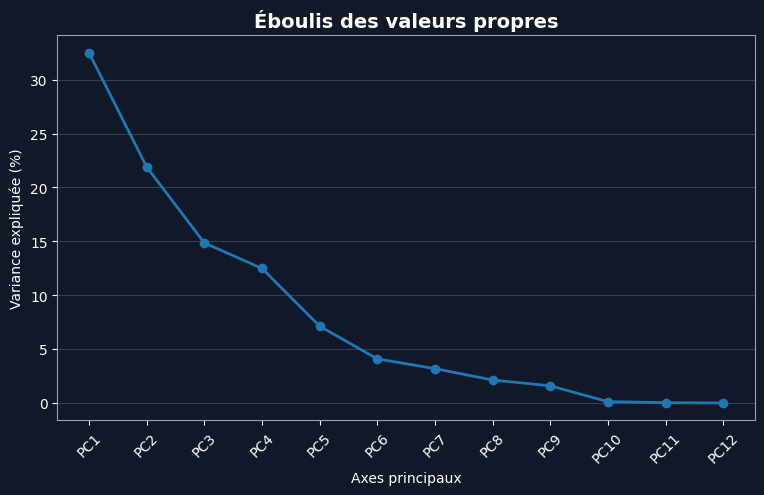

In [58]:
# Visualisation de l'éboulis des valeurs propres
# Ce graphique permet d'observer la part d'information portée par chaque axe de l'ACP
fig, ax = plt.subplots(figsize=(9, 5))

fig.patch.set_facecolor("#111827")
ax.set_facecolor("#111827")

ax.plot(
    df_valeurs_propres["axe"],
    df_valeurs_propres["variance_expliquee_%"],
    marker="o",
    linewidth=2
)

ax.set_title("Éboulis des valeurs propres", color="white", fontsize=14, fontweight="bold")
ax.set_xlabel("Axes principaux", color="white")
ax.set_ylabel("Variance expliquée (%)", color="white")

ax.tick_params(axis="x", colors="white", rotation=45)
ax.tick_params(axis="y", colors="white")

ax.grid(axis="y", alpha=0.25)

for spine in ax.spines.values():
    spine.set_color("#9CA3AF")

plt.show()

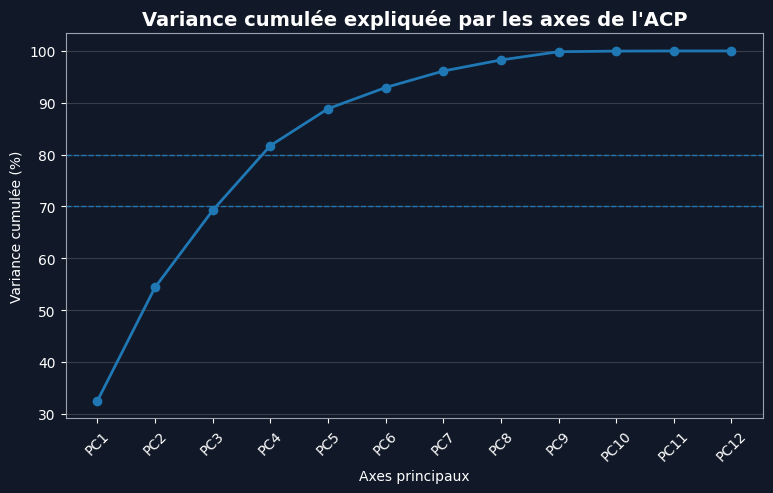

In [59]:
# Visualisation de la variance cumulée
# Cette courbe aide à choisir le nombre d'axes à retenir pour conserver suffisamment d'information
fig, ax = plt.subplots(figsize=(9, 5))

fig.patch.set_facecolor("#111827")
ax.set_facecolor("#111827")

ax.plot(
    df_valeurs_propres["axe"],
    df_valeurs_propres["variance_cumulee_%"],
    marker="o",
    linewidth=2
)

ax.axhline(70, linestyle="--", linewidth=1)
ax.axhline(80, linestyle="--", linewidth=1)

ax.set_title("Variance cumulée expliquée par les axes de l'ACP", color="white", fontsize=14, fontweight="bold")
ax.set_xlabel("Axes principaux", color="white")
ax.set_ylabel("Variance cumulée (%)", color="white")

ax.tick_params(axis="x", colors="white", rotation=45)
ax.tick_params(axis="y", colors="white")

ax.grid(axis="y", alpha=0.25)

for spine in ax.spines.values():
    spine.set_color("#9CA3AF")

plt.show()

<div style="max-width: 980px; margin: 35px auto; padding: 24px; border: 1px solid #F97316; border-radius: 14px; background: linear-gradient(135deg, rgba(88, 34, 7, 0.92), rgba(30, 20, 15, 0.96)); color: #fff; box-shadow: 0 0 25px rgba(249, 115, 22, 0.22);">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:14px;">
    <b style="font-size:19px; color:#FDBA74;">📉 Étape 3.2 • Éboulis des valeurs propres</b>
  </div>
  <p style="line-height:1.6;">
    L’éboulis des valeurs propres permet d’observer la part d’information expliquée par chaque axe principal de l’ACP.
    Plus la variance expliquée par un axe est élevée, plus cet axe résume une partie importante des différences entre les pays.
  </p>
  <div style="display:grid; grid-template-columns: 1fr 1fr; gap:12px; margin-top:18px;">
    <div style="padding:3px; border:1px solid #22C55E; border-radius:10px; background:rgba(20, 83, 45, 0.35);">
      <strong style="color:#86EFAC;">✅ Premiers axes principaux</strong>
      <ul style="margin-bottom:0; line-height:1.6;">
        <li><strong>PC1</strong> explique 32,49 % de la variance</li>
        <li><strong>PC2</strong> explique 21,90 % de la variance</li>
        <li><strong>PC3</strong> explique 14,85 % de la variance</li>
        <li><strong>PC4</strong> explique 12,49 % de la variance</li>
      </ul>
    </div>
    <div style="padding:3px; border:1px solid #38BDF8; border-radius:10px; background:rgba(8, 47, 73, 0.35);">
      <strong style="color:#BAE6FD;">📊 Variance cumulée</strong>
      <ul style="margin-bottom:0; line-height:1.6;">
        <li>PC1 + PC2 : <strong>54,39 %</strong></li>
        <li>PC1 à PC3 : <strong>69,24 %</strong></li>
        <li>PC1 à PC4 : <strong>81,73 %</strong></li>
        <li>PC1 à PC6 : <strong>92,94 %</strong></li>
      </ul>
    </div>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #F59E0B; border-radius:10px; background:rgba(120, 53, 15, 0.35);">
    <strong style="color:#FDE68A;">📌 Lecture du graphique :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      La courbe montre une forte baisse après les premiers axes. Les quatre premières composantes concentrent déjà plus de 80 %
      de l’information totale, tandis que les axes suivants apportent une information de plus en plus marginale.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #A855F7; border-radius:10px; background:rgba(88, 28, 135, 0.28);">
    <strong style="color:#E9D5FF;">🔎 Interprétation :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      L’ACP résume efficacement les données : une partie importante de la variance est portée par un nombre réduit d’axes.
      Cela permet de simplifier l’analyse tout en conservant l’essentiel de l’information utile.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #22C55E; border-radius:10px; background:rgba(6, 78, 59, 0.35);">
    <strong style="color:#86EFAC;">👉 En clair :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Les graphiques confirment qu’il est pertinent de réduire le dataset à quelques axes principaux.
      Les 4 premiers axes suffisent à conserver une base d’analyse solide.
    </p>
  </div>
</div>

<a id="etape3_3"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(253,186,116,0.28);
  border-radius:12px;
  background:rgba(253,186,116,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(85%) sepia(17%) saturate(1388%) hue-rotate(334deg) brightness(103%) contrast(102%);
      ">
    </a>
    <span>3.3 • Choix du nombre d’axes retenus</span>
  </h3>
</div>

In [60]:
# Choix du nombre d'axes retenus pour la suite
# Le seuil de 80 % est retenu afin de conserver une part importante de l'information
# tout en gardant un nombre d'axes interprétable
nb_axes_retenus = np.argmax(variance_cumulee >= 0.80) + 1

axes_retenus = [f"PC{i+1}" for i in range(nb_axes_retenus)]

print("Nombre d'axes retenus :", nb_axes_retenus)
print("Variance cumulée conservée :", round(variance_cumulee[nb_axes_retenus - 1] * 100, 2), "%")
print("Axes retenus :", axes_retenus)

Nombre d'axes retenus : 4
Variance cumulée conservée : 81.73 %
Axes retenus : ['PC1', 'PC2', 'PC3', 'PC4']


In [61]:
# Création du dataset ACP limité aux axes retenus
# Ce dataset servira pour la projection des individus et pourra aussi être utilisé pour le clustering
df_pca_retenu = df_pca[["Zone"] + axes_retenus].copy()

print("✅ Dataset ACP retenu créé.")
print("Dimensions :", df_pca_retenu.shape)

display(df_pca_retenu.head())

✅ Dataset ACP retenu créé.
Dimensions : (125, 5)


,Zone,PC1,PC2,PC3,PC4
0,Afrique du Sud,3.28,0.37,-1.57,1.37
1,Albanie,-1.45,0.35,-0.71,-0.29
2,Algérie,-0.69,-2.09,0.21,-0.01
3,Allemagne,6.00,0.98,-0.04,-3.79
4,Angola,-0.59,-0.79,-2.02,-1.00


<div style="max-width: 980px; margin: 35px auto; padding: 24px; border: 1px solid #F97316; border-radius: 14px; background: linear-gradient(135deg, rgba(88, 34, 7, 0.92), rgba(30, 20, 15, 0.96)); color: #fff; box-shadow: 0 0 25px rgba(249, 115, 22, 0.22);">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:14px;">
    <b style="font-size:19px; color:#FDBA74;">🧭 Étape 3.3 • Choix du nombre d’axes retenus</b>
  </div>
  <p style="line-height:1.6;">
    Le nombre d’axes retenus a été déterminé à partir de la variance cumulée expliquée.
    L’objectif est de conserver une part suffisante de l’information initiale tout en gardant un nombre d’axes lisible et exploitable pour la suite.
  </p>
  <div style="display:grid; grid-template-columns: 1fr 1fr; gap:12px; margin-top:18px;">
    <div style="padding:3px; border:1px solid #22C55E; border-radius:10px; background:rgba(20, 83, 45, 0.35);">
      <strong style="color:#86EFAC;">✅ Choix retenu</strong>
      <ul style="margin-bottom:0; line-height:1.6;">
        <li><strong>4 axes principaux</strong> retenus</li>
        <li>Axes conservés : <strong>PC1, PC2, PC3 et PC4</strong></li>
        <li>Variance cumulée conservée : <strong>81,73 %</strong></li>
        <li>Seuil de 80 % atteint</li>
      </ul>
    </div>
    <div style="padding:3px; border:1px solid #38BDF8; border-radius:10px; background:rgba(8, 47, 73, 0.35);">
      <strong style="color:#BAE6FD;">📦 Dataset ACP retenu</strong>
      <ul style="margin-bottom:0; line-height:1.6;">
        <li><strong>125 pays</strong> conservés</li>
        <li><strong>5 colonnes</strong> au total</li>
        <li>1 identifiant pays : <strong>Zone</strong></li>
        <li>4 composantes principales exploitables</li>
      </ul>
    </div>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #F59E0B; border-radius:10px; background:rgba(120, 53, 15, 0.35);">
    <strong style="color:#FDE68A;">📌 Justification du choix :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Trois axes expliquent 69,24 % de la variance, ce qui est proche du seuil de 70 %.
      En retenant quatre axes, la variance cumulée atteint 81,73 %, ce qui offre un meilleur compromis entre conservation de l’information
      et lisibilité de l’analyse.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #A855F7; border-radius:10px; background:rgba(88, 28, 135, 0.28);">
    <strong style="color:#E9D5FF;">🔎 Utilisation pour la suite :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Les axes retenus serviront à interpréter les grandes dimensions qui structurent les pays, à visualiser leur projection,
      puis à alimenter les méthodes de classification comme la CAH et le K-means.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #22C55E; border-radius:10px; background:rgba(6, 78, 59, 0.35);">
    <strong style="color:#86EFAC;">👉 En clair :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Le choix de 4 axes est validé : il permet de résumer plus de 80 % de l’information initiale tout en gardant une base claire
      pour l’interprétation et le clustering.
    </p>
  </div>
</div>

<a id="etape3_4"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(253,186,116,0.28);
  border-radius:12px;
  background:rgba(253,186,116,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(85%) sepia(17%) saturate(1388%) hue-rotate(334deg) brightness(103%) contrast(102%);
      ">
    </a>
    <span>3.4 • Cercle des corrélations</span>
  </h3>
</div>

In [62]:
# Calcul des coordonnées des variables sur les axes principaux
# Ces coordonnées permettent de visualiser quelles variables contribuent le plus aux axes de l'ACP
# On utilise les composantes de l'ACP pondérées par la racine carrée des valeurs propres
coordonnees_variables = pca.components_.T * np.sqrt(pca.explained_variance_)

df_coordonnees_variables = pd.DataFrame(
    coordonnees_variables,
    columns=colonnes_pca,
    index=variables_numeriques
)

print("✅ Coordonnées des variables calculées.")
print("Dimensions du tableau des coordonnées :", df_coordonnees_variables.shape)

display(df_coordonnees_variables)

✅ Coordonnées des variables calculées.
Dimensions du tableau des coordonnées : (12, 12)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12
Disponibilité alimentaire (Kcal/personne/jour),0.26,0.78,0.05,0.56,0.11,-0.03,-0.05,0.08,-0.01,0.09,0.00,0.00
Disponibilité alimentaire en quantité (kg/personne/an),0.26,0.78,0.04,0.55,0.13,-0.03,-0.08,0.07,-0.01,-0.09,-0.00,-0.00
Disponibilité intérieure,0.93,-0.15,-0.03,0.20,0.01,0.14,0.10,-0.22,0.02,-0.00,0.04,0.00
Exportations - Quantité,0.39,0.12,0.70,-0.41,0.39,-0.14,-0.03,0.01,-0.09,0.00,0.00,-0.00
Importations - Quantité,0.75,0.14,-0.36,-0.36,0.25,-0.29,-0.04,-0.05,-0.16,0.00,-0.00,0.00
Production,0.91,-0.15,0.23,0.17,0.03,0.16,0.13,-0.18,0.07,-0.00,-0.04,-0.00
population_2017,0.71,-0.51,-0.00,0.07,-0.10,0.32,-0.08,0.29,-0.20,-0.00,-0.00,0.00
PIB_2017,0.83,0.11,-0.08,-0.35,-0.13,-0.12,0.05,0.24,0.29,-0.00,0.00,0.00
stabilite_politique_2017,-0.08,0.77,0.05,-0.32,-0.28,0.10,0.44,0.04,-0.13,-0.00,0.00,0.00
taux_dependance_importations,-0.27,0.32,-0.47,-0.33,0.58,0.40,0.00,0.01,0.08,0.00,-0.00,-0.00


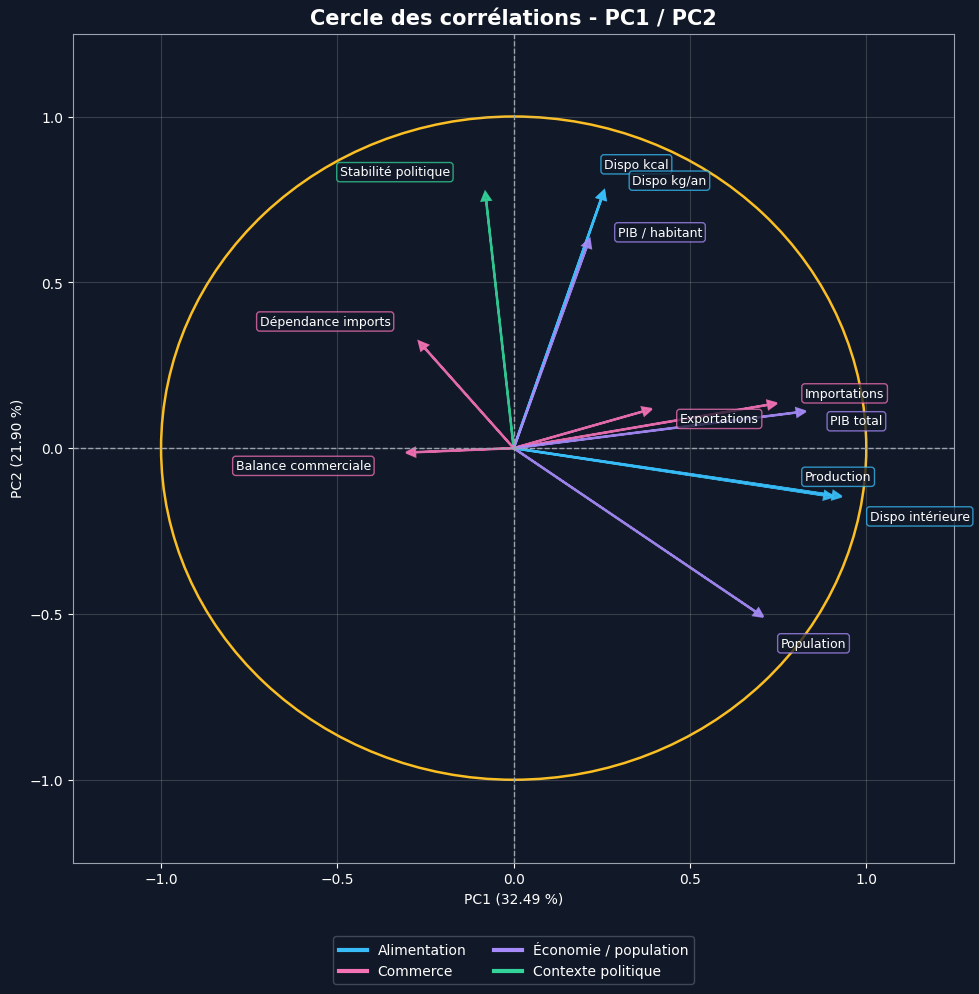

In [63]:
# Graphique cercle des corrélations sur le plan PC1 / PC2
fig, ax = plt.subplots(figsize=(10, 10))

fig.patch.set_facecolor("#111827")
ax.set_facecolor("#111827")

# Cercle unité
cercle = plt.Circle((0, 0), 1, fill=False, color="#FBBF24", linewidth=1.8)
ax.add_artist(cercle)

# Axes horizontaux et verticaux
ax.axhline(0, color="#9CA3AF", linewidth=1, linestyle="--")
ax.axvline(0, color="#9CA3AF", linewidth=1, linestyle="--")

# Noms raccourcis pour éviter les chevauchements
labels_courts = {
    "Disponibilité alimentaire (Kcal/personne/jour)": "Dispo kcal",
    "Disponibilité alimentaire en quantité (kg/personne/an)": "Dispo kg/an",
    "Disponibilité intérieure": "Dispo intérieure",
    "Exportations - Quantité": "Exportations",
    "Importations - Quantité": "Importations",
    "Production": "Production",
    "population_2017": "Population",
    "PIB_2017": "PIB total",
    "stabilite_politique_2017": "Stabilité politique",
    "taux_dependance_importations": "Dépendance imports",
    "balance_commerciale_quantite": "Balance commerciale",
    "PIB_par_habitant": "PIB / habitant"
}

# Couleurs par famille de variables
groupes_variables = {
    "Alimentation": {
        "variables": [
            "Disponibilité alimentaire (Kcal/personne/jour)",
            "Disponibilité alimentaire en quantité (kg/personne/an)",
            "Disponibilité intérieure",
            "Production"
        ],
        "couleur": "#38BDF8"
    },
    "Commerce": {
        "variables": [
            "Exportations - Quantité",
            "Importations - Quantité",
            "taux_dependance_importations",
            "balance_commerciale_quantite"
        ],
        "couleur": "#F472B6"
    },
    "Économie / population": {
        "variables": [
            "population_2017",
            "PIB_2017",
            "PIB_par_habitant"
        ],
        "couleur": "#A78BFA"
    },
    "Contexte politique": {
        "variables": [
            "stabilite_politique_2017"
        ],
        "couleur": "#34D399"
    }
}

def couleur_variable(variable):
    for groupe, infos in groupes_variables.items():
        if variable in infos["variables"]:
            return infos["couleur"]
    return "#FFFFFF"

# Petits décalages manuels pour les variables qui se superposent le plus
offsets_labels = {
    "Disponibilité alimentaire (Kcal/personne/jour)": (0.00, 0.08),
    "Disponibilité alimentaire en quantité (kg/personne/an)": (0.08, 0.03),
    "Production": (-0.08, 0.06),
    "PIB_par_habitant": (0.08, 0.02),
    "PIB_2017": (0.07, -0.03),
    "Importations - Quantité": (0.08, 0.03),
    "Exportations - Quantité": (0.08, -0.03),
    "Disponibilité intérieure": (0.08, -0.06),
    "population_2017": (0.05, -0.08),
    "balance_commerciale_quantite": (-0.10, -0.04),
    "taux_dependance_importations": (-0.08, 0.06),
    "stabilite_politique_2017": (-0.10, 0.06)
}

# Flèches et labels
for variable in df_coordonnees_variables.index:
    x = df_coordonnees_variables.loc[variable, "PC1"]
    y = df_coordonnees_variables.loc[variable, "PC2"]

    couleur = couleur_variable(variable)
    label = labels_courts.get(variable, variable)

    ax.arrow(
        0, 0, x, y,
        head_width=0.025,
        head_length=0.025,
        length_includes_head=True,
        color=couleur,
        alpha=0.9,
        linewidth=1.6
    )

    dx, dy = offsets_labels.get(variable, (0.03 if x >= 0 else -0.03, 0.03 if y >= 0 else -0.03))

    ax.text(
        x + dx,
        y + dy,
        label,
        color="white",
        fontsize=9,
        ha="left" if x >= 0 else "right",
        va="center",
        bbox=dict(
            facecolor="#111827",
            edgecolor=couleur,
            boxstyle="round,pad=0.25",
            alpha=0.75
        )
    )

# Limites et titres
ax.set_xlim(-1.25, 1.25)
ax.set_ylim(-1.25, 1.25)

ax.set_xlabel(f"PC1 ({variance_expliquee[0] * 100:.2f} %)", color="white")
ax.set_ylabel(f"PC2 ({variance_expliquee[1] * 100:.2f} %)", color="white")
ax.set_title("Cercle des corrélations - PC1 / PC2", color="white", fontsize=15, fontweight="bold")

ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")
ax.grid(alpha=0.25)

for spine in ax.spines.values():
    spine.set_color("#9CA3AF")

# Légende des familles de variables
handles = [
    plt.Line2D([0], [0], color=infos["couleur"], lw=3, label=groupe)
    for groupe, infos in groupes_variables.items()
]

legend = ax.legend(
    handles=handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=2,
    frameon=True,
    facecolor="#111827",
    edgecolor="#4B5563",
    labelcolor="white"
)

plt.tight_layout()
plt.show()

In [64]:
# Identification des variables les mieux représentées sur le plan PC1 / PC2
# Cela permet d'interpréter plus facilement le sens des axes principaux
correlations_pc1_pc2 = df_coordonnees_variables[["PC1", "PC2"]].copy()

correlations_pc1_pc2["contribution_visuelle"] = (
    correlations_pc1_pc2["PC1"].abs() + correlations_pc1_pc2["PC2"].abs()
)

display(
    correlations_pc1_pc2
    .sort_values("contribution_visuelle", ascending=False)
)

,PC1,PC2,contribution_visuelle
population_2017,0.71,-0.51,1.22
Disponibilité intérieure,0.93,-0.15,1.08
Production,0.91,-0.15,1.05
Disponibilité alimentaire en quantité (kg/personne/an),0.26,0.78,1.03
Disponibilité alimentaire (Kcal/personne/jour),0.26,0.78,1.03
PIB_2017,0.83,0.11,0.94
Importations - Quantité,0.75,0.14,0.88
stabilite_politique_2017,-0.08,0.77,0.85
PIB_par_habitant,0.22,0.63,0.85
taux_dependance_importations,-0.27,0.32,0.59


<div style="max-width: 980px; margin: 35px auto; padding: 24px; border: 1px solid #F59E0B; border-radius: 14px; background: linear-gradient(135deg, rgba(92, 38, 9, 0.92), rgba(30, 20, 16, 0.96)); color: #fff; box-shadow: 0 0 25px rgba(245, 158, 11, 0.25);">

  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <b style="font-size:19px; color:#FDBA74;">📉 Étape 3.4 • Cercle des corrélations</b>
  </div>
  <p>
    Le cercle des corrélations permet d'observer le lien entre les variables initiales et les deux premiers axes de l'ACP.
    Les flèches les plus longues et les plus proches du cercle sont les variables les mieux représentées sur le plan
    <strong>PC1 / PC2</strong>.
  </p>
  <div style="display:grid; grid-template-columns: 1fr 1fr; gap:12px; margin-top:18px;">
    <div style="padding:3px; border:1px solid #38BDF8; border-radius:10px; background:rgba(8,47,73,0.35);">
      <strong style="color:#BAE6FD;">📊 Lecture de PC1</strong>
      <ul style="margin-bottom:0;">
        <li><strong>PC1 explique 32,49 %</strong> de la variance.</li>
        <li>Il est fortement lié aux variables de taille et de volume.</li>
        <li>Population, PIB, disponibilité intérieure et production sont orientés positivement.</li>
        <li>Cet axe oppose donc les grands marchés aux pays de taille plus limitée.</li>
      </ul>
    </div>
    <div style="padding:3px; border:1px solid #A78BFA; border-radius:10px; background:rgba(88,28,135,0.28);">
      <strong style="color:#E9D5FF;">📈 Lecture de PC2</strong>
      <ul style="margin-bottom:0;">
        <li><strong>PC2 explique 21,90 %</strong> de la variance.</li>
        <li>Il est davantage lié au niveau de disponibilité alimentaire, au PIB par habitant et à la stabilité politique.</li>
        <li>Il distingue les pays plus favorables économiquement ou politiquement.</li>
        <li>La population est plutôt positionnée dans le sens opposé sur cet axe.</li>
      </ul>
    </div>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #F472B6; border-radius:10px; background:rgba(131,24,67,0.30);">
    <strong style="color:#FBCFE8;">🔎 Variables les plus structurantes :</strong>
    <p style="margin-bottom:0;">
      Les variables les plus contributives visuellement sur le plan PC1 / PC2 sont notamment
      <strong>population_2017</strong>, <strong>Disponibilité intérieure</strong>, <strong>Production</strong>,
      les deux variables de <strong>disponibilité alimentaire</strong>, le <strong>PIB total</strong>,
      les <strong>importations</strong>, la <strong>stabilité politique</strong> et le <strong>PIB par habitant</strong>.
      Elles participent donc fortement à la construction des deux premiers axes.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #22C55E; border-radius:10px; background:rgba(20,83,45,0.35);">
    <strong style="color:#86EFAC;">✅ Interprétation métier :</strong>
    <p style="margin-bottom:0;">
      Le premier axe semble représenter un effet de <strong>taille de marché</strong> : grands pays, fortes productions,
      fortes disponibilités intérieures et PIB élevé. Le deuxième axe apporte une lecture plus qualitative,
      liée au <strong>niveau de richesse par habitant</strong>, à la <strong>stabilité politique</strong>
      et à la disponibilité alimentaire.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #F59E0B; border-radius:10px; background:rgba(120,53,15,0.35);">
    <strong style="color:#FDE68A;">👉 En clair :</strong>
    <p style="margin-bottom:0;">
      Le plan PC1 / PC2 résume une part importante de l'information. Il permet déjà de distinguer les grands marchés volumineux
      des pays plus petits, tout en intégrant des critères économiques et politiques utiles pour l'analyse commerciale.
    </p>
  </div>

</div>

<a id="etape3_5"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(253,186,116,0.28);
  border-radius:12px;
  background:rgba(253,186,116,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(85%) sepia(17%) saturate(1388%) hue-rotate(334deg) brightness(103%) contrast(102%);
      ">
    </a>
    <span>3.5 • Projection des individus</span>
  </h3>
</div>

In [65]:
# Préparation de la projection des individus
# Les individus correspondent ici aux pays
# On utilise les coordonnées ACP déjà calculées dans df_pca
projection_individus = df_pca[["Zone", "PC1", "PC2", "PC3", "PC4"]].copy()

print("✅ Projection des individus préparée.")
print("Dimensions :", projection_individus.shape)

display(projection_individus.head())

✅ Projection des individus préparée.
Dimensions : (125, 5)


,Zone,PC1,PC2,PC3,PC4
0,Afrique du Sud,3.28,0.37,-1.57,1.37
1,Albanie,-1.45,0.35,-0.71,-0.29
2,Algérie,-0.69,-2.09,0.21,-0.01
3,Allemagne,6.00,0.98,-0.04,-3.79
4,Angola,-0.59,-0.79,-2.02,-1.00


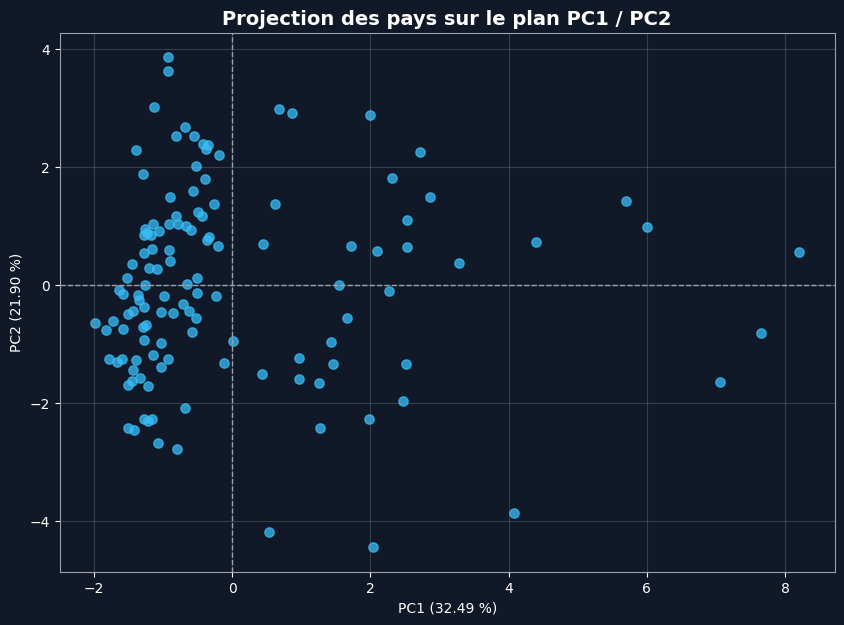

In [66]:
# Graphique Projection des pays sur le premier plan factoriel PC1 / PC2
# Ce graphique permet d'observer les pays proches ou éloignés selon leurs profils multivariés
fig, ax = plt.subplots(figsize=(10, 7))

fig.patch.set_facecolor("#111827")
ax.set_facecolor("#111827")

ax.scatter(
    projection_individus["PC1"],
    projection_individus["PC2"],
    alpha=0.75,
    s=45,
    color="#38BDF8"
)

ax.axhline(0, color="#9CA3AF", linewidth=1, linestyle="--")
ax.axvline(0, color="#9CA3AF", linewidth=1, linestyle="--")

ax.set_title("Projection des pays sur le plan PC1 / PC2", color="white", fontsize=14, fontweight="bold")
ax.set_xlabel(f"PC1 ({variance_expliquee[0] * 100:.2f} %)", color="white")
ax.set_ylabel(f"PC2 ({variance_expliquee[1] * 100:.2f} %)", color="white")

ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")

ax.grid(alpha=0.25)

for spine in ax.spines.values():
    spine.set_color("#9CA3AF")

plt.show()

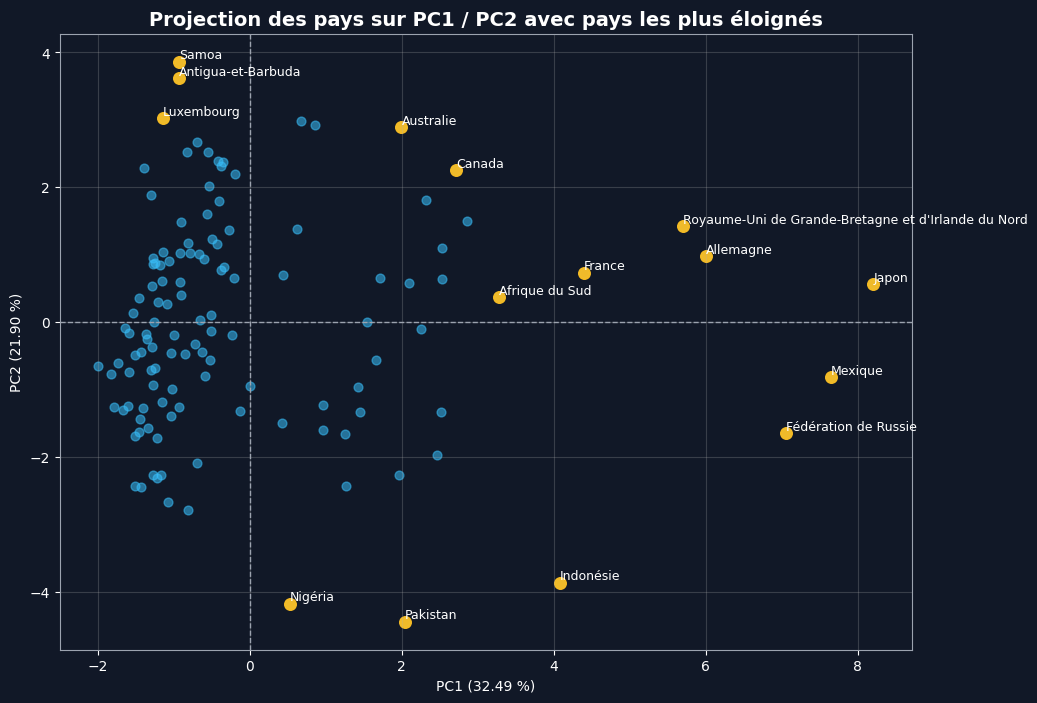

In [67]:
# Graphique projection annotée des pays les plus éloignés du centre
# On annote uniquement les pays les plus atypiques sur le plan PC1 / PC2 afin de garder un graphique lisible
projection_individus["distance_centre_PC1_PC2"] = np.sqrt(
    projection_individus["PC1"]**2 + projection_individus["PC2"]**2
)

pays_a_annoter = (
    projection_individus
    .sort_values("distance_centre_PC1_PC2", ascending=False)
    .head(15)
)

fig, ax = plt.subplots(figsize=(11, 8))

fig.patch.set_facecolor("#111827")
ax.set_facecolor("#111827")

ax.scatter(
    projection_individus["PC1"],
    projection_individus["PC2"],
    alpha=0.55,
    s=40,
    color="#38BDF8"
)

ax.scatter(
    pays_a_annoter["PC1"],
    pays_a_annoter["PC2"],
    alpha=0.95,
    s=70,
    color="#FBBF24"
)

for _, row in pays_a_annoter.iterrows():
    ax.text(
        row["PC1"],
        row["PC2"],
        row["Zone"],
        color="white",
        fontsize=9,
        ha="left",
        va="bottom"
    )

ax.axhline(0, color="#9CA3AF", linewidth=1, linestyle="--")
ax.axvline(0, color="#9CA3AF", linewidth=1, linestyle="--")

ax.set_title("Projection des pays sur PC1 / PC2 avec pays les plus éloignés", color="white", fontsize=14, fontweight="bold")
ax.set_xlabel(f"PC1 ({variance_expliquee[0] * 100:.2f} %)", color="white")
ax.set_ylabel(f"PC2 ({variance_expliquee[1] * 100:.2f} %)", color="white")

ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")

ax.grid(alpha=0.25)

for spine in ax.spines.values():
    spine.set_color("#9CA3AF")

plt.show()

In [68]:
# Liste des pays les plus éloignés du centre sur le plan PC1 / PC2
# Ces pays sont ceux qui présentent les profils les plus marqués dans la projection ACP
display(
    projection_individus[
        ["Zone", "PC1", "PC2", "PC3", "PC4", "distance_centre_PC1_PC2"]
    ]
    .sort_values("distance_centre_PC1_PC2", ascending=False)
    .head(20)
)

,Zone,PC1,PC2,PC3,PC4,distance_centre_PC1_PC2
56,Japon,8.21,0.56,-4.67,-3.11,8.23
73,Mexique,7.65,-0.81,-3.74,1.21,7.69
39,Fédération de Russie,7.06,-1.65,0.64,2.01,7.25
3,Allemagne,6.00,0.98,-0.04,-3.79,6.08
93,Royaume-Uni de Grande-Bretagne et d'Irlande du...,5.70,1.42,-1.17,-1.57,5.87
48,Indonésie,4.08,-3.87,0.55,0.72,5.62
84,Pakistan,2.04,-4.45,0.34,1.02,4.89
38,France,4.40,0.73,0.93,-2.02,4.46
79,Nigéria,0.53,-4.18,0.11,0.13,4.21
98,Samoa,-0.92,3.86,-0.69,2.00,3.97


<div style="max-width: 980px; margin: 35px auto; padding: 24px; border: 1px solid #F59E0B; border-radius: 14px; background: linear-gradient(135deg, rgba(92, 38, 9, 0.92), rgba(30, 20, 16, 0.96)); color: #fff; box-shadow: 0 0 25px rgba(245, 158, 11, 0.25);">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <b style="font-size:19px; color:#FDBA74;">🌍 Étape 3.5 • Projection des individus</b>
  </div>
  <p>
    La projection des individus permet de positionner chaque pays dans le plan factoriel <strong>PC1 / PC2</strong>.
    Les pays proches les uns des autres présentent des profils similaires selon les variables utilisées dans l'ACP,
    tandis que les pays éloignés du centre ont des profils plus marqués.
  </p>
  <div style="display:grid; grid-template-columns: 1fr 1fr; gap:12px; margin-top:18px;">
    <div style="padding:3px; border:1px solid #38BDF8; border-radius:10px; background:rgba(8,47,73,0.35);">
      <strong style="color:#BAE6FD;">📌 Lecture générale</strong>
      <ul style="margin-bottom:0;">
        <li>La majorité des pays est regroupée près du centre ou du côté gauche du graphique.</li>
        <li>Ces pays présentent des profils plus proches de la moyenne du dataset.</li>
        <li>Les pays très éloignés du centre ont des caractéristiques plus spécifiques.</li>
        <li>Cette projection prépare la lecture des futurs groupes de pays.</li>
      </ul>
    </div>
    <div style="padding:3px; border:1px solid #F472B6; border-radius:10px; background:rgba(131,24,67,0.30);">
      <strong style="color:#FBCFE8;">🎯 Pays les plus éloignés</strong>
      <ul style="margin-bottom:0;">
        <li><strong>Japon</strong> : pays le plus éloigné sur le plan PC1 / PC2.</li>
        <li><strong>Mexique</strong>, <strong>Fédération de Russie</strong> et <strong>Allemagne</strong> ressortent aussi fortement.</li>
        <li><strong>Indonésie</strong>, <strong>Pakistan</strong>, <strong>France</strong> et <strong>Nigéria</strong> ont également des profils marqués.</li>
        <li>Ces pays seront importants à surveiller lors du clustering.</li>
      </ul>
    </div>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #A78BFA; border-radius:10px; background:rgba(88,28,135,0.28);">
    <strong style="color:#E9D5FF;">📊 Interprétation des positions :</strong>
    <p style="margin-bottom:0;">
      Les pays situés à droite du graphique sont plutôt associés aux variables positives de PC1,
      comme le volume de marché, le PIB total, la production ou la disponibilité intérieure.
      Les pays positionnés plus haut sont davantage associés aux variables positives de PC2,
      comme la disponibilité alimentaire, le PIB par habitant ou la stabilité politique.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #22C55E; border-radius:10px; background:rgba(20,83,45,0.35);">
    <strong style="color:#86EFAC;">✅ Lecture métier :</strong>
    <p style="margin-bottom:0;">
      Cette projection montre que certains pays ont des profils particulièrement différenciés.
      Les grandes économies ou les pays à forte production ne se comportent pas comme les petits marchés,
      ce qui justifie l'utilisation du clustering pour regrouper les pays selon des profils homogènes.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #F59E0B; border-radius:10px; background:rgba(120,53,15,0.35);">
    <strong style="color:#FDE68A;">👉 En clair :</strong>
    <p style="margin-bottom:0;">
      La projection des pays confirme que le dataset contient plusieurs profils distincts.
      Les pays les plus éloignés du centre devront être pris en compte avec attention,
      car ils peuvent fortement influencer la formation des groupes lors de la CAH et du K-means.
    </p>
  </div>
</div>

<a id="etape4"></a>
<div style="
  width:78%;
  margin:16px auto 10px auto;
  border:1px solid rgba(52,211,153,0.34);
  border-radius:14px;
  background:linear-gradient(135deg, rgba(6,74,53,0.96), rgba(5,37,27,0.98));
  box-sizing:border-box;
">
  <h2 style="
    margin:0;
    padding:15px 20px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:22px;
    font-weight:750;
    gap:12px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:24px; height:24px; display:block;
        filter: brightness(0) saturate(100%) invert(78%) sepia(32%) saturate(1109%) hue-rotate(113deg) brightness(102%) contrast(101%);
      ">
    </a>
    <span style="color:#86EFAC;">🌐 Étape 4</span>
    <span>• Lecture et interprétation de l’ACP</span>
  </h2>
</div>

<a id="etape4_1"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(134,239,172,0.28);
  border-radius:12px;
  background:rgba(134,239,172,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(89%) sepia(17%) saturate(874%) hue-rotate(88deg) brightness(101%) contrast(101%);
      ">
    </a>
    <span>4.1 • Lecture des axes principaux</span>
  </h3>
</div>

In [69]:
# Identification des variables les plus contributives aux axes principaux
# On utilise les coordonnées des variables calculées précédemment
# Plus la valeur absolue est élevée, plus la variable contribue à l'interprétation de l'axe
axes_a_interpreter = ["PC1", "PC2", "PC3", "PC4"]

contributions_axes = {}

for axe in axes_a_interpreter:
    contributions_axes[axe] = (
        df_coordonnees_variables[[axe]]
        .copy()
        .assign(contribution_absolue=lambda x: x[axe].abs())
        .sort_values("contribution_absolue", ascending=False)
    )

    print(f"\nVariables les plus contributives à {axe} :")
    display(contributions_axes[axe].head(8))


Variables les plus contributives à PC1 :


,PC1,contribution_absolue
Disponibilité intérieure,0.93,0.93
Production,0.91,0.91
PIB_2017,0.83,0.83
Importations - Quantité,0.75,0.75
population_2017,0.71,0.71
Exportations - Quantité,0.39,0.39
balance_commerciale_quantite,-0.30,0.30
taux_dependance_importations,-0.27,0.27



Variables les plus contributives à PC2 :


,PC2,contribution_absolue
Disponibilité alimentaire en quantité (kg/personne/an),0.78,0.78
Disponibilité alimentaire (Kcal/personne/jour),0.78,0.78
stabilite_politique_2017,0.77,0.77
PIB_par_habitant,0.63,0.63
population_2017,-0.51,0.51
taux_dependance_importations,0.32,0.32
Production,-0.15,0.15
Disponibilité intérieure,-0.15,0.15



Variables les plus contributives à PC3 :


,PC3,contribution_absolue
balance_commerciale_quantite,0.93,0.93
Exportations - Quantité,0.70,0.70
taux_dependance_importations,-0.47,0.47
Importations - Quantité,-0.36,0.36
Production,0.23,0.23
PIB_par_habitant,0.10,0.10
PIB_2017,-0.08,0.08
Disponibilité alimentaire (Kcal/personne/jour),0.05,0.05



Variables les plus contributives à PC4 :


,PC4,contribution_absolue
Disponibilité alimentaire (Kcal/personne/jour),0.56,0.56
Disponibilité alimentaire en quantité (kg/personne/an),0.55,0.55
PIB_par_habitant,-0.44,0.44
Exportations - Quantité,-0.41,0.41
Importations - Quantité,-0.36,0.36
PIB_2017,-0.35,0.35
taux_dependance_importations,-0.33,0.33
stabilite_politique_2017,-0.32,0.32


In [70]:
# Création d'un tableau synthétique pour faciliter l'interprétation des axes
# On retient les principales variables positives et négatives de chaque axe
resume_axes = []

for axe in axes_a_interpreter:
    variables_positives = (
        df_coordonnees_variables[[axe]]
        .sort_values(axe, ascending=False)
        .head(4)
        .index
        .tolist()
    )

    variables_negatives = (
        df_coordonnees_variables[[axe]]
        .sort_values(axe, ascending=True)
        .head(4)
        .index
        .tolist()
    )

    resume_axes.append({
        "axe": axe,
        "variance_expliquee_%": round(variance_expliquee[int(axe.replace("PC", "")) - 1] * 100, 2),
        "variables_positives": ", ".join(variables_positives),
        "variables_negatives": ", ".join(variables_negatives)
    })

df_resume_axes = pd.DataFrame(resume_axes)

display(df_resume_axes)

,axe,variance_expliquee_%,variables_positives,variables_negatives
0,PC1,32.49,"Disponibilité intérieure, Production, PIB_2017...","balance_commerciale_quantite, taux_dependance_..."
1,PC2,21.90,Disponibilité alimentaire en quantité (kg/pers...,"population_2017, Production, Disponibilité int..."
2,PC3,14.85,"balance_commerciale_quantite, Exportations - Q...","taux_dependance_importations, Importations - Q..."
3,PC4,12.49,Disponibilité alimentaire (Kcal/personne/jour)...,"PIB_par_habitant, Exportations - Quantité, Imp..."


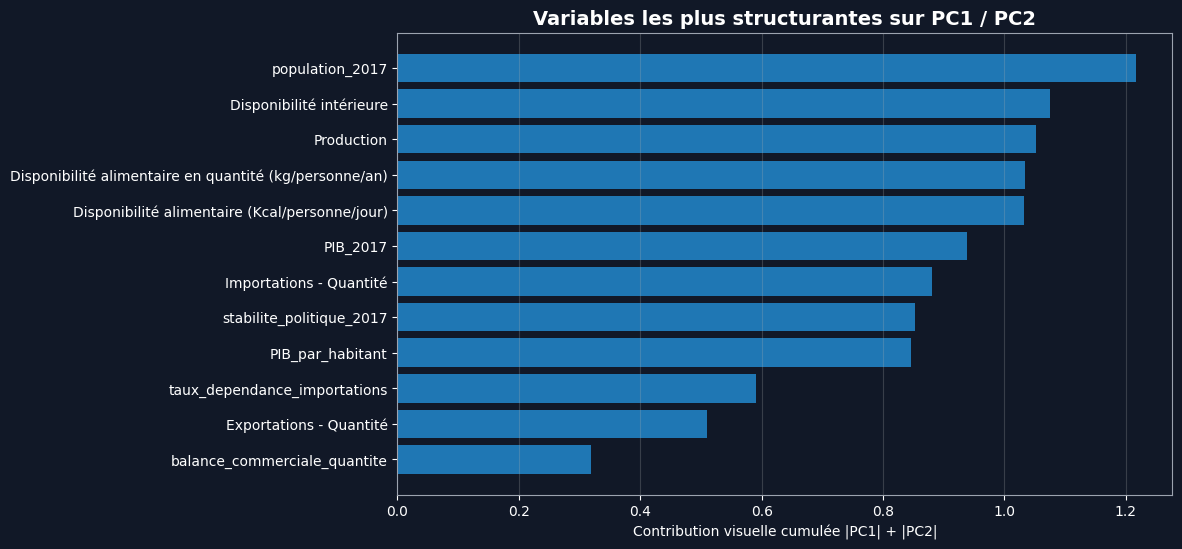

In [71]:
# Visualisation des contributions des variables aux deux premiers axes
# Ce graphique aide à repérer les variables qui structurent le plus le plan PC1 / PC2
contrib_pc1_pc2 = df_coordonnees_variables[["PC1", "PC2"]].copy()
contrib_pc1_pc2["contribution_PC1_PC2"] = contrib_pc1_pc2["PC1"].abs() + contrib_pc1_pc2["PC2"].abs()
contrib_pc1_pc2 = contrib_pc1_pc2.sort_values("contribution_PC1_PC2", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))

fig.patch.set_facecolor("#111827")
ax.set_facecolor("#111827")

ax.barh(
    contrib_pc1_pc2.index,
    contrib_pc1_pc2["contribution_PC1_PC2"]
)

ax.set_title("Variables les plus structurantes sur PC1 / PC2", color="white", fontsize=14, fontweight="bold")
ax.set_xlabel("Contribution visuelle cumulée |PC1| + |PC2|", color="white")
ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")

ax.grid(axis="x", alpha=0.25)

for spine in ax.spines.values():
    spine.set_color("#9CA3AF")

plt.show()

<div style="max-width: 980px; margin: 28px auto; padding: 22px; border: 1px solid #14B8A6; border-radius: 14px; background: linear-gradient(135deg, rgba(19, 78, 74, 0.88), rgba(17, 24, 39, 0.96)); color: #fff; box-shadow: 0 0 22px rgba(20, 184, 166, 0.22);">
  <b style="font-size:18px; color:#99F6E4;">📊 Lecture du graphique • Variables structurantes sur PC1 / PC2</b>
  <p style="margin-top:12px; line-height:1.6;">
    Ce graphique classe les variables selon leur contribution visuelle cumulée sur les deux premiers axes de l’ACP.
    Il permet de repérer rapidement les variables qui expliquent le mieux le plan factoriel PC1 / PC2.
  </p>
  <div style="margin-top:14px; padding:7px; border:1px solid #38BDF8; border-radius:10px; background:rgba(8, 47, 73, 0.35);">
    <strong style="color:#BAE6FD;">🔍 Ce qu’on observe :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Les variables les plus structurantes sont notamment <strong>population_2017</strong>, <strong>Disponibilité intérieure</strong>,
      <strong>Production</strong>, les deux variables de disponibilité alimentaire, puis le <strong>PIB 2017</strong>.
      Cela confirme que les deux premiers axes opposent fortement les pays selon leur taille, leur niveau de production et leur profil alimentaire.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #F59E0B; border-radius:10px; background:rgba(120, 53, 15, 0.35);">
    <strong style="color:#FDE68A;">📌 Utilité du graphique :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Il aide à justifier l’interprétation des axes : au lieu de commenter toutes les variables, on se concentre sur celles qui pèsent réellement
      dans la construction du plan PC1 / PC2.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #22C55E; border-radius:10px; background:rgba(6, 78, 59, 0.35);">
    <strong style="color:#86EFAC;">👉 En clair :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Ce graphique confirme que le plan principal de l’ACP est surtout porté par les volumes de marché, la disponibilité alimentaire,
      la production et le poids économique des pays.
    </p>
  </div>
</div>

<div style="max-width: 980px; margin: 35px auto; padding: 24px; border: 1px solid #10B981; border-radius: 14px; background: linear-gradient(135deg, rgba(6, 78, 59, 0.92), rgba(17, 24, 39, 0.96)); color: #fff; box-shadow: 0 0 25px rgba(16, 185, 129, 0.22);">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <b style="font-size:19px; color:#86EFAC;">🌍 Étape 4.1 • Lecture des axes principaux</b>
  </div>
  <p style="line-height:1.6;">
    Cette étape consiste à interpréter les axes principaux produits par l’ACP. Chaque axe résume une partie de l’information du dataset.
    Les variables les plus contributives permettent de comprendre ce que représente chaque axe et quels profils de pays il oppose.
  </p>
  <div style="display:grid; grid-template-columns:1fr 1fr; gap:12px; margin-top:18px;">
    <div style="padding:4px; border:1px solid #22C55E; border-radius:10px; background:rgba(20, 83, 45, 0.35);">
      <strong style="color:#86EFAC;">✅ Axes retenus pour l’interprétation</strong>
      <ul style="margin-bottom:0; line-height:1.7;">
        <li><strong>PC1</strong> : 32,49 % de variance expliquée</li>
        <li><strong>PC2</strong> : 21,90 % de variance expliquée</li>
        <li><strong>PC3</strong> : 14,85 % de variance expliquée</li>
        <li><strong>PC4</strong> : 12,49 % de variance expliquée</li>
      </ul>
    </div>
    <div style="padding:4px; border:1px solid #38BDF8; border-radius:10px; background:rgba(8, 47, 73, 0.35);">
      <strong style="color:#BAE6FD;">📊 Lecture générale</strong>
      <ul style="margin-bottom:0; line-height:1.7;">
        <li><strong>PC1</strong> est surtout lié aux volumes globaux : production, disponibilité intérieure, PIB et population.</li>
        <li><strong>PC2</strong> oppose plutôt les pays selon la disponibilité alimentaire, la stabilité politique et le PIB par habitant.</li>
        <li><strong>PC3</strong> met en avant les dimensions commerciales, notamment la balance commerciale et les exportations.</li>
        <li><strong>PC4</strong> nuance les profils selon la disponibilité alimentaire et certains indicateurs économiques.</li>
      </ul>
    </div>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #F59E0B; border-radius:10px; background:rgba(120, 53, 15, 0.35);">
    <strong style="color:#FDE68A;">📌 Point méthodologique :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Pour interpréter un axe, on regarde les variables qui ont les coordonnées les plus fortes en valeur absolue.
      Plus une variable est éloignée de 0 sur un axe, plus elle aide à comprendre le sens de cet axe.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #A855F7; border-radius:10px; background:rgba(88, 28, 135, 0.28);">
    <strong style="color:#E9D5FF;">🔎 Interprétation métier :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Les deux premiers axes expliquent déjà environ <strong>54,39 %</strong> de l’information totale.
      Ils permettent donc une première lecture solide des différences entre pays, même si les axes PC3 et PC4 restent utiles pour affiner l’analyse.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #22C55E; border-radius:10px; background:rgba(6, 78, 59, 0.35);">
    <strong style="color:#86EFAC;">👉 En clair :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      L’ACP montre que les pays se différencient principalement selon leur poids économique et alimentaire, puis selon leur niveau de développement,
      leur stabilité politique et leur profil commercial.
    </p>
  </div>
</div>

<a id="etape4_2"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(134,239,172,0.28);
  border-radius:12px;
  background:rgba(134,239,172,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(89%) sepia(17%) saturate(874%) hue-rotate(88deg) brightness(101%) contrast(101%);
      ">
    </a>
    <span>4.2 • Corrélations entre variables</span>
  </h3>
</div>

In [72]:
# Calcul de la matrice de corrélation entre les variables numériques
# Cette étape permet d'identifier les relations directes entre les variables du dataset
matrice_correlation = X.corr()

display(matrice_correlation)

,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Production,population_2017,PIB_2017,stabilite_politique_2017,taux_dependance_importations,balance_commerciale_quantite,PIB_par_habitant
Disponibilité alimentaire (Kcal/personne/jour),1.00,0.98,0.21,0.05,0.11,0.20,-0.16,0.10,0.35,0.02,-0.06,0.27
Disponibilité alimentaire en quantité (kg/personne/an),0.98,1.00,0.21,0.05,0.13,0.20,-0.16,0.10,0.33,0.05,-0.07,0.27
Disponibilité intérieure,0.21,0.21,1.00,0.22,0.57,0.96,0.71,0.62,-0.21,-0.29,-0.30,0.03
Exportations - Quantité,0.05,0.05,0.22,1.00,0.35,0.40,0.12,0.36,0.10,-0.10,0.58,0.23
Importations - Quantité,0.11,0.13,0.57,0.35,1.00,0.46,0.34,0.73,0.04,0.14,-0.56,0.23
Production,0.20,0.20,0.96,0.40,0.46,1.00,0.69,0.61,-0.18,-0.37,-0.05,0.04
population_2017,-0.16,-0.16,0.71,0.12,0.34,0.69,1.00,0.48,-0.41,-0.31,-0.18,-0.11
PIB_2017,0.10,0.10,0.62,0.36,0.73,0.61,0.48,1.00,0.14,-0.13,-0.31,0.37
stabilite_politique_2017,0.35,0.33,-0.21,0.10,0.04,-0.18,-0.41,0.14,1.00,0.22,0.05,0.57
taux_dependance_importations,0.02,0.05,-0.29,-0.10,0.14,-0.37,-0.31,-0.13,0.22,1.00,-0.22,0.08


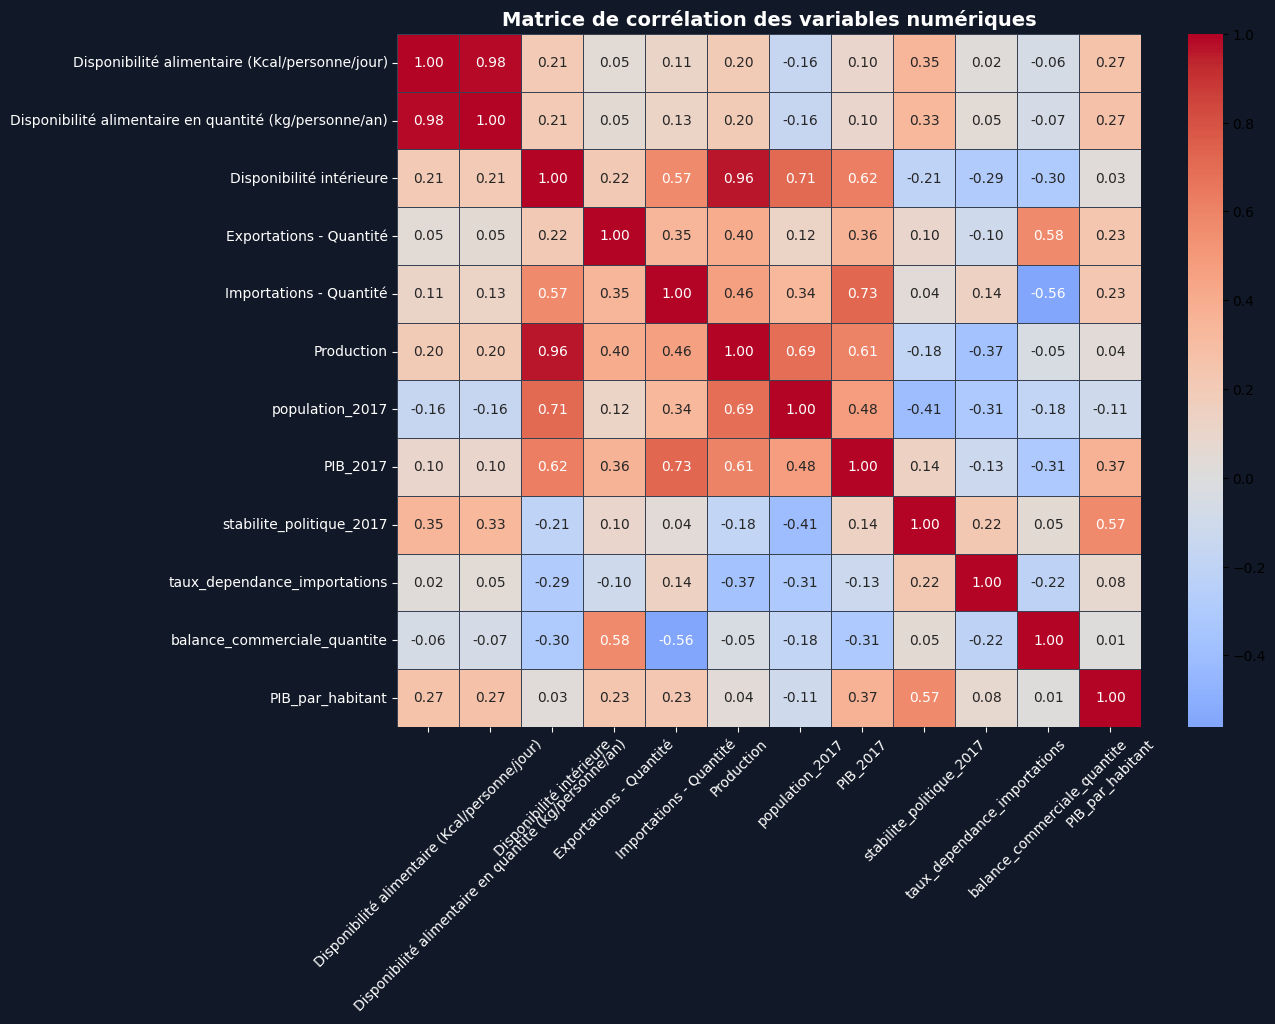

In [73]:
# Visualisation des corrélations entre variables
# Les valeurs proches de 1 indiquent une corrélation positive forte
# Les valeurs proches de -1 indiquent une corrélation négative forte
fig, ax = plt.subplots(figsize=(12, 9))

fig.patch.set_facecolor("#111827")
ax.set_facecolor("#111827")

sns.heatmap(
    matrice_correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    linecolor="#374151",
    cbar=True,
    ax=ax
)

ax.set_title("Matrice de corrélation des variables numériques", color="white", fontsize=14, fontweight="bold")

ax.tick_params(axis="x", colors="white", rotation=45)
ax.tick_params(axis="y", colors="white")

plt.show()

<div style="max-width: 980px; margin: 28px auto; padding: 22px; border: 1px solid #34D399; border-radius: 14px; background: linear-gradient(135deg, rgba(5, 46, 22, 0.88), rgba(17, 24, 39, 0.96)); color: #fff; box-shadow: 0 0 22px rgba(52, 211, 153, 0.20);">
  <b style="font-size:18px; color:#BBF7D0;">🧩 Lecture du graphique • Matrice de corrélation</b>
  <p style="margin-top:12px; line-height:1.6;">
    La heatmap représente les corrélations entre toutes les variables numériques. Les zones rouges indiquent des corrélations positives,
    les zones bleues des corrélations négatives, et les valeurs proches de 0 signalent une relation plus faible.
  </p>
  <div style="margin-top:14px; padding:7px; border:1px solid #38BDF8; border-radius:10px; background:rgba(8, 47, 73, 0.35);">
    <strong style="color:#BAE6FD;">🔍 Ce qu’on observe :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Plusieurs variables de taille sont fortement liées : la production, la disponibilité intérieure, la population et le PIB.
      Les deux indicateurs de disponibilité alimentaire sont également presque redondants, avec une corrélation très élevée.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #F59E0B; border-radius:10px; background:rgba(120, 53, 15, 0.35);">
    <strong style="color:#FDE68A;">📌 Pourquoi ce graphique est utile ?</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Il permet de comprendre visuellement pourquoi certaines variables se regroupent dans le cercle des corrélations.
      Des variables fortement corrélées auront tendance à pointer dans une direction similaire dans l’ACP.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #22C55E; border-radius:10px; background:rgba(6, 78, 59, 0.35);">
    <strong style="color:#86EFAC;">👉 En clair :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      La heatmap confirme que le dataset contient des groupes de variables liées entre elles.
      L’ACP permet ensuite de transformer ces relations en axes plus faciles à interpréter.
    </p>
  </div>
</div>

In [74]:
# Extraction des corrélations les plus fortes hors diagonale
# Cela permet de commenter les relations principales entre variables
correlations_long = (
    matrice_correlation
    .where(np.triu(np.ones(matrice_correlation.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

correlations_long.columns = ["variable_1", "variable_2", "correlation"]
correlations_long["correlation_absolue"] = correlations_long["correlation"].abs()

correlations_fortes = correlations_long.sort_values("correlation_absolue", ascending=False)

display(correlations_fortes.head(15))

,variable_1,variable_2,correlation,correlation_absolue
1,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/pers...,0.98,0.98
29,Disponibilité intérieure,Production,0.96,0.96
55,Importations - Quantité,PIB_2017,0.73,0.73
30,Disponibilité intérieure,population_2017,0.71,0.71
66,Production,population_2017,0.69,0.69
31,Disponibilité intérieure,PIB_2017,0.62,0.62
67,Production,PIB_2017,0.61,0.61
46,Exportations - Quantité,balance_commerciale_quantite,0.58,0.58
107,stabilite_politique_2017,PIB_par_habitant,0.57,0.57
28,Disponibilité intérieure,Importations - Quantité,0.57,0.57


<div style="max-width: 980px; margin: 35px auto; padding: 24px; border: 1px solid #10B981; border-radius: 14px; background: linear-gradient(135deg, rgba(6, 78, 59, 0.92), rgba(17, 24, 39, 0.96)); color: #fff; box-shadow: 0 0 25px rgba(16, 185, 129, 0.22);">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <b style="font-size:19px; color:#86EFAC;">🔗 Étape 4.2 • Corrélations entre variables</b>
  </div>
  <p style="line-height:1.6;">
    Cette étape complète l’interprétation de l’ACP en analysant les relations directes entre les variables numériques.
    La matrice de corrélation permet d’identifier les variables qui évoluent ensemble ou, au contraire, dans des directions opposées.
  </p>
  <div style="display:grid; grid-template-columns:1fr 1fr; gap:12px; margin-top:18px;">
    <div style="padding:4px; border:1px solid #22C55E; border-radius:10px; background:rgba(20, 83, 45, 0.35);">
      <strong style="color:#86EFAC;">✅ Corrélations fortes positives</strong>
      <ul style="margin-bottom:0; line-height:1.7;">
        <li>Disponibilité alimentaire kcal et kg/personne/an : <strong>0,98</strong></li>
        <li>Disponibilité intérieure et production : <strong>0,96</strong></li>
        <li>Importations et PIB 2017 : <strong>0,73</strong></li>
        <li>Disponibilité intérieure et population : <strong>0,71</strong></li>
      </ul>
    </div>
    <div style="padding:4px; border:1px solid #F472B6; border-radius:10px; background:rgba(80, 7, 36, 0.35);">
      <strong style="color:#FBCFE8;">📉 Corrélations négatives notables</strong>
      <ul style="margin-bottom:0; line-height:1.7;">
        <li>Importations et balance commerciale : <strong>-0,56</strong></li>
        <li>Population et stabilité politique : <strong>-0,41</strong></li>
        <li>Production et taux de dépendance aux importations : <strong>-0,37</strong></li>
        <li>PIB 2017 et balance commerciale : <strong>-0,31</strong></li>
      </ul>
    </div>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #F59E0B; border-radius:10px; background:rgba(120, 53, 15, 0.35);">
    <strong style="color:#FDE68A;">📌 Point méthodologique :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Une corrélation proche de <strong>1</strong> signifie que deux variables augmentent ensemble.
      Une corrélation proche de <strong>-1</strong> signifie qu’elles évoluent en sens inverse.
      Une corrélation proche de <strong>0</strong> indique une relation linéaire faible ou inexistante.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #38BDF8; border-radius:10px; background:rgba(8, 47, 73, 0.35);">
    <strong style="color:#BAE6FD;">🔎 Lien avec l’ACP :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      L’ACP est pertinente car plusieurs variables sont corrélées entre elles.
      Elle permet donc de résumer ces redondances dans quelques axes synthétiques, plutôt que d’analyser séparément chaque variable.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #22C55E; border-radius:10px; background:rgba(6, 78, 59, 0.35);">
    <strong style="color:#86EFAC;">👉 En clair :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Les corrélations montrent que les variables de volume, de production, de PIB et de disponibilité sont liées.
      Cela confirme que l’ACP est adaptée pour réduire la complexité du dataset.
    </p>
  </div>
</div>

<a id="etape4_3"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(134,239,172,0.28);
  border-radius:12px;
  background:rgba(134,239,172,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(89%) sepia(17%) saturate(874%) hue-rotate(88deg) brightness(101%) contrast(101%);
      ">
    </a>
    <span>4.3 • Positionnement des pays</span>
  </h3>
</div>

In [75]:
# Identification des pays les plus extrêmes sur PC1 et PC2
# Cela permet de comprendre quels pays illustrent le mieux chaque axe
print("Pays les plus à droite sur PC1 :")
display(projection_individus.sort_values("PC1", ascending=False).head(10)[["Zone", "PC1", "PC2", "PC3", "PC4"]])

print("Pays les plus à gauche sur PC1 :")
display(projection_individus.sort_values("PC1", ascending=True).head(10)[["Zone", "PC1", "PC2", "PC3", "PC4"]])

print("Pays les plus hauts sur PC2 :")
display(projection_individus.sort_values("PC2", ascending=False).head(10)[["Zone", "PC1", "PC2", "PC3", "PC4"]])

print("Pays les plus bas sur PC2 :")
display(projection_individus.sort_values("PC2", ascending=True).head(10)[["Zone", "PC1", "PC2", "PC3", "PC4"]])

Pays les plus à droite sur PC1 :


,Zone,PC1,PC2,PC3,PC4
56,Japon,8.21,0.56,-4.67,-3.11
73,Mexique,7.65,-0.81,-3.74,1.21
39,Fédération de Russie,7.06,-1.65,0.64,2.01
3,Allemagne,6.00,0.98,-0.04,-3.79
93,Royaume-Uni de Grande-Bretagne et d'Irlande du...,5.70,1.42,-1.17,-1.57
38,France,4.40,0.73,0.93,-2.02
48,Indonésie,4.08,-3.87,0.55,0.72
0,Afrique du Sud,3.28,0.37,-1.57,1.37
6,Arabie saoudite,2.86,1.49,-3.33,0.58
22,Canada,2.72,2.25,0.70,0.11


Pays les plus à gauche sur PC1 :


,Zone,PC1,PC2,PC3,PC4
124,Îles Salomon,-1.99,-0.65,-0.95,-1.36
62,Lesotho,-1.82,-0.76,-0.86,-0.93
60,Kirghizistan,-1.78,-1.26,-0.82,-1.10
17,Botswana,-1.73,-0.61,-0.18,-1.23
100,Sierra Leone,-1.66,-1.30,-0.38,-0.86
76,Namibie,-1.64,-0.08,-0.61,-0.93
35,Eswatini,-1.60,-1.25,-0.08,-0.49
74,Monténégro,-1.59,-0.16,-0.52,-0.39
65,Libéria,-1.58,-0.75,-0.87,-0.64
68,Macédoine du Nord,-1.53,0.13,-0.98,-0.34


Pays les plus hauts sur PC2 :


,Zone,PC1,PC2,PC3,PC4
98,Samoa,-0.92,3.86,-0.69,2.00
5,Antigua-et-Barbuda,-0.93,3.62,-0.63,1.73
67,Luxembourg,-1.14,3.03,-0.45,-2.75
122,Émirats arabes unis,0.67,2.98,-1.91,-0.49
53,Israël,0.86,2.92,0.72,3.16
9,Australie,2.00,2.89,0.94,1.18
12,Barbade,-0.69,2.68,0.39,1.84
52,Islande,-0.82,2.53,0.46,-0.68
112,Trinité-et-Tobago,-0.55,2.52,0.10,2.11
81,Nouvelle-Zélande,-0.42,2.40,0.73,0.37


Pays les plus bas sur PC2 :


,Zone,PC1,PC2,PC3,PC4
84,Pakistan,2.04,-4.45,0.34,1.02
79,Nigéria,0.53,-4.18,0.11,0.13
48,Indonésie,4.08,-3.87,0.55,0.72
119,Yémen,-0.81,-2.78,-0.58,0.46
59,Kenya,-1.08,-2.67,0.14,-0.28
78,Niger,-1.43,-2.45,-0.03,-0.35
121,Égypte,1.27,-2.43,-0.21,0.84
108,Tchad,-1.51,-2.43,-0.03,-0.39
21,Cameroun,-1.22,-2.31,0.17,-0.13
83,Ouganda,-1.16,-2.27,0.18,-0.36


In [76]:
# Attribution d'un quadrant à chaque pays sur le plan PC1 / PC2
# Cette lecture donne une première segmentation visuelle avant le clustering
def attribuer_quadrant(row):
    if row["PC1"] >= 0 and row["PC2"] >= 0:
        return "PC1+ / PC2+"
    elif row["PC1"] < 0 and row["PC2"] >= 0:
        return "PC1- / PC2+"
    elif row["PC1"] < 0 and row["PC2"] < 0:
        return "PC1- / PC2-"
    else:
        return "PC1+ / PC2-"

projection_individus["quadrant_PC1_PC2"] = projection_individus.apply(attribuer_quadrant, axis=1)

resume_quadrants = (
    projection_individus
    .groupby("quadrant_PC1_PC2")
    .agg(
        nombre_pays=("Zone", "count"),
        PC1_moyen=("PC1", "mean"),
        PC2_moyen=("PC2", "mean")
    )
    .round(2)
    .reset_index()
)

display(resume_quadrants)

,quadrant_PC1_PC2,nombre_pays,PC1_moyen,PC2_moyen
0,PC1+ / PC2+,17,2.88,1.38
1,PC1+ / PC2-,19,2.19,-1.73
2,PC1- / PC2+,44,-0.83,1.33
3,PC1- / PC2-,45,-1.20,-1.09


In [77]:
# Exemples de pays représentatifs par quadrant
# On affiche quelques pays pour faciliter la lecture métier des groupes visuels
for quadrant in projection_individus["quadrant_PC1_PC2"].unique():
    print(f"\nExemples de pays dans le quadrant {quadrant} :")
    display(
        projection_individus[projection_individus["quadrant_PC1_PC2"] == quadrant]
        [["Zone", "PC1", "PC2", "PC3", "PC4"]]
        .head(8)
    )


Exemples de pays dans le quadrant PC1+ / PC2+ :


,Zone,PC1,PC2,PC3,PC4
0,Afrique du Sud,3.28,0.37,-1.57,1.37
3,Allemagne,6.00,0.98,-0.04,-3.79
6,Arabie saoudite,2.86,1.49,-3.33,0.58
7,Argentine,2.53,1.10,1.98,2.17
9,Australie,2.00,2.89,0.94,1.18
13,Belgique,0.44,0.70,2.26,-2.89
22,Canada,2.72,2.25,0.70,0.11
23,Chili,0.62,1.38,0.31,1.06



Exemples de pays dans le quadrant PC1- / PC2+ :


,Zone,PC1,PC2,PC3,PC4
1,Albanie,-1.45,0.35,-0.71,-0.29
5,Antigua-et-Barbuda,-0.93,3.62,-0.63,1.73
10,Autriche,-0.49,1.23,-0.05,-1.42
12,Barbade,-0.69,2.68,0.39,1.84
14,Belize,-1.09,0.27,0.34,1.00
15,Bolivie (État plurinational de),-0.21,0.66,0.47,2.03
18,Bulgarie,-0.90,0.40,-0.46,-0.13
19,Bélarus,-0.50,0.11,1.15,0.75



Exemples de pays dans le quadrant PC1- / PC2- :


,Zone,PC1,PC2,PC3,PC4
2,Algérie,-0.69,-2.09,0.21,-0.01
4,Angola,-0.59,-0.79,-2.02,-1.00
8,Arménie,-1.50,-0.49,-0.78,-0.27
11,Azerbaïdjan,-1.15,-1.18,-0.12,0.11
16,Bosnie-Herzégovine,-1.25,-0.69,0.11,0.23
17,Botswana,-1.73,-0.61,-0.18,-1.23
20,Bénin,-1.28,-0.37,-1.31,-0.79
21,Cameroun,-1.22,-2.31,0.17,-0.13



Exemples de pays dans le quadrant PC1+ / PC2- :


,Zone,PC1,PC2,PC3,PC4
25,Colombie,1.66,-0.56,0.20,1.87
39,Fédération de Russie,7.06,-1.65,0.64,2.01
48,Indonésie,4.08,-3.87,0.55,0.72
49,Iran (République islamique d'),2.52,-1.34,0.89,1.89
50,Iraq,0.42,-1.50,-2.89,-0.36
54,Italie,2.26,-0.11,1.02,-0.92
71,Maroc,0.01,-0.95,0.39,0.95
73,Mexique,7.65,-0.81,-3.74,1.21


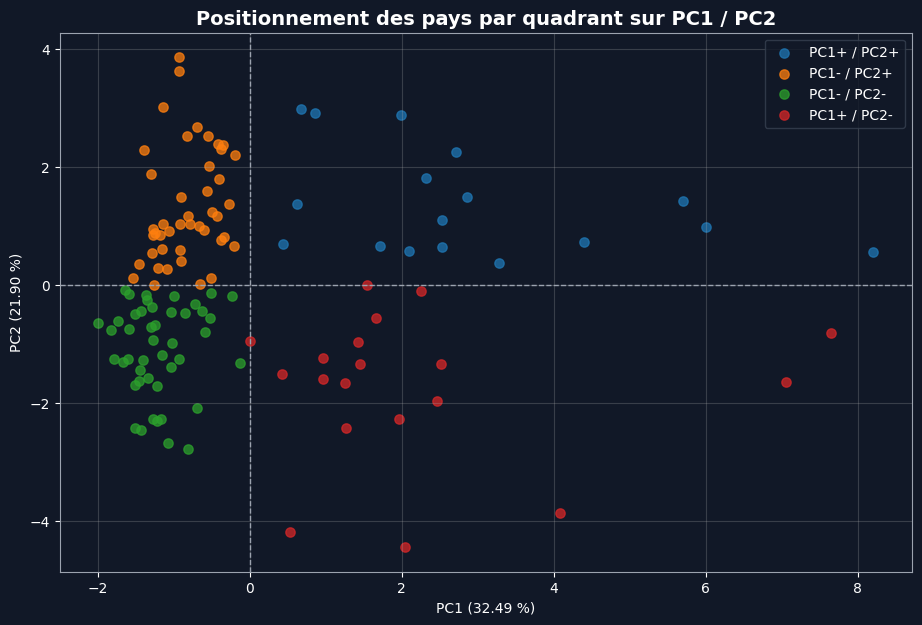

In [78]:
# Projection des pays avec coloration par quadrant
# Cette visualisation permet de lire les premières familles de profils avant la classification
fig, ax = plt.subplots(figsize=(11, 7))

fig.patch.set_facecolor("#111827")
ax.set_facecolor("#111827")

quadrants = projection_individus["quadrant_PC1_PC2"].unique()

for quadrant in quadrants:
    data_quadrant = projection_individus[projection_individus["quadrant_PC1_PC2"] == quadrant]

    ax.scatter(
        data_quadrant["PC1"],
        data_quadrant["PC2"],
        label=quadrant,
        alpha=0.75,
        s=45
    )

ax.axhline(0, color="#9CA3AF", linestyle="--", linewidth=1)
ax.axvline(0, color="#9CA3AF", linestyle="--", linewidth=1)

ax.set_title("Positionnement des pays par quadrant sur PC1 / PC2", color="white", fontsize=14, fontweight="bold")
ax.set_xlabel(f"PC1 ({variance_expliquee[0] * 100:.2f} %)", color="white")
ax.set_ylabel(f"PC2 ({variance_expliquee[1] * 100:.2f} %)", color="white")

ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")

ax.grid(alpha=0.25)

for spine in ax.spines.values():
    spine.set_color("#9CA3AF")

legend = ax.legend(facecolor="#111827", edgecolor="#374151")
for text in legend.get_texts():
    text.set_color("white")

plt.show()

<div style="max-width: 980px; margin: 28px auto; padding: 22px; border: 1px solid #10B981; border-radius: 14px; background: linear-gradient(135deg, rgba(4, 120, 87, 0.82), rgba(17, 24, 39, 0.96)); color: #fff; box-shadow: 0 0 22px rgba(16, 185, 129, 0.20);">
  <b style="font-size:18px; color:#A7F3D0;">🧭 Lecture du graphique • Positionnement des pays sur PC1 / PC2</b>
  <p style="margin-top:12px; line-height:1.6;">
    Ce graphique représente les pays sur le premier plan factoriel de l’ACP.
    L’axe horizontal correspond à PC1, qui explique <strong>32,49 %</strong> de l’information,
    et l’axe vertical correspond à PC2, qui explique <strong>21,90 %</strong> de l’information.
  </p>
  <div style="display:grid; grid-template-columns:1fr 1fr; gap:12px; margin-top:18px;">
    <div style="padding:4px; border:1px solid #22C55E; border-radius:10px; background:rgba(20, 83, 45, 0.35);">
      <strong style="color:#86EFAC;">✅ À quoi sert ce graphique ?</strong>
      <ul style="margin-bottom:0; line-height:1.7;">
        <li>Visualiser les ressemblances entre pays.</li>
        <li>Identifier les pays isolés ou très spécifiques.</li>
        <li>Observer les premières familles de profils.</li>
        <li>Préparer l’analyse de clustering.</li>
      </ul>
    </div>
    <div style="padding:4px; border:1px solid #38BDF8; border-radius:10px; background:rgba(8, 47, 73, 0.35);">
      <strong style="color:#BAE6FD;">📊 Comment le lire ?</strong>
      <ul style="margin-bottom:0; line-height:1.7;">
        <li>Deux pays proches ont des profils similaires.</li>
        <li>Un pays éloigné du centre a un profil plus marqué.</li>
        <li>Les quadrants donnent une première segmentation visuelle.</li>
        <li>Les axes ne sont pas des variables directes, mais des combinaisons de variables.</li>
      </ul>
    </div>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #F59E0B; border-radius:10px; background:rgba(120, 53, 15, 0.35);">
    <strong style="color:#FDE68A;">📌 Ce qu’on observe :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Une majorité de pays se concentre à gauche du graphique, tandis que certains pays ressortent plus fortement à droite.
      Ces pays ont généralement des volumes économiques, alimentaires ou de production plus importants.
      Le graphique montre donc une différence nette entre les pays de taille plus modérée et les pays plus structurants.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #A855F7; border-radius:10px; background:rgba(88, 28, 135, 0.28);">
    <strong style="color:#E9D5FF;">🔎 Attention :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Cette lecture reste exploratoire. Les quadrants donnent une première intuition, mais ils ne remplacent pas une méthode de classification.
      Les regroupements définitifs seront construits ensuite avec la classification ascendante hiérarchique et le K-means.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #22C55E; border-radius:10px; background:rgba(6, 78, 59, 0.35);">
    <strong style="color:#86EFAC;">👉 En clair :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Ce graphique donne une première carte des pays. Il montre quels pays se ressemblent, lesquels se distinguent,
      et prépare la création de groupes plus précis dans la partie clustering.
    </p>
  </div>
</div>

<div style="max-width: 980px; margin: 35px auto; padding: 24px; border: 1px solid #10B981; border-radius: 14px; background: linear-gradient(135deg, rgba(6, 78, 59, 0.92), rgba(17, 24, 39, 0.96)); color: #fff; box-shadow: 0 0 25px rgba(16, 185, 129, 0.22);">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <b style="font-size:19px; color:#86EFAC;">🗺️ Étape 4.3 • Positionnement des pays</b>
  </div>
  <p style="line-height:1.6;">
    Cette étape analyse la position des pays sur les axes principaux de l’ACP.
    Chaque pays est projeté dans un nouvel espace factoriel : les pays proches ont des profils similaires,
    tandis que les pays éloignés présentent des caractéristiques plus différentes.
  </p>
  <div style="display:grid; grid-template-columns:1fr 1fr; gap:12px; margin-top:18px;">
    <div style="padding:4px; border:1px solid #22C55E; border-radius:10px; background:rgba(20, 83, 45, 0.35);">
      <strong style="color:#86EFAC;">✅ Lecture par axes</strong>
      <ul style="margin-bottom:0; line-height:1.7;">
        <li>À droite de PC1 : pays avec forts volumes économiques et alimentaires.</li>
        <li>À gauche de PC1 : pays plus petits ou moins structurants sur les volumes.</li>
        <li>En haut de PC2 : pays avec meilleurs indicateurs de disponibilité, stabilité ou richesse par habitant.</li>
        <li>En bas de PC2 : pays avec profils plus fragiles ou plus éloignés de ces indicateurs.</li>
      </ul>
    </div>
    <div style="padding:4px; border:1px solid #38BDF8; border-radius:10px; background:rgba(8, 47, 73, 0.35);">
      <strong style="color:#BAE6FD;">📊 Répartition par quadrants</strong>
      <ul style="margin-bottom:0; line-height:1.7;">
        <li><strong>PC1+ / PC2+</strong> : 17 pays</li>
        <li><strong>PC1+ / PC2-</strong> : 19 pays</li>
        <li><strong>PC1- / PC2+</strong> : 44 pays</li>
        <li><strong>PC1- / PC2-</strong> : 45 pays</li>
      </ul>
    </div>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #F59E0B; border-radius:10px; background:rgba(120, 53, 15, 0.35);">
    <strong style="color:#FDE68A;">📌 Point méthodologique :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Les quadrants ne sont pas encore des clusters définitifs.
      Ils donnent une première lecture visuelle des profils pays, mais la classification finale sera réalisée ensuite avec la CAH et K-means.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #A855F7; border-radius:10px; background:rgba(88, 28, 135, 0.28);">
    <strong style="color:#E9D5FF;">🔎 Exemples observés :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Des pays comme le <strong>Japon</strong>, le <strong>Mexique</strong>, la <strong>Russie</strong>, l’<strong>Allemagne</strong> ou le <strong>Royaume-Uni</strong>
      ressortent fortement sur PC1, ce qui traduit des profils économiques et alimentaires importants.
      À l’inverse, certains pays plus petits ou moins volumineux se positionnent davantage à gauche du plan factoriel.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #22C55E; border-radius:10px; background:rgba(6, 78, 59, 0.35);">
    <strong style="color:#86EFAC;">👉 En clair :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      La projection des pays permet déjà d’identifier des familles de profils.
      Elle prépare directement la suite de l’analyse, où ces regroupements seront formalisés avec le clustering.
    </p>
  </div>
</div>

<a id="etape5"></a>
<div style="
  width:78%;
  margin:16px auto 10px auto;
  border:1px solid rgba(244,114,182,0.34);
  border-radius:14px;
  background:linear-gradient(135deg, rgba(92,8,54,0.96), rgba(48,7,29,0.98));
  box-sizing:border-box;
">
  <h2 style="
    margin:0;
    padding:15px 20px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:22px;
    font-weight:750;
    gap:12px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:24px; height:24px; display:block;
        filter: brightness(0) saturate(100%) invert(79%) sepia(23%) saturate(1712%) hue-rotate(291deg) brightness(102%) contrast(101%);
      ">
    </a>
    <span style="color:#F9A8D4;">🪴 Étape 5</span>
    <span>• Classification ascendante hiérarchique (CAH)</span>
  </h2>
</div>

<a id="etape5_1"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(249,168,212,0.28);
  border-radius:12px;
  background:rgba(249,168,212,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(88%) sepia(18%) saturate(832%) hue-rotate(281deg) brightness(103%) contrast(102%);
      ">
    </a>
    <span>5.1 • Calcul de la CAH</span>
  </h3>
</div>

In [79]:
# Préparation des données pour la classification ascendante hiérarchique
# On utilise les axes ACP retenus afin de regrouper les pays à partir d'une information synthétique
# et déjà standardisée
variables_cah = axes_retenus

X_cah = df_pca_retenu[variables_cah].copy()

print("✅ Matrice utilisée pour la CAH créée.")
print("Dimensions de X_cah :", X_cah.shape)
print("Axes utilisés :", variables_cah)

display(X_cah.head())

✅ Matrice utilisée pour la CAH créée.
Dimensions de X_cah : (125, 4)
Axes utilisés : ['PC1', 'PC2', 'PC3', 'PC4']


,PC1,PC2,PC3,PC4
0,3.28,0.37,-1.57,1.37
1,-1.45,0.35,-0.71,-0.29
2,-0.69,-2.09,0.21,-0.01
3,6.00,0.98,-0.04,-3.79
4,-0.59,-0.79,-2.02,-1.00


In [80]:
# Calcul de la classification ascendante hiérarchique
# La méthode de Ward est utilisée car elle cherche à créer des groupes homogènes
# en minimisant la variance à l'intérieur des clusters
from scipy.cluster.hierarchy import linkage

Z = linkage(
    X_cah,
    method="ward"
)

print("✅ Classification ascendante hiérarchique calculée avec succès.")
print("Dimensions de la matrice de linkage :", Z.shape)

display(pd.DataFrame(
    Z[:10],
    columns=["cluster_1", "cluster_2", "distance", "nombre_pays_regroupes"]
))

✅ Classification ascendante hiérarchique calculée avec succès.
Dimensions de la matrice de linkage : (124, 4)


,cluster_1,cluster_2,distance,nombre_pays_regroupes
0,78.00,108.00,0.09,2.00
1,8.00,45.00,0.14,2.00
2,10.00,106.00,0.14,2.00
3,16.00,96.00,0.20,2.00
4,29.00,83.00,0.21,2.00
5,21.00,129.00,0.26,3.00
6,28.00,116.00,0.29,2.00
7,66.00,102.00,0.31,2.00
8,86.00,107.00,0.31,2.00
9,27.00,36.00,0.31,2.00


<div style="max-width: 980px; margin: 35px auto; padding: 24px; border: 1px solid #BE185D; border-radius: 14px; background: linear-gradient(135deg, rgba(80, 7, 36, 0.92), rgba(25, 18, 28, 0.96)); color: #fff; box-shadow: 0 0 25px rgba(190, 24, 93, 0.25);">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <b style="font-size:19px; color:#F9A8D4;">🌿 Étape 5.1 • Calcul de la classification ascendante hiérarchique</b>
  </div>
  <p style="line-height:1.6;">
    La classification ascendante hiérarchique, ou <strong>CAH</strong>, a été calculée à partir des
    <strong>4 axes principaux retenus de l’ACP</strong>. Ces axes résument plus de 80 % de l’information initiale,
    ce qui permet de regrouper les pays à partir d’une information synthétique et standardisée.
  </p>
  <div style="display:grid; grid-template-columns:1fr 1fr; gap:12px; margin-top:18px;">
    <div style="padding:4px; border:1px solid #22C55E; border-radius:10px; background:rgba(20, 83, 45, 0.35);">
      <strong style="color:#86EFAC;">✅ Données utilisées</strong>
      <ul style="margin-bottom:0; line-height:1.7;">
        <li><strong>125 pays</strong> analysés</li>
        <li><strong>4 axes ACP</strong> utilisés : PC1, PC2, PC3 et PC4</li>
        <li>Données déjà centrées-réduites via l’ACP</li>
        <li>Objectif : regrouper les pays aux profils proches</li>
      </ul>
    </div>
    <div style="padding:4px; border:1px solid #38BDF8; border-radius:10px; background:rgba(8, 47, 73, 0.35);">
      <strong style="color:#BAE6FD;">📊 Méthode utilisée</strong>
      <ul style="margin-bottom:0; line-height:1.7;">
        <li>Calcul avec la fonction <strong>linkage</strong></li>
        <li>Méthode de regroupement : <strong>Ward</strong></li>
        <li>Construction progressive des groupes de pays</li>
        <li>Production d’une matrice de linkage de dimension <strong>124 × 4</strong></li>
      </ul>
    </div>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #F59E0B; border-radius:10px; background:rgba(120, 53, 15, 0.35);">
    <strong style="color:#FDE68A;">📌 Point méthodologique :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      La méthode de Ward cherche à former des groupes homogènes en limitant la perte d’information à chaque fusion.
      En clair, elle essaie de regrouper progressivement les pays qui se ressemblent le plus, tout en évitant de créer
      des clusters trop dispersés.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #A855F7; border-radius:10px; background:rgba(88, 28, 135, 0.28);">
    <strong style="color:#E9D5FF;">🔎 À quoi sert cette étape ?</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Cette étape prépare la création des groupes de pays. Contrairement au K-means, la CAH permet d’observer
      visuellement comment les pays se regroupent progressivement grâce au dendrogramme.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #22C55E; border-radius:10px; background:rgba(6, 78, 59, 0.35);">
    <strong style="color:#86EFAC;">👉 En clair :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      La CAH est maintenant calculée : elle va permettre de visualiser les regroupements naturels entre pays et d’aider
      au choix d’un nombre de clusters pertinent.
    </p>
  </div>
</div>

<a id="etape5_2"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(249,168,212,0.28);
  border-radius:12px;
  background:rgba(249,168,212,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(88%) sepia(18%) saturate(832%) hue-rotate(281deg) brightness(103%) contrast(102%);
      ">
    </a>
    <span>5.2 • Dendrogramme</span>
  </h3>
</div>

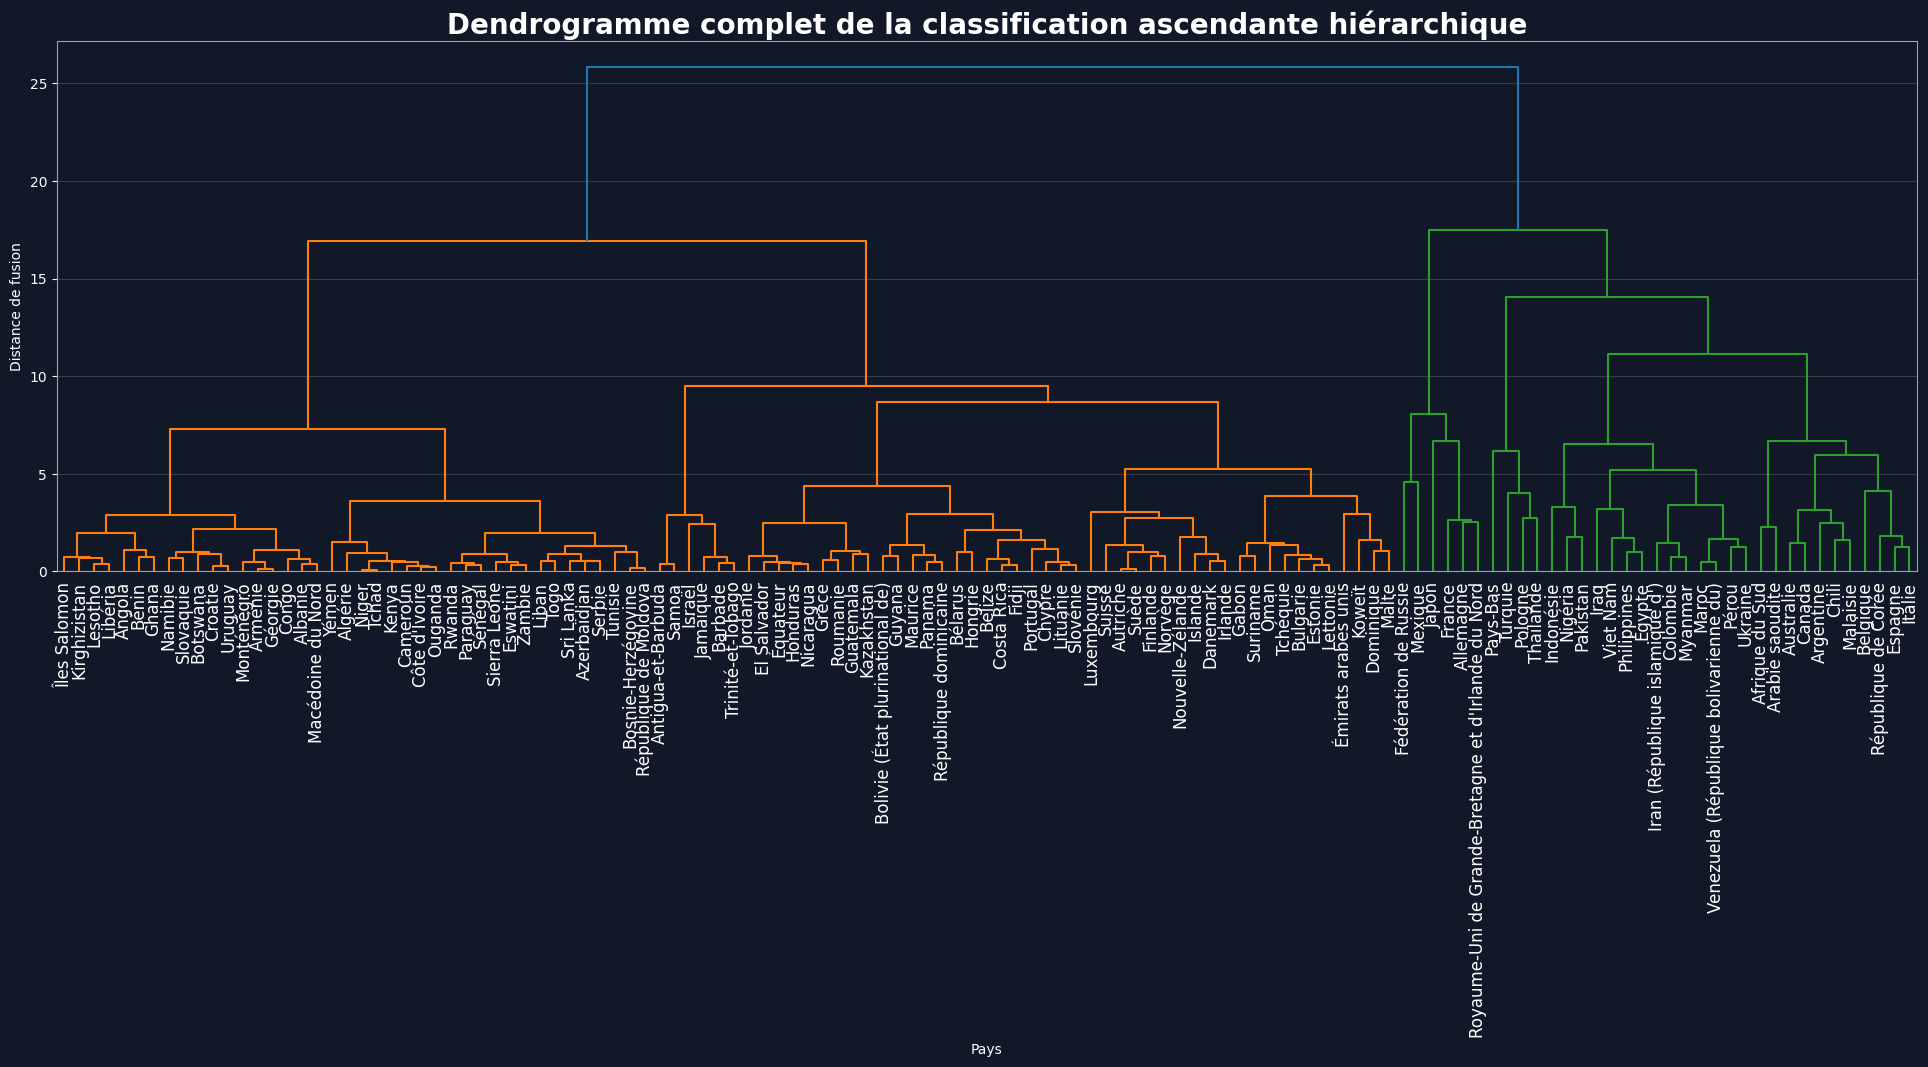

In [81]:
# Visualisation du dendrogramme complet
# Ce graphique montre l'ensemble des regroupements entre les pays.
# Avec 125 pays, les noms sont nombreux : il sert surtout à valider la structure globale.
from scipy.cluster.hierarchy import dendrogram

fig, ax = plt.subplots(figsize=(24, 10))

fig.patch.set_facecolor("#111827")
ax.set_facecolor("#111827")

dendrogram(
    Z,
    labels=zones.values,
    leaf_rotation=90,
    leaf_font_size=12,
    color_threshold=None,
    ax=ax
)

ax.set_title(
    "Dendrogramme complet de la classification ascendante hiérarchique",
    color="white",
    fontsize=20,
    fontweight="bold"
)
ax.set_xlabel("Pays", color="white")
ax.set_ylabel("Distance de fusion", color="white")

ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")

ax.grid(axis="y", alpha=0.25)

for spine in ax.spines.values():
    spine.set_color("#9CA3AF")

plt.subplots_adjust(bottom=0.35)
plt.show()

<div style="max-width: 980px; margin: 35px auto; padding: 24px; border: 1px solid #BE185D; border-radius: 14px; background: linear-gradient(135deg, rgba(80, 7, 36, 0.92), rgba(25, 18, 28, 0.96)); color: #fff; box-shadow: 0 0 25px rgba(190, 24, 93, 0.25);">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <b style="font-size:19px; color:#F9A8D4;">🌳 Étape 5.2 • Lecture du dendrogramme</b>
  </div>
  <p style="line-height:1.6;">
    Le dendrogramme permet de visualiser le fonctionnement de la classification ascendante hiérarchique.
    Chaque pays commence seul, puis les pays les plus proches sont regroupés progressivement jusqu’à former
    des groupes de plus en plus larges.
  </p>
  <div style="display:grid; grid-template-columns:1fr 1fr; gap:12px; margin-top:18px;">
    <div style="padding:4px; border:1px solid #38BDF8; border-radius:10px; background:rgba(8, 47, 73, 0.35);">
      <strong style="color:#BAE6FD;">📈 Dendrogramme complet</strong>
      <ul style="margin-bottom:0; line-height:1.7;">
        <li>Affiche les <strong>125 pays</strong></li>
        <li>Permet de valider la structure globale</li>
        <li>Montre les regroupements progressifs</li>
        <li>Les noms sont nombreux, donc moins lisibles</li>
      </ul>
    </div>
    <div style="padding:4px; border:1px solid #A855F7; border-radius:10px; background:rgba(88, 28, 135, 0.28);">
      <strong style="color:#E9D5FF;">🔍 Dendrogramme simplifié</strong>
      <ul style="margin-bottom:0; line-height:1.7;">
        <li>Affiche les derniers grands regroupements</li>
        <li>Facilite le choix du nombre de clusters</li>
        <li>Les nombres entre parenthèses représentent des groupes compressés</li>
        <li>Exemple : <strong>(18)</strong> signifie un groupe de 18 pays</li>
      </ul>
    </div>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #F59E0B; border-radius:10px; background:rgba(120, 53, 15, 0.35);">
    <strong style="color:#FDE68A;">📌 Comment lire le dendrogramme ?</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      L’axe vertical représente la <strong>distance de fusion</strong>. Plus deux groupes fusionnent haut dans le graphique,
      plus ils sont différents. Les grandes hausses de distance indiquent donc des regroupements importants et peuvent aider
      à choisir un nombre de clusters cohérent.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #EC4899; border-radius:10px; background:rgba(131, 24, 67, 0.35);">
    <strong style="color:#FBCFE8;">🧠 Interprétation :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Le dendrogramme montre plusieurs familles de pays. La version simplifiée met en évidence des coupures possibles
      avant les dernières grandes fusions. Cela suggère qu’un découpage en quelques groupes principaux peut être pertinent,
      plutôt qu’un nombre trop élevé de petits clusters.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #22C55E; border-radius:10px; background:rgba(6, 78, 59, 0.35);">
    <strong style="color:#86EFAC;">👉 En clair :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Le dendrogramme sert ici à comprendre la structure des regroupements et à guider le choix du nombre de clusters
      avant d’attribuer officiellement chaque pays à un groupe.
    </p>
  </div>
</div>

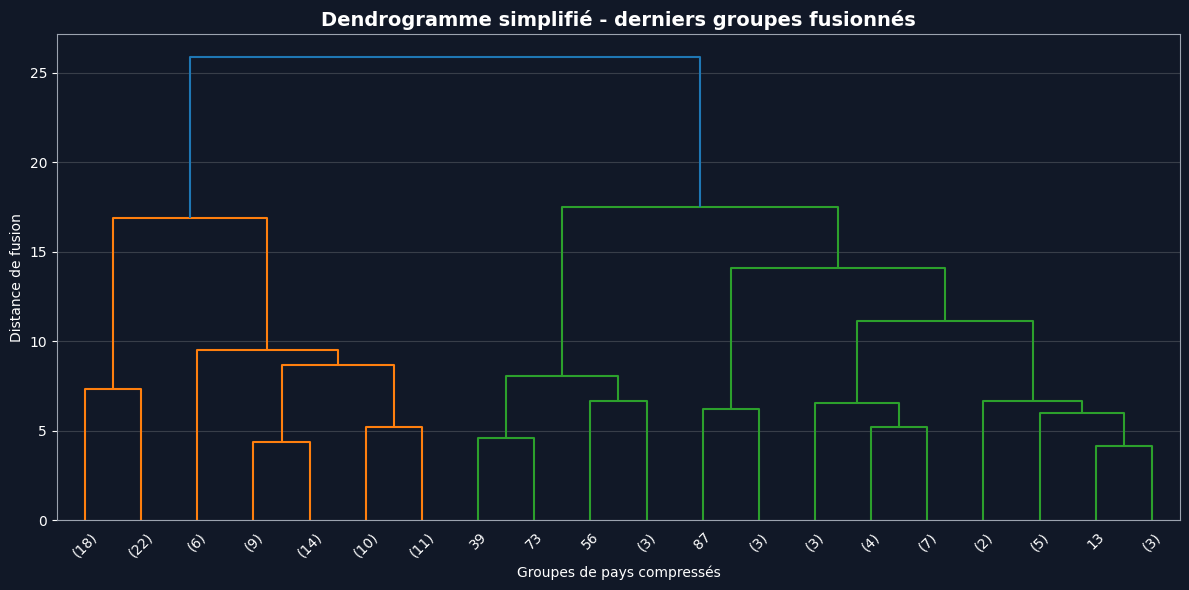

In [82]:
# Version simplifiée du dendrogramme
# Les nombres entre parenthèses correspondent à des groupes compressés de plusieurs pays
# Cette vue sert surtout à observer les dernières grandes fusions
fig, ax = plt.subplots(figsize=(12, 6))

fig.patch.set_facecolor("#111827")
ax.set_facecolor("#111827")

dendrogram(
    Z,
    truncate_mode="lastp",
    p=20,
    leaf_rotation=45,
    leaf_font_size=10,
    color_threshold=None,
    ax=ax
)

ax.set_title(
    "Dendrogramme simplifié - derniers groupes fusionnés",
    color="white",
    fontsize=14,
    fontweight="bold"
)
ax.set_xlabel("Groupes de pays compressés", color="white")
ax.set_ylabel("Distance de fusion", color="white")

ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")

ax.grid(axis="y", alpha=0.25)

for spine in ax.spines.values():
    spine.set_color("#9CA3AF")

plt.tight_layout()
plt.show()

<div style="max-width: 980px; margin: 35px auto; padding: 24px; border: 1px solid #BE185D; border-radius: 14px; background: linear-gradient(135deg, rgba(80, 7, 36, 0.92), rgba(25, 18, 28, 0.96)); color: #fff; box-shadow: 0 0 25px rgba(190, 24, 93, 0.25);">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <b style="font-size:19px; color:#F9A8D4;">📈 Lecture des distances de fusion</b>
  </div>
  <p style="line-height:1.6;">
    Le graphique des distances de fusion complète la lecture du dendrogramme. Il permet d’observer à quel moment
    les regroupements deviennent beaucoup plus coûteux, c’est-à-dire quand des groupes de pays assez différents
    commencent à être fusionnés.
  </p>
  <div style="display:grid; grid-template-columns:1fr 1fr; gap:12px; margin-top:18px;">
    <div style="padding:4px; border:1px solid #38BDF8; border-radius:10px; background:rgba(8, 47, 73, 0.35);">
      <strong style="color:#BAE6FD;">📊 Ce que montre le graphique</strong>
      <ul style="margin-bottom:0; line-height:1.7;">
        <li>Les premières fusions sont assez progressives</li>
        <li>Les distances augmentent plus fortement vers la fin</li>
        <li>Une forte hausse signale une fusion entre groupes très différents</li>
        <li>La dernière fusion atteint une distance élevée, autour de <strong>25,85</strong></li>
      </ul>
    </div>
    <div style="padding:4px; border:1px solid #F59E0B; border-radius:10px; background:rgba(120, 53, 15, 0.35);">
      <strong style="color:#FDE68A;">🎯 Utilité pour le choix des clusters</strong>
      <ul style="margin-bottom:0; line-height:1.7;">
        <li>On cherche une coupure avant les grandes hausses</li>
        <li>Une coupure trop tardive regroupe des profils trop différents</li>
        <li>Une coupure trop précoce crée trop de petits groupes</li>
        <li>Le graphique aide à trouver un compromis lisible</li>
      </ul>
    </div>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #A855F7; border-radius:10px; background:rgba(88, 28, 135, 0.28);">
    <strong style="color:#E9D5FF;">🔎 Interprétation :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      La forte augmentation des dernières distances confirme que les derniers regroupements fusionnent des groupes
      de pays de plus en plus différents. Cela justifie de ne pas aller jusqu’à un nombre trop faible de clusters.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #22C55E; border-radius:10px; background:rgba(6, 78, 59, 0.35);">
    <strong style="color:#86EFAC;">👉 En clair :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Les distances de fusion montrent qu’un découpage en quelques groupes principaux est pertinent.
      Cette lecture appuie le choix d’un nombre de clusters raisonnable pour la suite de l’analyse.
    </p>
  </div>
</div>

<a id="etape5_3"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(249,168,212,0.28);
  border-radius:12px;
  background:rgba(249,168,212,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(88%) sepia(18%) saturate(832%) hue-rotate(281deg) brightness(103%) contrast(102%);
      ">
    </a>
    <span>5.3 • Choix du nombre de clusters</span>
  </h3>
</div>

In [83]:
# Analyse des distances de fusion
# Les dernières fusions sont les plus importantes : elles indiquent à quel moment des groupes très différents sont regroupés
distances_fusion = pd.DataFrame({
    "etape_fusion": range(1, len(Z) + 1),
    "distance": Z[:, 2],
    "nombre_pays_regroupes": Z[:, 3]
})

display(distances_fusion.tail(15))

,etape_fusion,distance,nombre_pays_regroupes
109,110,5.23,21.00
110,111,5.98,9.00
111,112,6.18,4.00
112,113,6.54,14.00
113,114,6.66,11.00
114,115,6.67,4.00
115,116,7.31,40.00
116,117,8.05,6.00
117,118,8.65,44.00
118,119,9.49,50.00


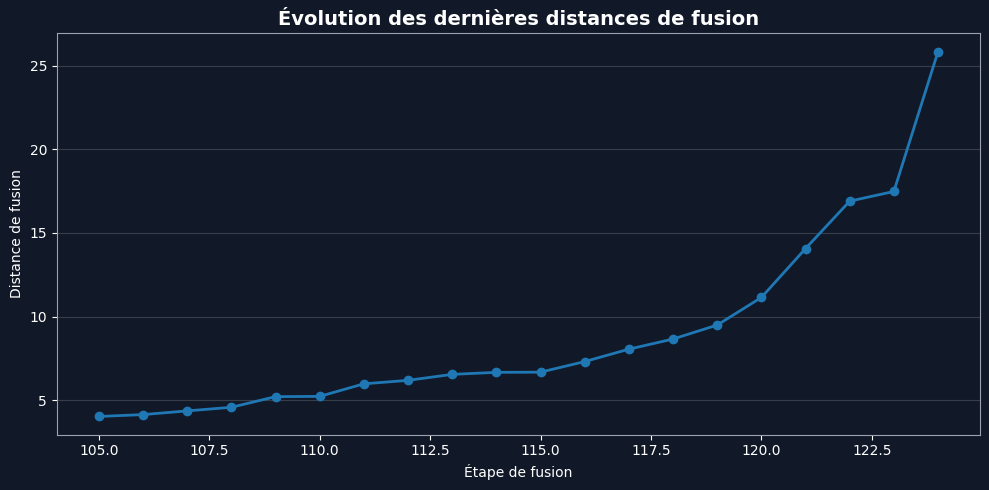

In [84]:
# Visualisation des dernières distances de fusion
# Une forte augmentation de la distance peut indiquer un nombre pertinent de clusters
dernieres_fusions = distances_fusion.tail(20).copy()

fig, ax = plt.subplots(figsize=(10, 5))

fig.patch.set_facecolor("#111827")
ax.set_facecolor("#111827")

ax.plot(
    dernieres_fusions["etape_fusion"],
    dernieres_fusions["distance"],
    marker="o",
    linewidth=2
)

ax.set_title("Évolution des dernières distances de fusion", color="white", fontsize=14, fontweight="bold")
ax.set_xlabel("Étape de fusion", color="white")
ax.set_ylabel("Distance de fusion", color="white")

ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")

ax.grid(axis="y", alpha=0.25)

for spine in ax.spines.values():
    spine.set_color("#9CA3AF")

plt.tight_layout()
plt.show()

In [85]:
# Choix du nombre de clusters pour la CAH
# Ce nombre pourra être ajusté après lecture du dendrogramme et comparaison avec K-means
from scipy.cluster.hierarchy import fcluster

nb_clusters_cah = 4

clusters_cah = fcluster(
    Z,
    t=nb_clusters_cah,
    criterion="maxclust"
)

df_cah = df_pca_retenu.copy()
df_cah["cluster_cah"] = clusters_cah

print("✅ Clusters CAH attribués.")
print("Nombre de clusters retenus :", nb_clusters_cah)
print("Dimensions de df_cah :", df_cah.shape)

display(df_cah.head())

✅ Clusters CAH attribués.
Nombre de clusters retenus : 4
Dimensions de df_cah : (125, 6)


,Zone,PC1,PC2,PC3,PC4,cluster_cah
0,Afrique du Sud,3.28,0.37,-1.57,1.37,4
1,Albanie,-1.45,0.35,-0.71,-0.29,1
2,Algérie,-0.69,-2.09,0.21,-0.01,1
3,Allemagne,6.00,0.98,-0.04,-3.79,3
4,Angola,-0.59,-0.79,-2.02,-1.00,1


In [86]:
# Vérification de la répartition des pays par cluster
# Cette étape permet de vérifier si les groupes obtenus sont exploitables et pas trop déséquilibrés
repartition_cah = (
    df_cah["cluster_cah"]
    .value_counts()
    .sort_index()
    .reset_index()
)

repartition_cah.columns = ["cluster_cah", "nombre_pays"]

display(repartition_cah)

,cluster_cah,nombre_pays
0,1,40
1,2,50
2,3,6
3,4,29


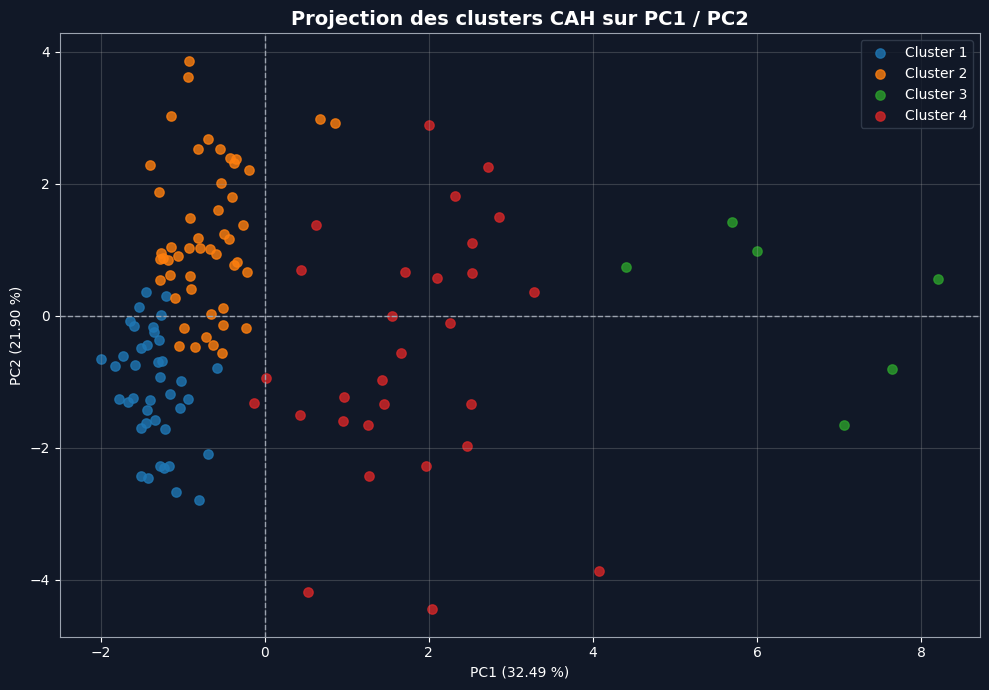

In [87]:
# Visualisation des clusters CAH sur le plan factoriel PC1 / PC2
# Cette projection permet de voir si les groupes se distinguent visuellement sur les deux premiers axes
fig, ax = plt.subplots(figsize=(10, 7))

fig.patch.set_facecolor("#111827")
ax.set_facecolor("#111827")

for cluster in sorted(df_cah["cluster_cah"].unique()):
    data_cluster = df_cah[df_cah["cluster_cah"] == cluster]
    ax.scatter(
        data_cluster["PC1"],
        data_cluster["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.8,
        s=45
    )

ax.axhline(0, color="#9CA3AF", linestyle="--", linewidth=1)
ax.axvline(0, color="#9CA3AF", linestyle="--", linewidth=1)

ax.set_title("Projection des clusters CAH sur PC1 / PC2", color="white", fontsize=14, fontweight="bold")
ax.set_xlabel(f"PC1 ({variance_expliquee[0] * 100:.2f} %)", color="white")
ax.set_ylabel(f"PC2 ({variance_expliquee[1] * 100:.2f} %)", color="white")

ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")

ax.grid(alpha=0.25)

for spine in ax.spines.values():
    spine.set_color("#9CA3AF")

legend = ax.legend(facecolor="#111827", edgecolor="#374151")
for text in legend.get_texts():
    text.set_color("white")

plt.tight_layout()
plt.show()

<div style="max-width: 980px; margin: 35px auto; padding: 24px; border: 1px solid #BE185D; border-radius: 14px; background: linear-gradient(135deg, rgba(80, 7, 36, 0.92), rgba(25, 18, 28, 0.96)); color: #fff; box-shadow: 0 0 25px rgba(190, 24, 93, 0.25);">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <b style="font-size:19px; color:#F9A8D4;">🎯 Étape 5.3 • Choix du nombre de clusters CAH</b>
  </div>
  <p style="line-height:1.6;">
    Après l’analyse du dendrogramme et des distances de fusion, un découpage en <strong>4 clusters</strong>
    a été retenu pour la classification ascendante hiérarchique. Ce choix permet de conserver une segmentation lisible,
    sans regrouper des pays trop différents entre eux.
  </p>
  <div style="display:grid; grid-template-columns:1fr 1fr; gap:12px; margin-top:18px;">
    <div style="padding:4px; border:1px solid #22C55E; border-radius:10px; background:rgba(20, 83, 45, 0.35);">
      <strong style="color:#86EFAC;">✅ Choix retenu</strong>
      <ul style="margin-bottom:0; line-height:1.7;">
        <li><strong>4 clusters</strong> retenus</li>
        <li>Découpage réalisé avec <strong>fcluster</strong></li>
        <li>Classification basée sur les axes PC1 à PC4</li>
        <li>Segmentation exploitable pour la comparaison avec K-means</li>
      </ul>
    </div>
    <div style="padding:4px; border:1px solid #38BDF8; border-radius:10px; background:rgba(8, 47, 73, 0.35);">
      <strong style="color:#BAE6FD;">📊 Répartition obtenue</strong>
      <ul style="margin-bottom:0; line-height:1.7;">
        <li>Cluster 1 : <strong>40 pays</strong></li>
        <li>Cluster 2 : <strong>50 pays</strong></li>
        <li>Cluster 3 : <strong>6 pays</strong></li>
        <li>Cluster 4 : <strong>29 pays</strong></li>
      </ul>
    </div>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #F59E0B; border-radius:10px; background:rgba(120, 53, 15, 0.35);">
    <strong style="color:#FDE68A;">📌 Justification du choix :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Le choix de 4 clusters est cohérent avec la lecture du dendrogramme et des dernières distances de fusion.
      Il permet d’éviter deux limites : obtenir trop de petits groupes difficiles à interpréter, ou au contraire fusionner
      des pays aux profils économiques et alimentaires trop différents.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #A855F7; border-radius:10px; background:rgba(88, 28, 135, 0.28);">
    <strong style="color:#E9D5FF;">🔎 Lecture du graphique de projection :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      La projection des clusters sur le plan PC1 / PC2 permet de vérifier visuellement si les groupes sont cohérents.
      Certains clusters sont bien concentrés, tandis que d’autres regroupent des pays plus dispersés, ce qui pourra être
      analysé plus précisément dans le profilage des clusters.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #EC4899; border-radius:10px; background:rgba(131, 24, 67, 0.35);">
    <strong style="color:#FBCFE8;">🧠 Attention d’interprétation :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      La CAH donne une première proposition de regroupement. Elle ne constitue pas encore la conclusion finale :
      les clusters devront être comparés avec ceux obtenus par K-means, puis interprétés à partir des variables métiers
      comme la dépendance aux importations, le PIB par habitant, la stabilité politique ou la disponibilité alimentaire.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #22C55E; border-radius:10px; background:rgba(6, 78, 59, 0.35);">
    <strong style="color:#86EFAC;">👉 En clair :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      La CAH propose une segmentation en 4 groupes de pays. Cette base servira ensuite à comparer les résultats avec
      le clustering K-means et à identifier les groupes de pays les plus intéressants pour l’exportation de volailles.
    </p>
  </div>
</div>

<a id="etape6"></a>
<div style="
  width:78%;
  margin:16px auto 10px auto;
  border:1px solid rgba(250,204,21,0.34);
  border-radius:14px;
  background:linear-gradient(135deg, rgba(88,64,5,0.96), rgba(44,31,4,0.98));
  box-sizing:border-box;
">
  <h2 style="
    margin:0;
    padding:15px 20px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:22px;
    font-weight:750;
    gap:12px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:24px; height:24px; display:block;
        filter: brightness(0) saturate(100%) invert(84%) sepia(49%) saturate(1328%) hue-rotate(346deg) brightness(103%) contrast(101%);
      ">
    </a>
    <span style="color:#FDE68A;">🎯 Étape 6</span>
    <span>• Clustering K-means</span>
  </h2>
</div>

<a id="etape6_1"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(253,230,138,0.28);
  border-radius:12px;
  background:rgba(253,230,138,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(92%) sepia(19%) saturate(938%) hue-rotate(335deg) brightness(102%) contrast(101%);
      ">
    </a>
    <span>6.1 • Méthode du coude / silhouette</span>
  </h3>
</div>

In [88]:
# Préparation des données pour le clustering K-means
# On utilise les mêmes axes ACP retenus que pour la CAH
# Cela permet de comparer les deux méthodes sur la même base de données
X_kmeans = df_pca_retenu[axes_retenus].copy()

print("✅ Matrice utilisée pour le K-means créée.")
print("Dimensions de X_kmeans :", X_kmeans.shape)
print("Axes utilisés :", axes_retenus)

display(X_kmeans.head())

✅ Matrice utilisée pour le K-means créée.
Dimensions de X_kmeans : (125, 4)
Axes utilisés : ['PC1', 'PC2', 'PC3', 'PC4']


,PC1,PC2,PC3,PC4
0,3.28,0.37,-1.57,1.37
1,-1.45,0.35,-0.71,-0.29
2,-0.69,-2.09,0.21,-0.01
3,6.00,0.98,-0.04,-3.79
4,-0.59,-0.79,-2.02,-1.00


In [89]:
# Recherche du nombre optimal de clusters avec la méthode du coude et le score de silhouette
# La méthode du coude observe l'inertie : plus elle baisse, plus les points sont proches de leur centre de cluster
# Le score de silhouette mesure la qualité de séparation des groupes : plus il est élevé, mieux les clusters sont séparés
inerties = []
silhouette_scores = []

k_values = range(2, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    labels = kmeans.fit_predict(X_kmeans)
    
    inerties.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_kmeans, labels))

df_kmeans_scores = pd.DataFrame({
    "nombre_clusters": list(k_values),
    "inertie": inerties,
    "score_silhouette": silhouette_scores
})

display(df_kmeans_scores)

,nombre_clusters,inertie,score_silhouette
0,2,869.88,0.41
1,3,697.40,0.27
2,4,556.92,0.29
3,5,455.92,0.31
4,6,407.84,0.31
5,7,360.87,0.29
6,8,329.18,0.26
7,9,294.17,0.27
8,10,276.96,0.28


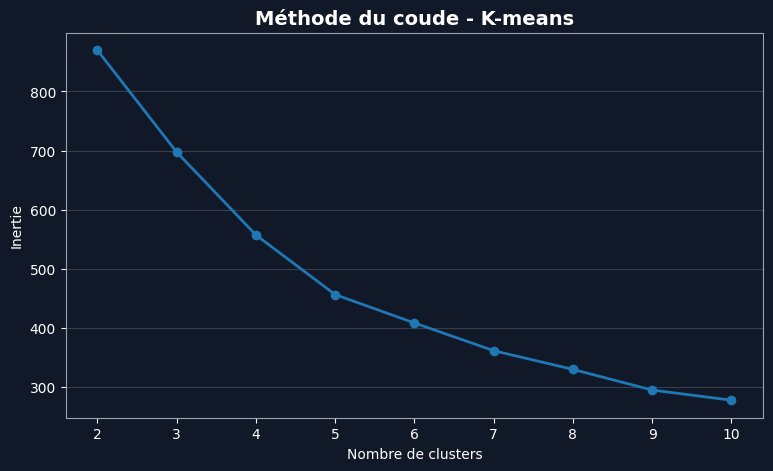

In [90]:
# Visualisation de la méthode du coude
# Ce graphique aide à repérer le moment où l'inertie diminue moins fortement
# Ce point peut indiquer un nombre de clusters pertinent
fig, ax = plt.subplots(figsize=(9, 5))

fig.patch.set_facecolor("#111827")
ax.set_facecolor("#111827")

ax.plot(
    df_kmeans_scores["nombre_clusters"],
    df_kmeans_scores["inertie"],
    marker="o",
    linewidth=2
)

ax.set_title("Méthode du coude - K-means", color="white", fontsize=14, fontweight="bold")
ax.set_xlabel("Nombre de clusters", color="white")
ax.set_ylabel("Inertie", color="white")

ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")

ax.grid(axis="y", alpha=0.25)

for spine in ax.spines.values():
    spine.set_color("#9CA3AF")

plt.show()

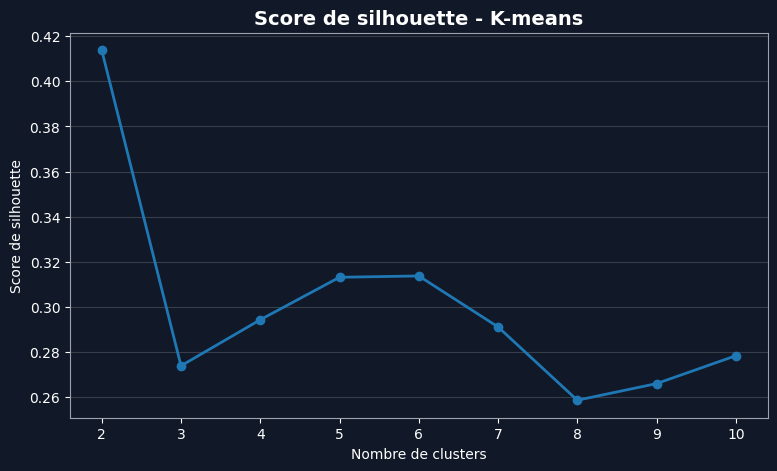

In [91]:
# Visualisation du score de silhouette
# Le score de silhouette permet de vérifier si les clusters sont bien séparés
# Un score plus élevé indique généralement une meilleure séparation entre les groupes
fig, ax = plt.subplots(figsize=(9, 5))

fig.patch.set_facecolor("#111827")
ax.set_facecolor("#111827")

ax.plot(
    df_kmeans_scores["nombre_clusters"],
    df_kmeans_scores["score_silhouette"],
    marker="o",
    linewidth=2
)

ax.set_title("Score de silhouette - K-means", color="white", fontsize=14, fontweight="bold")
ax.set_xlabel("Nombre de clusters", color="white")
ax.set_ylabel("Score de silhouette", color="white")

ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")

ax.grid(axis="y", alpha=0.25)

for spine in ax.spines.values():
    spine.set_color("#9CA3AF")

plt.show()

<div style="max-width:980px; margin:35px auto; padding:24px; border:1px solid #CA8A04; border-radius:14px; background:linear-gradient(135deg, rgba(66, 32, 6, 0.94), rgba(28, 25, 23, 0.96)); color:#fff; box-shadow:0 0 25px rgba(202, 138, 4, 0.25);">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <b style="font-size:19px; color:#FDE68A;">🎯 Étape 6.1 • Méthode du coude et score de silhouette</b>
  </div>
  <p style="line-height:1.6;">
    Le clustering K-means a été préparé à partir des <strong>4 axes ACP retenus</strong>. 
    L’objectif est de regrouper les pays selon leurs profils synthétiques, tout en utilisant la même base que pour la CAH afin de pouvoir comparer les deux méthodes.
  </p>
  <div style="display:grid; grid-template-columns:1fr 1fr; gap:12px; margin-top:18px;">
    <div style="padding:4px; border:1px solid #22C55E; border-radius:10px; background:rgba(20, 83, 45, 0.35);">
      <strong style="color:#86EFAC;">✅ Données utilisées</strong>
      <ul style="margin-bottom:0; line-height:1.6;">
        <li><strong>125 pays</strong> analysés</li>
        <li><strong>4 axes ACP</strong> utilisés : PC1, PC2, PC3 et PC4</li>
        <li>Données déjà centrées-réduites via l’ACP</li>
        <li>Base identique à celle utilisée pour la CAH</li>
      </ul>
    </div>
    <div style="padding:4px; border:1px solid #38BDF8; border-radius:10px; background:rgba(8, 47, 73, 0.35);">
      <strong style="color:#BAE6FD;">📊 Méthodes d’aide au choix</strong>
      <ul style="margin-bottom:0; line-height:1.6;">
        <li><strong>Méthode du coude</strong> : observe la baisse de l’inertie</li>
        <li><strong>Score de silhouette</strong> : mesure la séparation des groupes</li>
        <li>Tests réalisés de <strong>2 à 10 clusters</strong></li>
        <li>Objectif : choisir un nombre de groupes exploitable</li>
      </ul>
    </div>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #F59E0B; border-radius:10px; background:rgba(120, 53, 15, 0.35);">
    <strong style="color:#FDE68A;">📌 Lecture des résultats :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      La méthode du coude montre une diminution progressive de l’inertie lorsque le nombre de clusters augmente. 
      Le score de silhouette est plus élevé pour 2 clusters, mais ce découpage reste très général. 
      Pour une analyse business plus exploitable, le choix de 4 clusters permet une segmentation plus fine des profils pays.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #A855F7; border-radius:10px; background:rgba(88, 28, 135, 0.28);">
    <strong style="color:#E9D5FF;">🔎 Pourquoi ne pas retenir seulement 2 clusters ?</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Deux clusters séparent probablement les pays en deux grands blocs très larges. 
      Or, l’objectif du projet est d’identifier des groupes de pays ciblables pour une stratégie d’exportation. 
      Un découpage en 4 groupes offre donc une lecture plus détaillée, tout en restant compréhensible.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #22C55E; border-radius:10px; background:rgba(6, 78, 59, 0.35);">
    <strong style="color:#86EFAC;">👉 En clair :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Les graphiques servent à vérifier que le nombre de clusters choisi est cohérent. 
      Le choix de <strong>4 clusters</strong> est retenu afin de comparer directement le K-means avec la CAH et d’obtenir une segmentation plus utile pour l’analyse métier.
    </p>
  </div>
</div>

<a id="etape6_2"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(253,230,138,0.28);
  border-radius:12px;
  background:rgba(253,230,138,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(92%) sepia(19%) saturate(938%) hue-rotate(335deg) brightness(102%) contrast(101%);
      ">
    </a>
    <span>6.2 • Modèle K-means retenu</span>
  </h3>
</div>

In [92]:
# Choix du nombre de clusters pour le K-means
# On retient ici 4 clusters afin de comparer directement le résultat avec la CAH
# Ce choix pourra être confirmé par la méthode du coude et le score de silhouette
nb_clusters_kmeans = 4

kmeans_final = KMeans(
    n_clusters=nb_clusters_kmeans,
    random_state=42,
    n_init=10
)

clusters_kmeans = kmeans_final.fit_predict(X_kmeans)

df_kmeans = df_pca_retenu.copy()
df_kmeans["cluster_kmeans"] = clusters_kmeans + 1

print("✅ Modèle K-means entraîné avec succès.")
print("Nombre de clusters retenus :", nb_clusters_kmeans)
print("Dimensions de df_kmeans :", df_kmeans.shape)

display(df_kmeans.head())

✅ Modèle K-means entraîné avec succès.
Nombre de clusters retenus : 4
Dimensions de df_kmeans : (125, 6)


,Zone,PC1,PC2,PC3,PC4,cluster_kmeans
0,Afrique du Sud,3.28,0.37,-1.57,1.37,2
1,Albanie,-1.45,0.35,-0.71,-0.29,3
2,Algérie,-0.69,-2.09,0.21,-0.01,3
3,Allemagne,6.00,0.98,-0.04,-3.79,2
4,Angola,-0.59,-0.79,-2.02,-1.00,3


In [93]:
# Vérification de la répartition des pays par cluster K-means
# Cette étape permet de voir si les groupes obtenus sont exploitables et pas trop déséquilibrés
repartition_kmeans = (
    df_kmeans["cluster_kmeans"]
    .value_counts()
    .sort_index()
    .reset_index()
)

repartition_kmeans.columns = ["cluster_kmeans", "nombre_pays"]

display(repartition_kmeans)

,cluster_kmeans,nombre_pays
0,1,20
1,2,8
2,3,54
3,4,43


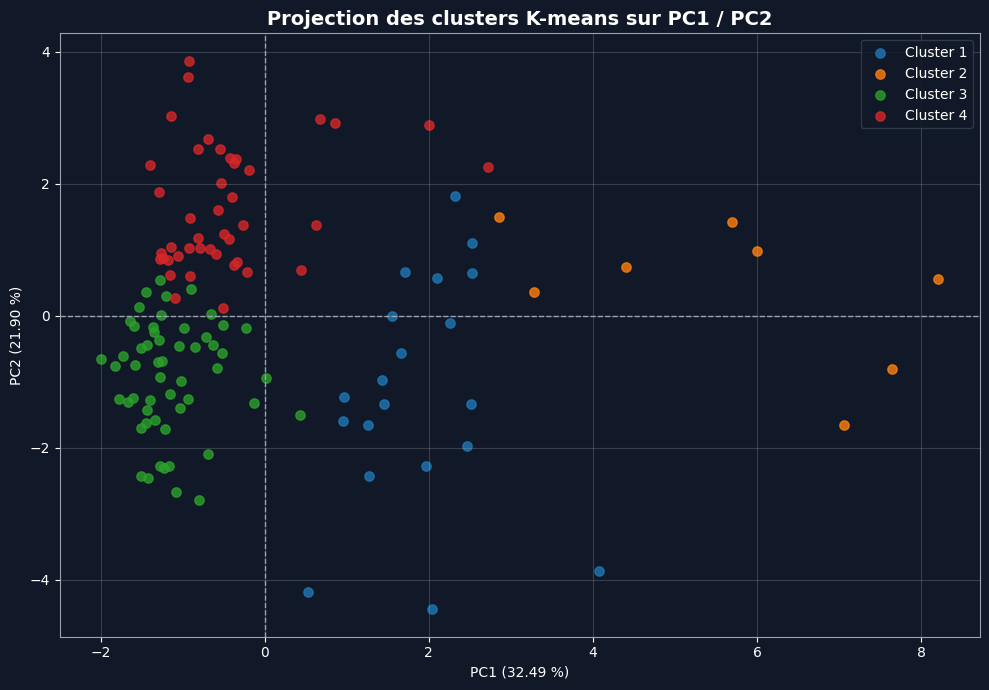

In [94]:
# Visualisation des clusters K-means sur le plan factoriel PC1 / PC2
# Cette projection permet de voir comment les groupes K-means se positionnent sur les deux premiers axes de l'ACP
fig, ax = plt.subplots(figsize=(10, 7))

fig.patch.set_facecolor("#111827")
ax.set_facecolor("#111827")

for cluster in sorted(df_kmeans["cluster_kmeans"].unique()):
    data_cluster = df_kmeans[df_kmeans["cluster_kmeans"] == cluster]
    
    ax.scatter(
        data_cluster["PC1"],
        data_cluster["PC2"],
        label=f"Cluster {cluster}",
        alpha=0.8,
        s=45
    )

ax.axhline(0, color="#9CA3AF", linestyle="--", linewidth=1)
ax.axvline(0, color="#9CA3AF", linestyle="--", linewidth=1)

ax.set_title("Projection des clusters K-means sur PC1 / PC2", color="white", fontsize=14, fontweight="bold")
ax.set_xlabel(f"PC1 ({variance_expliquee[0] * 100:.2f} %)", color="white")
ax.set_ylabel(f"PC2 ({variance_expliquee[1] * 100:.2f} %)", color="white")

ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")

ax.grid(alpha=0.25)

for spine in ax.spines.values():
    spine.set_color("#9CA3AF")

legend = ax.legend(facecolor="#111827", edgecolor="#374151")
for text in legend.get_texts():
    text.set_color("white")

plt.tight_layout()
plt.show()

<div style="max-width:980px; margin:35px auto; padding:24px; border:1px solid #CA8A04; border-radius:14px; background:linear-gradient(135deg, rgba(66, 32, 6, 0.94), rgba(28, 25, 23, 0.96)); color:#fff; box-shadow:0 0 25px rgba(202, 138, 4, 0.25);">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <b style="font-size:19px; color:#FDE68A;">🎯 Étape 6.2 • Modèle K-means retenu</b>
  </div>
  <p style="line-height:1.6;">
    Le modèle K-means final a été entraîné avec <strong>4 clusters</strong>. 
    Chaque pays est affecté au groupe dont le centre est le plus proche dans l’espace des axes ACP retenus.
  </p>
  <div style="display:grid; grid-template-columns:1fr 1fr; gap:12px; margin-top:18px;">
    <div style="padding:4px; border:1px solid #22C55E; border-radius:10px; background:rgba(20, 83, 45, 0.35);">
      <strong style="color:#86EFAC;">✅ Modèle retenu</strong>
      <ul style="margin-bottom:0; line-height:1.6;">
        <li><strong>K-means avec 4 clusters</strong></li>
        <li><strong>125 pays</strong> classés</li>
        <li><strong>4 axes ACP</strong> utilisés</li>
        <li>Résultat stocké dans la colonne <strong>cluster_kmeans</strong></li>
      </ul>
    </div>
    <div style="padding:4px; border:1px solid #38BDF8; border-radius:10px; background:rgba(8, 47, 73, 0.35);">
      <strong style="color:#BAE6FD;">📊 Répartition obtenue</strong>
      <ul style="margin-bottom:0; line-height:1.6;">
        <li>Cluster 1 : <strong>20 pays</strong></li>
        <li>Cluster 2 : <strong>8 pays</strong></li>
        <li>Cluster 3 : <strong>54 pays</strong></li>
        <li>Cluster 4 : <strong>43 pays</strong></li>
      </ul>
    </div>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #F59E0B; border-radius:10px; background:rgba(120, 53, 15, 0.35);">
    <strong style="color:#FDE68A;">📌 Lecture du graphique :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      La projection sur le plan PC1 / PC2 permet de visualiser les groupes formés par K-means. 
      Les pays proches graphiquement ont des profils similaires selon les axes ACP retenus. 
      Les clusters les plus à droite correspondent à des pays plus marqués par les variables liées au volume économique, à la production ou aux échanges.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #A855F7; border-radius:10px; background:rgba(88, 28, 135, 0.28);">
    <strong style="color:#E9D5FF;">🔎 À quoi sert K-means ici ?</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      K-means permet de créer automatiquement des groupes de pays en fonction de leur proximité statistique. 
      Contrairement à la CAH, qui construit une hiérarchie de regroupements, K-means répartit directement les pays autour de centres de clusters.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #22C55E; border-radius:10px; background:rgba(6, 78, 59, 0.35);">
    <strong style="color:#86EFAC;">👉 En clair :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Le K-means confirme l’existence de plusieurs profils de pays. 
      Les groupes obtenus ne sont pas parfaitement équilibrés, mais ils restent exploitables pour comparer les résultats avec la CAH et préparer le profilage métier des clusters.
    </p>
  </div>
</div>

<a id="etape6_3"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(253,230,138,0.28);
  border-radius:12px;
  background:rgba(253,230,138,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(92%) sepia(19%) saturate(938%) hue-rotate(335deg) brightness(102%) contrast(101%);
      ">
    </a>
    <span>6.3 • Comparaison avec la CAH</span>
  </h3>
</div>

In [95]:
# Comparaison entre les clusters CAH et K-means
# Les numéros de clusters ne sont pas directement équivalents entre les deux méthodes
# Cette table permet surtout d'observer les correspondances globales entre les regroupements
comparaison_clusters = df_cah[["Zone", "cluster_cah"]].merge(
    df_kmeans[["Zone", "cluster_kmeans"]],
    on="Zone",
    how="inner"
)

print("✅ Comparaison CAH / K-means créée.")
print("Dimensions du tableau de comparaison :", comparaison_clusters.shape)

display(comparaison_clusters.head())

✅ Comparaison CAH / K-means créée.
Dimensions du tableau de comparaison : (125, 3)


,Zone,cluster_cah,cluster_kmeans
0,Afrique du Sud,4,2
1,Albanie,1,3
2,Algérie,1,3
3,Allemagne,3,2
4,Angola,1,3


In [96]:
# Tableau croisé entre les clusters CAH et K-means
# Ce tableau permet de voir combien de pays sont placés dans chaque combinaison de clusters
table_comparaison = pd.crosstab(
    comparaison_clusters["cluster_cah"],
    comparaison_clusters["cluster_kmeans"]
)

display(table_comparaison)

cluster_kmeans,1,2,3,4
cluster_cah,,,,
1,0,0,40,0
2,0,0,11,39
3,0,6,0,0
4,20,2,3,4


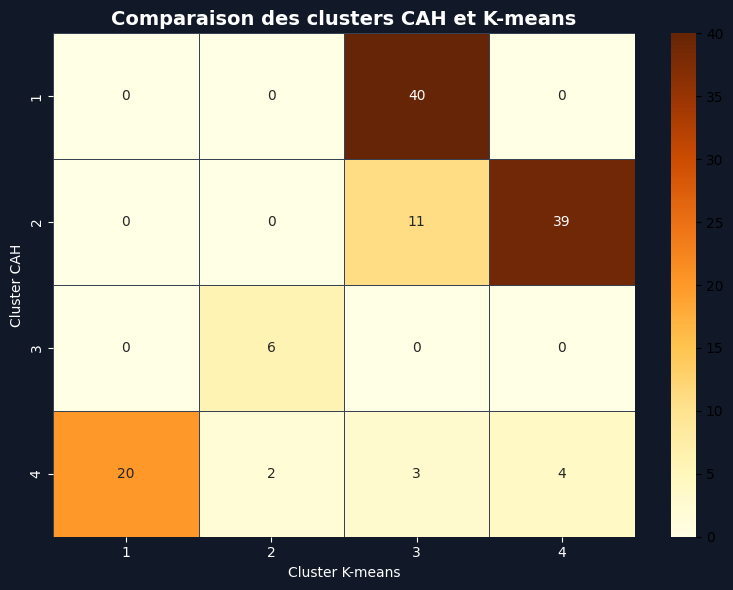

In [100]:
# Visualisation du tableau de correspondance entre CAH et K-means
# Plus une case est élevée, plus les deux méthodes ont regroupé beaucoup de pays ensemble
fig, ax = plt.subplots(figsize=(8, 6))

fig.patch.set_facecolor("#111827")
ax.set_facecolor("#111827")

sns.heatmap(
    table_comparaison,
    annot=True,
    fmt="d",
    cmap="YlOrBr",
    linewidths=0.5,
    linecolor="#374151",
    cbar=True,
    ax=ax
)

ax.set_title("Comparaison des clusters CAH et K-means", color="white", fontsize=14, fontweight="bold")
ax.set_xlabel("Cluster K-means", color="white")
ax.set_ylabel("Cluster CAH", color="white")

ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")

plt.tight_layout()
plt.show()

In [98]:
# Répartition finale des pays par méthode de clustering
# Cette étape permet de comparer le niveau d'équilibre des groupes entre CAH et K-means
repartition_comparaison = pd.DataFrame({
    "cluster_cah": df_cah["cluster_cah"].value_counts().sort_index(),
    "cluster_kmeans": df_kmeans["cluster_kmeans"].value_counts().sort_index()
}).fillna(0).astype(int)

display(repartition_comparaison)

,cluster_cah,cluster_kmeans
1,40,20
2,50,8
3,6,54
4,29,43


<div style="max-width:980px; margin:35px auto; padding:24px; border:1px solid #CA8A04; border-radius:14px; background:linear-gradient(135deg, rgba(66, 32, 6, 0.94), rgba(28, 25, 23, 0.96)); color:#fff; box-shadow:0 0 25px rgba(202, 138, 4, 0.25);">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <b style="font-size:19px; color:#FDE68A;">🎯 Étape 6.3 • Comparaison entre la CAH et le K-means</b>
  </div>
  <p style="line-height:1.6;">
    Les résultats de la CAH et du K-means ont été comparés à l’aide d’un tableau croisé. 
    Cette comparaison permet d’observer si les deux méthodes regroupent les pays de manière proche ou différente.
  </p>
  <div style="display:grid; grid-template-columns:1fr 1fr; gap:12px; margin-top:18px;">
    <div style="padding:4px; border:1px solid #22C55E; border-radius:10px; background:rgba(20, 83, 45, 0.35);">
      <strong style="color:#86EFAC;">✅ Points de cohérence</strong>
      <ul style="margin-bottom:0; line-height:1.6;">
        <li>La CAH cluster 1 correspond fortement au K-means cluster 3 : <strong>40 pays</strong></li>
        <li>La CAH cluster 2 correspond fortement au K-means cluster 4 : <strong>39 pays</strong></li>
        <li>La comparaison confirme des regroupements proches sur plusieurs profils</li>
      </ul>
    </div>
    <div style="padding:4px; border:1px solid #38BDF8; border-radius:10px; background:rgba(8, 47, 73, 0.35);">
      <strong style="color:#BAE6FD;">📊 Différences observées</strong>
      <ul style="margin-bottom:0; line-height:1.6;">
        <li>Les numéros de clusters ne sont pas équivalents entre les méthodes</li>
        <li>Certains groupes CAH sont répartis dans plusieurs clusters K-means</li>
        <li>La CAH conserve davantage une logique hiérarchique</li>
        <li>K-means cherche plutôt des groupes autour de centres</li>
      </ul>
    </div>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #F59E0B; border-radius:10px; background:rgba(120, 53, 15, 0.35);">
    <strong style="color:#FDE68A;">📌 Comment lire la heatmap ?</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Chaque case indique combien de pays sont placés dans une combinaison de clusters CAH et K-means. 
      Plus la valeur est élevée, plus les deux méthodes ont regroupé les mêmes pays ensemble. 
      Les cases fortes montrent donc les correspondances principales entre les deux classifications.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #A855F7; border-radius:10px; background:rgba(88, 28, 135, 0.28);">
    <strong style="color:#E9D5FF;">🔎 Interprétation :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Les deux méthodes ne donnent pas exactement les mêmes clusters, ce qui est normal. 
      La CAH regroupe les pays étape par étape selon une structure hiérarchique, tandis que le K-means optimise directement la position des pays autour de centres de groupes.
      La comparaison permet donc de vérifier si les grandes familles de pays restent globalement cohérentes.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #22C55E; border-radius:10px; background:rgba(6, 78, 59, 0.35);">
    <strong style="color:#86EFAC;">👉 En clair :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      La comparaison montre que la segmentation est globalement cohérente, même si les méthodes ne classent pas tous les pays de la même façon. 
      Cette double approche renforce l’analyse avant de passer au profilage détaillé des clusters.
    </p>
  </div>
</div>

<a id="etape7"></a>
<div style="
  width:78%;
  margin:16px auto 10px auto;
  border:1px solid rgba(249,115,22,0.34);
  border-radius:14px;
  background:linear-gradient(135deg, rgba(88,33,5,0.96), rgba(44,17,4,0.98));
  box-sizing:border-box;
">
  <h2 style="
    margin:0;
    padding:15px 20px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:22px;
    font-weight:750;
    gap:12px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:24px; height:24px; display:block;
        filter: brightness(0) saturate(100%) invert(73%) sepia(59%) saturate(1987%) hue-rotate(352deg) brightness(101%) contrast(99%);
      ">
    </a>
    <span style="color:#FDBA74;">🧩 Étape 7</span>
    <span>• Profilage des clusters</span>
  </h2>
</div>

<a id="etape7_1"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(253,186,116,0.28);
  border-radius:12px;
  background:rgba(253,186,116,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(85%) sepia(17%) saturate(1388%) hue-rotate(334deg) brightness(103%) contrast(102%);
      ">
    </a>
    <span>7.1 • Caractéristiques moyennes par cluster</span>
  </h3>
</div>

In [101]:
# Préparation du dataset de profilage
# On repart du dataset initial retenu, puis on ajoute le cluster K-means
# Cela permet d'interpréter les clusters avec les variables métier originales
df_profiling = df.merge(
    df_kmeans[["Zone", "cluster_kmeans"]],
    on="Zone",
    how="inner"
)

print("✅ Dataset de profilage créé.")
print("Dimensions du dataset :", df_profiling.shape)

display(df_profiling.head())

✅ Dataset de profilage créé.
Dimensions du dataset : (125, 14)


,Zone,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Production,population_2017,PIB_2017,stabilite_politique_2017,taux_dependance_importations,balance_commerciale_quantite,PIB_par_habitant,cluster_kmeans
0,Afrique du Sud,143.00,35.69,2 118.00,63.00,514.00,1 667.00,57 009 756.00,381 448 814 653.46,-0.28,23.57,-451.00,6 690.94,2
1,Albanie,85.00,16.36,47.00,0.00,38.00,13.00,2 884 169.00,13 258 268 435.60,0.37,74.51,-38.00,4 596.91,3
2,Algérie,22.00,6.38,277.00,0.00,2.00,275.00,41 389 189.00,189 880 896 903.07,-0.92,0.72,-2.00,4 587.69,3
3,Allemagne,71.00,19.47,1 739.00,646.00,842.00,1 514.00,82 658 409.00,3 765 351 626 105.89,0.57,35.74,-196.00,45 553.16,2
4,Angola,35.00,10.56,319.00,0.00,277.00,42.00,29 816 766.00,84 376 935 689.34,-0.39,86.83,-277.00,2 829.85,3


In [102]:
# Calcul des moyennes par cluster
# Cette étape permet d'identifier le profil moyen de chaque groupe de pays
variables_profiling = [
    "Disponibilité alimentaire (Kcal/personne/jour)",
    "Disponibilité alimentaire en quantité (kg/personne/an)",
    "Disponibilité intérieure",
    "Exportations - Quantité",
    "Importations - Quantité",
    "Production",
    "population_2017",
    "PIB_2017",
    "stabilite_politique_2017",
    "taux_dependance_importations",
    "balance_commerciale_quantite",
    "PIB_par_habitant"
]

profil_clusters = (
    df_profiling
    .groupby("cluster_kmeans")[variables_profiling]
    .mean()
    .round(2)
)

display(profil_clusters)

,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Production,population_2017,PIB_2017,stabilite_politique_2017,taux_dependance_importations,balance_commerciale_quantite,PIB_par_habitant
cluster_kmeans,,,,,,,,,,,,
1,75.35,20.54,1 351.75,232.45,105.20,1 501.95,82 865 247.45,623 112 810 539.44,-0.61,7.15,127.25,11 973.55
2,108.88,29.42,2 536.12,214.12,703.75,2 158.62,87 768 680.62,2 233 976 436 305.86,-0.01,28.27,-489.62,26 755.70
3,42.11,11.94,141.78,5.43,46.89,107.06,13 403 365.91,50 249 653 060.72,-0.35,35.40,-41.46,4 829.84
4,121.07,32.58,207.42,47.07,59.16,209.42,6 078 486.44,212 624 123 160.97,0.66,35.07,-12.09,29 903.60


In [103]:
# Ajout du nombre de pays par cluster
# Cela permet de compléter le profil moyen avec la taille de chaque groupe
taille_clusters = (
    df_profiling["cluster_kmeans"]
    .value_counts()
    .sort_index()
    .rename("nombre_pays")
)

profil_clusters_complet = profil_clusters.copy()
profil_clusters_complet.insert(0, "nombre_pays", taille_clusters)

display(profil_clusters_complet)

,nombre_pays,Disponibilité alimentaire (Kcal/personne/jour),Disponibilité alimentaire en quantité (kg/personne/an),Disponibilité intérieure,Exportations - Quantité,Importations - Quantité,Production,population_2017,PIB_2017,stabilite_politique_2017,taux_dependance_importations,balance_commerciale_quantite,PIB_par_habitant
cluster_kmeans,,,,,,,,,,,,,
1,20,75.35,20.54,1 351.75,232.45,105.20,1 501.95,82 865 247.45,623 112 810 539.44,-0.61,7.15,127.25,11 973.55
2,8,108.88,29.42,2 536.12,214.12,703.75,2 158.62,87 768 680.62,2 233 976 436 305.86,-0.01,28.27,-489.62,26 755.70
3,54,42.11,11.94,141.78,5.43,46.89,107.06,13 403 365.91,50 249 653 060.72,-0.35,35.40,-41.46,4 829.84
4,43,121.07,32.58,207.42,47.07,59.16,209.42,6 078 486.44,212 624 123 160.97,0.66,35.07,-12.09,29 903.60


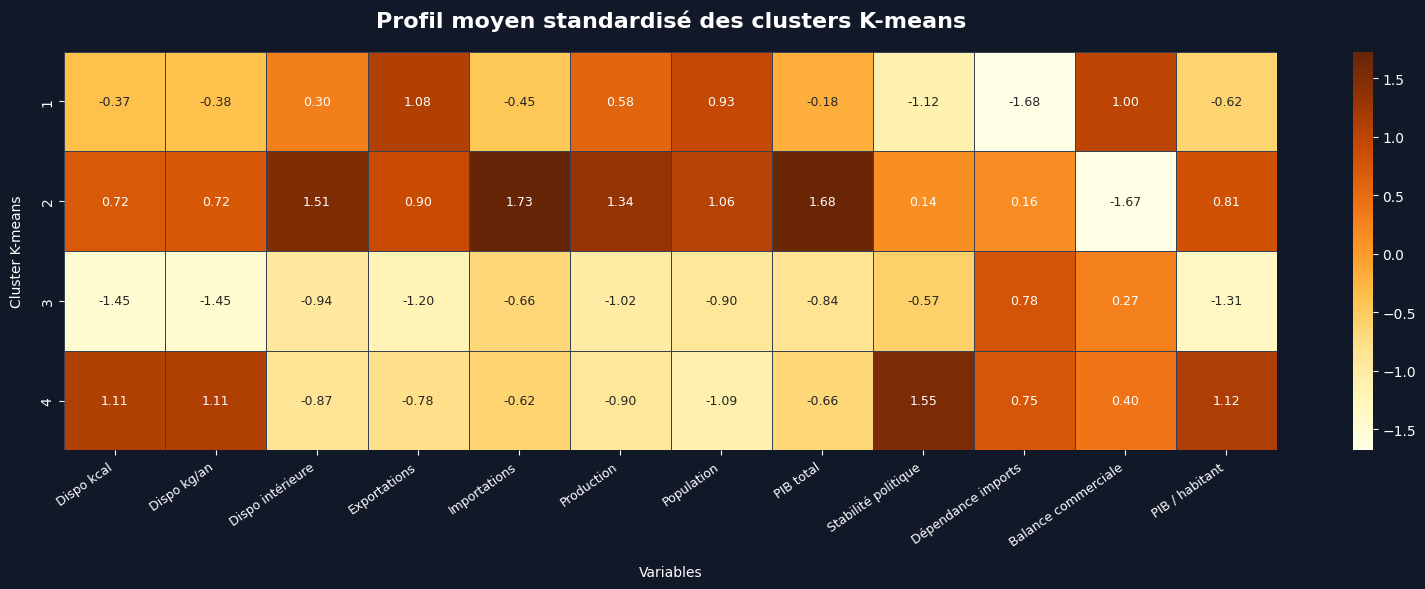

In [116]:
# Standardisation des profils moyens par cluster
# On standardise les moyennes pour comparer les clusters malgré les différences d'échelle entre variables.

from sklearn.preprocessing import StandardScaler

profil_clusters_standardise = pd.DataFrame(
    StandardScaler().fit_transform(profil_clusters),
    index=profil_clusters.index,
    columns=profil_clusters.columns
)

# Noms courts uniquement pour l'affichage du graphique
labels_courts_profil = {
    "Disponibilité alimentaire (Kcal/personne/jour)": "Dispo kcal",
    "Disponibilité alimentaire en quantité (kg/personne/an)": "Dispo kg/an",
    "Disponibilité intérieure": "Dispo intérieure",
    "Exportations - Quantité": "Exportations",
    "Importations - Quantité": "Importations",
    "Production": "Production",
    "population_2017": "Population",
    "PIB_2017": "PIB total",
    "stabilite_politique_2017": "Stabilité politique",
    "taux_dependance_importations": "Dépendance imports",
    "balance_commerciale_quantite": "Balance commerciale",
    "PIB_par_habitant": "PIB / habitant"
}

profil_clusters_standardise_affichage = profil_clusters_standardise.rename(
    columns=labels_courts_profil
)

fig, ax = plt.subplots(figsize=(16, 6))

fig.patch.set_facecolor("#111827")
ax.set_facecolor("#111827")

sns.heatmap(
    profil_clusters_standardise_affichage,
    annot=True,
    fmt=".2f",
    cmap="YlOrBr",
    linewidths=0.6,
    linecolor="#374151",
    cbar=True,
    ax=ax,
    annot_kws={"size": 9}
)

ax.set_title(
    "Profil moyen standardisé des clusters K-means",
    color="white",
    fontsize=16,
    fontweight="bold",
    pad=18
)

ax.set_xlabel("Variables", color="white", labelpad=12)
ax.set_ylabel("Cluster K-means", color="white", labelpad=12)

ax.tick_params(axis="x", colors="white", rotation=35, labelsize=9)
ax.tick_params(axis="y", colors="white", labelsize=10)

for label in ax.get_xticklabels():
    label.set_horizontalalignment("right")

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(colors="white")
cbar.outline.set_edgecolor("#9CA3AF")

for spine in ax.spines.values():
    spine.set_color("#9CA3AF")

plt.tight_layout()
plt.show()

<div style="max-width: 1050px; margin: 35px auto; padding: 24px; border: 1px solid #F97316; border-radius: 14px; background: linear-gradient(135deg, rgba(67, 20, 7, 0.94), rgba(30, 20, 15, 0.97)); color: #fff; box-shadow: 0 0 25px rgba(249, 115, 22, 0.22);">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <b style="font-size:19px; color:#FDBA74;">🧩 Étape 7.1 • Caractéristiques moyennes par cluster</b>
  </div>
  <p style="line-height:1.6;">
    Cette étape permet de traduire les clusters K-means en profils métiers compréhensibles. 
    Après avoir regroupé les pays à partir des axes ACP, les clusters sont réassociés aux variables initiales afin d’analyser leurs caractéristiques réelles :
    disponibilité alimentaire, dépendance aux importations, niveau économique, stabilité politique et volumes commerciaux.
  </p>
  <div style="display:grid; grid-template-columns: 1fr 1fr; gap:12px; margin-top:18px;">
    <div style="padding:4px; border:1px solid #22C55E; border-radius:10px; background:rgba(20, 83, 45, 0.35);">
      <strong style="color:#86EFAC;">✅ Données utilisées</strong>
      <ul style="margin-bottom:0; line-height:1.6;">
        <li><strong>125 pays</strong> conservés dans l’analyse</li>
        <li><strong>4 clusters K-means</strong> identifiés</li>
        <li>Variables métiers originales réutilisées pour l’interprétation</li>
        <li>Ajout du nombre de pays par cluster</li>
      </ul>
    </div>
    <div style="padding:4px; border:1px solid #38BDF8; border-radius:10px; background:rgba(8, 47, 73, 0.35);">
      <strong style="color:#BAE6FD;">📊 Lecture de la heatmap</strong>
      <ul style="margin-bottom:0; line-height:1.6;">
        <li>Les valeurs positives indiquent un niveau supérieur à la moyenne</li>
        <li>Les valeurs négatives indiquent un niveau inférieur à la moyenne</li>
        <li>La standardisation facilite la comparaison entre variables</li>
        <li>Chaque ligne représente le profil moyen d’un cluster</li>
      </ul>
    </div>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #F59E0B; border-radius:10px; background:rgba(120, 53, 15, 0.35);">
    <strong style="color:#FDE68A;">📌 Lecture des profils observés :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Le <strong>cluster 2</strong> ressort comme un groupe de pays à forte disponibilité intérieure, forte production, forts volumes d’importations et PIB élevé.
      Le <strong>cluster 4</strong> présente un profil plus favorable en termes de stabilité politique, PIB par habitant et disponibilité alimentaire, avec une dépendance aux importations plutôt élevée.
      À l’inverse, le <strong>cluster 3</strong> regroupe des pays plus faibles sur la plupart des indicateurs économiques et alimentaires.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #A855F7; border-radius:10px; background:rgba(88, 28, 135, 0.28);">
    <strong style="color:#E9D5FF;">🔎 Pourquoi standardiser les profils ?</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Les variables n’ont pas les mêmes unités : population, PIB, disponibilité alimentaire ou taux d’importation ne sont pas directement comparables.
      La standardisation permet donc de lire les écarts à la moyenne sur une même échelle et de mieux identifier les forces et faiblesses de chaque cluster.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #22C55E; border-radius:10px; background:rgba(6, 78, 59, 0.35);">
    <strong style="color:#86EFAC;">👉 En clair :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Cette étape transforme les groupes statistiques en profils interprétables. On ne se contente plus de dire que les pays sont regroupés :
      on commence à comprendre <strong>pourquoi</strong> ils le sont et quel type de marché chaque cluster représente.
    </p>
  </div>
</div>

<a id="etape7_2"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(253,186,116,0.28);
  border-radius:12px;
  background:rgba(253,186,116,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(85%) sepia(17%) saturate(1388%) hue-rotate(334deg) brightness(103%) contrast(102%);
      ">
    </a>
    <span>7.2 • Pays représentatifs de chaque groupe</span>
  </h3>
</div>

In [105]:
# Calcul des centres des clusters K-means
# Les centres représentent le profil moyen de chaque cluster dans l'espace ACP
centres_kmeans = pd.DataFrame(
    kmeans_final.cluster_centers_,
    columns=axes_retenus
)

display(centres_kmeans)

,PC1,PC2,PC3,PC4
0,1.88,-1.16,1.32,0.40
1,5.64,0.39,-1.62,-0.67
2,-1.15,-0.92,-0.33,-0.24
3,-0.49,1.63,0.10,0.24


In [106]:
# Identification des pays les plus représentatifs de chaque cluster
# Un pays représentatif est proche du centre de son cluster
df_representatifs = df_kmeans.copy()

for cluster in sorted(df_representatifs["cluster_kmeans"].unique()):
    centre = centres_kmeans.loc[cluster - 1, axes_retenus].values
    
    masque_cluster = df_representatifs["cluster_kmeans"] == cluster
    
    distances = np.linalg.norm(
        df_representatifs.loc[masque_cluster, axes_retenus].values - centre,
        axis=1
    )
    
    df_representatifs.loc[masque_cluster, "distance_centre_cluster"] = distances

pays_representatifs = (
    df_representatifs
    .sort_values(["cluster_kmeans", "distance_centre_cluster"])
    .groupby("cluster_kmeans")
    .head(5)
)

display(
    pays_representatifs[
        ["Zone", "cluster_kmeans", "PC1", "PC2", "PC3", "PC4", "distance_centre_cluster"]
    ]
)

,Zone,cluster_kmeans,PC1,PC2,PC3,PC4,distance_centre_cluster
115,Ukraine,1,0.96,-1.59,1.37,0.95,1.16
91,Pérou,1,0.96,-1.23,0.22,0.68,1.46
49,Iran (République islamique d'),1,2.52,-1.34,0.89,1.89,1.69
54,Italie,1,2.26,-0.11,1.02,-0.92,1.76
25,Colombie,1,1.66,-0.56,0.20,1.87,1.96
93,Royaume-Uni de Grande-Bretagne et d'Irlande du...,2,5.70,1.42,-1.17,-1.57,1.45
0,Afrique du Sud,2,3.28,0.37,-1.57,1.37,3.12
38,France,2,4.40,0.73,0.93,-2.02,3.16
3,Allemagne,2,6.00,0.98,-0.04,-3.79,3.57
6,Arabie saoudite,2,2.86,1.49,-3.33,0.58,3.67


In [107]:
# Affichage des pays les plus représentatifs par cluster
for cluster in sorted(df_representatifs["cluster_kmeans"].unique()):
    print(f"\nPays les plus représentatifs du cluster {cluster} :")
    
    display(
        df_representatifs[df_representatifs["cluster_kmeans"] == cluster]
        .sort_values("distance_centre_cluster")
        [["Zone", "cluster_kmeans", "PC1", "PC2", "PC3", "PC4", "distance_centre_cluster"]]
        .head(8)
    )


Pays les plus représentatifs du cluster 1 :


,Zone,cluster_kmeans,PC1,PC2,PC3,PC4,distance_centre_cluster
115,Ukraine,1,0.96,-1.59,1.37,0.95,1.16
91,Pérou,1,0.96,-1.23,0.22,0.68,1.46
49,Iran (République islamique d'),1,2.52,-1.34,0.89,1.89,1.69
54,Italie,1,2.26,-0.11,1.02,-0.92,1.76
25,Colombie,1,1.66,-0.56,0.20,1.87,1.96
114,Turquie,1,2.47,-1.97,3.06,0.67,2.03
33,Espagne,1,2.53,0.64,0.78,-0.01,2.03
75,Myanmar,1,1.43,-0.97,0.58,2.32,2.11



Pays les plus représentatifs du cluster 2 :


,Zone,cluster_kmeans,PC1,PC2,PC3,PC4,distance_centre_cluster
93,Royaume-Uni de Grande-Bretagne et d'Irlande du...,2,5.70,1.42,-1.17,-1.57,1.45
0,Afrique du Sud,2,3.28,0.37,-1.57,1.37,3.12
38,France,2,4.40,0.73,0.93,-2.02,3.16
3,Allemagne,2,6.00,0.98,-0.04,-3.79,3.57
6,Arabie saoudite,2,2.86,1.49,-3.33,0.58,3.67
73,Mexique,2,7.65,-0.81,-3.74,1.21,3.67
39,Fédération de Russie,2,7.06,-1.65,0.64,2.01,4.29
56,Japon,2,8.21,0.56,-4.67,-3.11,4.68



Pays les plus représentatifs du cluster 3 :


,Zone,cluster_kmeans,PC1,PC2,PC3,PC4,distance_centre_cluster
99,Serbie,3,-1.27,-0.93,0.11,-0.27,0.45
11,Azerbaïdjan,3,-1.15,-1.18,-0.12,0.11,0.48
96,République de Moldova,3,-1.30,-0.71,-0.08,0.18,0.56
35,Eswatini,3,-1.60,-1.25,-0.08,-0.49,0.66
16,Bosnie-Herzégovine,3,-1.25,-0.69,0.11,0.23,0.69
45,Géorgie,3,-1.43,-0.45,-0.75,-0.37,0.71
8,Arménie,3,-1.50,-0.49,-0.78,-0.27,0.72
86,Paraguay,3,-1.40,-1.28,0.23,-0.41,0.73



Pays les plus représentatifs du cluster 4 :


,Zone,cluster_kmeans,PC1,PC2,PC3,PC4,distance_centre_cluster
90,Portugal,4,-0.27,1.37,0.17,0.26,0.35
66,Lituanie,4,-0.92,1.03,0.30,0.15,0.77
102,Slovénie,4,-1.06,0.91,0.25,-0.10,0.99
81,Nouvelle-Zélande,4,-0.42,2.40,0.73,0.37,1.01
85,Panama,4,-0.67,1.01,0.25,1.00,1.01
72,Maurice,4,-0.91,1.49,0.38,1.16,1.06
24,Chypre,4,-1.18,0.84,-0.07,0.10,1.07
109,Tchéquie,4,-0.59,0.93,-0.43,-0.48,1.13


<div style="max-width: 1050px; margin: 35px auto; padding: 24px; border: 1px solid #F97316; border-radius: 14px; background: linear-gradient(135deg, rgba(67, 20, 7, 0.94), rgba(28, 20, 16, 0.97)); color: #fff; box-shadow: 0 0 25px rgba(249, 115, 22, 0.22);">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <b style="font-size:19px; color:#FDBA74;">🌍 Étape 7.2 • Pays représentatifs de chaque groupe</b>
  </div>
  <p style="line-height:1.6;">
    Cette étape permet d’identifier, pour chaque cluster, les pays les plus proches du centre du groupe.
    Ces pays sont considérés comme représentatifs car leur profil est proche du profil moyen du cluster dans l’espace ACP.
  </p>
  <div style="display:grid; grid-template-columns: 1fr 1fr; gap:12px; margin-top:18px;">
    <div style="padding:4px; border:1px solid #22C55E; border-radius:10px; background:rgba(20, 83, 45, 0.35);">
      <strong style="color:#86EFAC;">✅ Méthode utilisée</strong>
      <ul style="margin-bottom:0; line-height:1.6;">
        <li>Calcul du centre moyen de chaque cluster</li>
        <li>Mesure de la distance entre chaque pays et son centre de cluster</li>
        <li>Classement des pays par proximité avec ce centre</li>
        <li>Sélection des pays les plus représentatifs</li>
      </ul>
    </div>
    <div style="padding:4px; border:1px solid #38BDF8; border-radius:10px; background:rgba(8, 47, 73, 0.35);">
      <strong style="color:#BAE6FD;">📌 Exemples de pays représentatifs</strong>
      <ul style="margin-bottom:0; line-height:1.6;">
        <li><strong>Cluster 1 :</strong> Ukraine, Pérou, Iran, Italie, Colombie</li>
        <li><strong>Cluster 2 :</strong> Royaume-Uni, Afrique du Sud, France, Allemagne, Japon</li>
        <li><strong>Cluster 3 :</strong> Serbie, Azerbaïdjan, Moldavie, Eswatini</li>
        <li><strong>Cluster 4 :</strong> Portugal, Lituanie, Slovénie, Nouvelle-Zélande</li>
      </ul>
    </div>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #F59E0B; border-radius:10px; background:rgba(120, 53, 15, 0.35);">
    <strong style="color:#FDE68A;">📌 Interprétation :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Les pays représentatifs ne sont pas forcément les meilleurs marchés. Ils servent surtout à illustrer le profil moyen du groupe.
      Par exemple, si plusieurs pays représentatifs d’un cluster partagent des niveaux proches de dépendance aux importations, de PIB ou de stabilité,
      cela aide à comprendre la logique économique du groupe.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #A855F7; border-radius:10px; background:rgba(88, 28, 135, 0.28);">
    <strong style="color:#E9D5FF;">🔎 Pourquoi cette étape est utile ?</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Les clusters peuvent parfois rester abstraits. En affichant des pays concrets proches du centre de chaque groupe,
      on rend l’analyse plus lisible pour un décideur : chaque cluster devient plus facile à nommer, expliquer et comparer.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #22C55E; border-radius:10px; background:rgba(6, 78, 59, 0.35);">
    <strong style="color:#86EFAC;">👉 En clair :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Cette étape donne des exemples concrets pour chaque groupe. Elle prépare la phase de recommandation en permettant de relier les résultats statistiques
      à des pays réels et à des profils de marché facilement compréhensibles.
    </p>
  </div>
</div>

<a id="etape7_3"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(253,186,116,0.28);
  border-radius:12px;
  background:rgba(253,186,116,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(85%) sepia(17%) saturate(1388%) hue-rotate(334deg) brightness(103%) contrast(102%);
      ">
    </a>
    <span>7.3 • Identification des clusters les plus attractifs</span>
  </h3>
</div>

In [ ]:
# Création d'un score d'attractivité business par pays
# L'objectif est d'identifier les clusters potentiellement intéressants pour l'exportation de poulets
# On privilégie les pays dépendants aux importations, stables politiquement et avec un niveau économique favorable

variables_score = [
    "taux_dependance_importations",
    "PIB_par_habitant",
    "stabilite_politique_2017",
    "Importations - Quantité",
    "Disponibilité alimentaire en quantité (kg/personne/an)"
]

df_score = df_profiling[["Zone", "cluster_kmeans"] + variables_score].copy()

scaler_score = StandardScaler()

df_score_standardise = pd.DataFrame(
    scaler_score.fit_transform(df_score[variables_score]),
    columns=variables_score,
    index=df_score.index
)

df_score["score_attractivite"] = (
    df_score_standardise["taux_dependance_importations"] * 0.30
    + df_score_standardise["PIB_par_habitant"] * 0.25
    + df_score_standardise["stabilite_politique_2017"] * 0.20
    + df_score_standardise["Importations - Quantité"] * 0.15
    + df_score_standardise["Disponibilité alimentaire en quantité (kg/personne/an)"] * 0.10
)

df_score["score_attractivite"] = df_score["score_attractivite"].round(2)

display(df_score.sort_values("score_attractivite", ascending=False).head(20))

,Zone,cluster_kmeans,taux_dependance_importations,PIB_par_habitant,stabilite_politique_2017,Importations - Quantité,Disponibilité alimentaire en quantité (kg/personne/an),score_attractivite
67,Luxembourg,4,100.00,111 017.18,1.31,11.00,18.33,2.07
122,Émirats arabes unis,4,90.02,42 516.75,0.60,433.00,43.47,1.47
56,Japon,2,32.55,38 672.41,1.10,1 069.00,18.50,1.28
51,Irlande,4,47.37,73 287.35,0.99,99.00,25.82,1.14
3,Allemagne,2,35.74,45 553.16,0.57,842.00,19.47,1.11
104,Suisse,4,35.92,82 215.82,1.24,51.00,15.72,1.09
87,Pays-Bas,1,35.60,49 833.51,0.91,608.00,20.33,1.07
98,Samoa,4,100.00,4 529.49,1.16,17.00,64.77,1.06
5,Antigua-et-Barbuda,4,100.00,16 084.25,0.73,7.00,54.10,1.02
93,Royaume-Uni de Grande-Bretagne et d'Irlande du...,2,30.04,40 449.89,0.38,779.00,31.94,0.99


In [109]:
# Score moyen d'attractivité par cluster
# Cette étape permet de classer les clusters selon leur intérêt potentiel pour l'entreprise
attractivite_clusters = (
    df_score
    .groupby("cluster_kmeans")
    .agg(
        nombre_pays=("Zone", "count"),
        score_moyen_attractivite=("score_attractivite", "mean"),
        score_median_attractivite=("score_attractivite", "median"),
        meilleur_score=("score_attractivite", "max")
    )
    .round(2)
    .sort_values("score_moyen_attractivite", ascending=False)
)

display(attractivite_clusters)

,nombre_pays,score_moyen_attractivite,score_median_attractivite,meilleur_score
cluster_kmeans,,,,
2,8,0.64,0.70,1.28
4,43,0.42,0.35,2.07
3,54,-0.28,-0.36,0.38
1,20,-0.42,-0.52,1.07


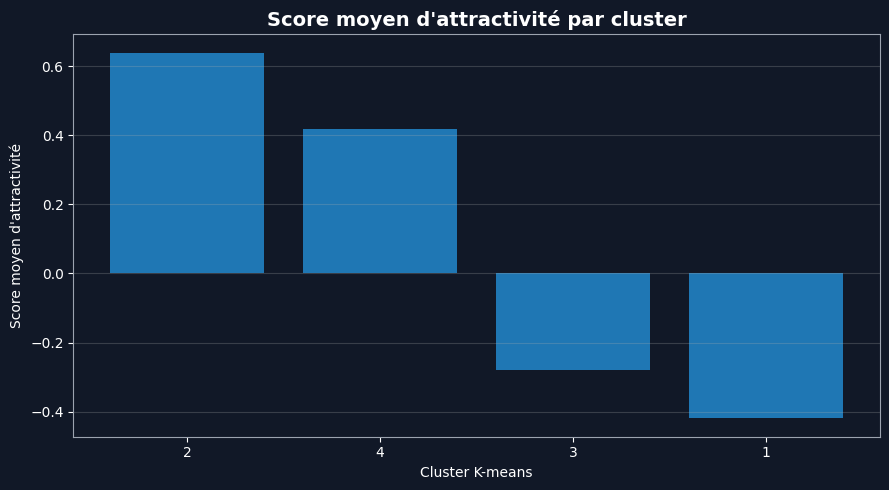

In [110]:
# Visualisation du score moyen d'attractivité par cluster
fig, ax = plt.subplots(figsize=(9, 5))

fig.patch.set_facecolor("#111827")
ax.set_facecolor("#111827")

ax.bar(
    attractivite_clusters.index.astype(str),
    attractivite_clusters["score_moyen_attractivite"]
)

ax.set_title("Score moyen d'attractivité par cluster", color="white", fontsize=14, fontweight="bold")
ax.set_xlabel("Cluster K-means", color="white")
ax.set_ylabel("Score moyen d'attractivité", color="white")

ax.tick_params(axis="x", colors="white")
ax.tick_params(axis="y", colors="white")

ax.grid(axis="y", alpha=0.25)

for spine in ax.spines.values():
    spine.set_color("#9CA3AF")

plt.tight_layout()
plt.show()

In [111]:
# Pays les plus attractifs par cluster
# Cela permet d'identifier des exemples concrets de pays à analyser ensuite dans les recommandations
for cluster in sorted(df_score["cluster_kmeans"].unique()):
    print(f"\nPays les plus attractifs du cluster {cluster} :")
    
    display(
        df_score[df_score["cluster_kmeans"] == cluster]
        .sort_values("score_attractivite", ascending=False)
        .head(8)
    )


Pays les plus attractifs du cluster 1 :


,Zone,cluster_kmeans,taux_dependance_importations,PIB_par_habitant,stabilite_politique_2017,Importations - Quantité,Disponibilité alimentaire en quantité (kg/personne/an),score_attractivite
87,Pays-Bas,1,35.60,49 833.51,0.91,608.00,20.33,1.07
33,Espagne,1,11.92,28 334.98,0.27,205.00,30.39,0.19
95,République de Corée,1,14.05,33 470.00,0.38,137.00,16.70,0.14
54,Italie,1,6.87,32 480.64,0.29,97.00,18.88,0.03
118,Viet Nam,1,24.07,2 974.12,0.21,291.00,12.33,-0.09
89,Pologne,1,2.29,13 921.28,0.51,55.00,30.30,-0.15
7,Argentine,1,0.37,14 648.85,0.16,8.00,42.24,-0.19
69,Malaisie,1,3.79,10 259.21,0.11,68.00,39.21,-0.20



Pays les plus attractifs du cluster 2 :


,Zone,cluster_kmeans,taux_dependance_importations,PIB_par_habitant,stabilite_politique_2017,Importations - Quantité,Disponibilité alimentaire en quantité (kg/personne/an),score_attractivite
56,Japon,2,32.55,38 672.41,1.10,1 069.00,18.50,1.28
3,Allemagne,2,35.74,45 553.16,0.57,842.00,19.47,1.11
93,Royaume-Uni de Grande-Bretagne et d'Irlande du...,2,30.04,40 449.89,0.38,779.00,31.94,0.99
6,Arabie saoudite,2,53.96,22 393.95,-0.65,722.00,43.36,0.80
38,France,2,22.43,39 925.48,0.27,506.00,22.90,0.61
73,Mexique,2,23.03,9 542.77,-0.81,972.00,32.52,0.42
0,Afrique du Sud,2,23.57,6 690.94,-0.28,514.00,35.69,0.18
39,Fédération de Russie,2,4.84,10 817.00,-0.64,226.00,30.98,-0.29



Pays les plus attractifs du cluster 3 :


,Zone,cluster_kmeans,taux_dependance_importations,PIB_par_habitant,stabilite_politique_2017,Importations - Quantité,Disponibilité alimentaire en quantité (kg/personne/an),score_attractivite
68,Macédoine du Nord,3,95.24,5 430.88,-0.26,40.00,19.73,0.38
4,Angola,3,86.83,2 829.85,-0.39,277.00,10.56,0.35
124,Îles Salomon,3,100.00,2 310.85,0.19,6.00,4.45,0.35
20,Bénin,3,87.23,1 136.59,0.03,123.00,14.40,0.34
26,Congo,3,93.69,2 315.63,-0.53,104.00,21.53,0.33
101,Slovaquie,3,47.01,17 617.45,0.90,63.00,13.90,0.31
63,Lettonie,3,56.58,15 063.86,0.45,43.00,20.89,0.30
1,Albanie,3,74.51,4 596.91,0.37,38.00,16.36,0.29



Pays les plus attractifs du cluster 4 :


,Zone,cluster_kmeans,taux_dependance_importations,PIB_par_habitant,stabilite_politique_2017,Importations - Quantité,Disponibilité alimentaire en quantité (kg/personne/an),score_attractivite
67,Luxembourg,4,100.00,111 017.18,1.31,11.00,18.33,2.07
122,Émirats arabes unis,4,90.02,42 516.75,0.60,433.00,43.47,1.47
51,Irlande,4,47.37,73 287.35,0.99,99.00,25.82,1.14
104,Suisse,4,35.92,82 215.82,1.24,51.00,15.72,1.09
98,Samoa,4,100.00,4 529.49,1.16,17.00,64.77,1.06
5,Antigua-et-Barbuda,4,100.00,16 084.25,0.73,7.00,54.10,1.02
30,Danemark,4,43.46,57 849.75,0.85,133.00,28.98,0.93
52,Islande,4,16.67,74 942.02,1.34,2.00,29.95,0.90


<div style="max-width: 1050px; margin: 35px auto; padding: 24px; border: 1px solid #F97316; border-radius: 14px; background: linear-gradient(135deg, rgba(67, 20, 7, 0.94), rgba(30, 20, 15, 0.97)); color: #fff; box-shadow: 0 0 25px rgba(249, 115, 22, 0.22);">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <b style="font-size:19px; color:#FDBA74;">🎯 Étape 7.3 • Identification des clusters les plus attractifs</b>
  </div>
  <p style="line-height:1.6;">
    Un score d’attractivité a été construit afin d’identifier les groupes de pays les plus intéressants pour une stratégie d’exportation de viande de volaille.
    Ce score combine plusieurs critères : dépendance aux importations, PIB par habitant, stabilité politique, volumes d’importations et disponibilité alimentaire.
  </p>
  <div style="display:grid; grid-template-columns: 1fr 1fr; gap:12px; margin-top:18px;">
    <div style="padding:4px; border:1px solid #22C55E; border-radius:10px; background:rgba(20, 83, 45, 0.35);">
      <strong style="color:#86EFAC;">✅ Critères du score</strong>
      <ul style="margin-bottom:0; line-height:1.6;">
        <li><strong>30 %</strong> : dépendance aux importations</li>
        <li><strong>25 %</strong> : PIB par habitant</li>
        <li><strong>20 %</strong> : stabilité politique</li>
        <li><strong>15 %</strong> : volume d’importations</li>
        <li><strong>10 %</strong> : disponibilité alimentaire en quantité</li>
      </ul>
    </div>
    <div style="padding:4px; border:1px solid #38BDF8; border-radius:10px; background:rgba(8, 47, 73, 0.35);">
      <strong style="color:#BAE6FD;">📊 Résultat par cluster</strong>
      <ul style="margin-bottom:0; line-height:1.6;">
        <li><strong>Cluster 2 :</strong> score moyen le plus élevé : <strong>0,64</strong></li>
        <li><strong>Cluster 4 :</strong> second profil attractif : <strong>0,42</strong></li>
        <li><strong>Cluster 3 :</strong> attractivité moyenne négative : <strong>-0,28</strong></li>
        <li><strong>Cluster 1 :</strong> attractivité moyenne la plus faible : <strong>-0,42</strong></li>
      </ul>
    </div>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #F59E0B; border-radius:10px; background:rgba(120, 53, 15, 0.35);">
    <strong style="color:#FDE68A;">📌 Lecture business :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Le <strong>cluster 2</strong> apparaît comme le groupe le plus attractif en moyenne. Il regroupe peu de pays mais avec des profils forts,
      notamment le Japon, l’Allemagne, le Royaume-Uni, l’Arabie saoudite et la France. Ces pays combinent un niveau économique solide,
      des importations importantes et une demande potentielle structurée.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #A855F7; border-radius:10px; background:rgba(88, 28, 135, 0.28);">
    <strong style="color:#E9D5FF;">🔎 Analyse complémentaire :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Le <strong>cluster 4</strong> reste également intéressant : il contient davantage de pays et affiche le meilleur score individuel avec le Luxembourg.
      Il peut donc constituer une cible secondaire pertinente, notamment pour des marchés stables, solvables et parfois fortement dépendants des importations.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #22C55E; border-radius:10px; background:rgba(6, 78, 59, 0.35);">
    <strong style="color:#86EFAC;">👉 En clair :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Les clusters les plus prometteurs sont le <strong>cluster 2</strong>, en priorité, puis le <strong>cluster 4</strong>.
      Le premier semble plus stratégique pour des marchés puissants et déjà importateurs, tandis que le second offre un vivier plus large de pays économiquement favorables.
    </p>
  </div>
</div>

<div style="max-width: 1050px; margin: 40px auto; padding: 24px; border: 1px solid #FB923C; border-radius: 14px; background: linear-gradient(135deg, rgba(88, 28, 12, 0.96), rgba(24, 18, 14, 0.98)); color: #fff; box-shadow: 0 0 28px rgba(251, 146, 60, 0.25);">
  <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
    <b style="font-size:20px; color:#FDBA74;">✅ Synthèse • Profilage des clusters</b>
  </div>
  <p style="line-height:1.6;">
    Le profilage des clusters permet de passer d’un résultat statistique à une lecture directement exploitable pour la prise de décision.
    Les groupes de pays ont été décrits à partir de leurs caractéristiques moyennes, de pays représentatifs et d’un score d’attractivité business.
  </p>
  <div style="display:grid; grid-template-columns: 1fr 1fr; gap:12px; margin-top:18px;">
    <div style="padding:4px; border:1px solid #22C55E; border-radius:10px; background:rgba(20, 83, 45, 0.35);">
      <strong style="color:#86EFAC;">🏆 Cluster prioritaire</strong>
      <p style="margin-bottom:0; line-height:1.6;">
        Le <strong>cluster 2</strong> ressort comme le groupe le plus attractif, avec le meilleur score moyen.
        Il contient des pays économiquement solides et fortement structurés comme le Japon, l’Allemagne, le Royaume-Uni ou l’Arabie saoudite.
      </p>
    </div>
    <div style="padding:4px; border:1px solid #38BDF8; border-radius:10px; background:rgba(8, 47, 73, 0.35);">
      <strong style="color:#BAE6FD;">🥈 Cluster secondaire</strong>
      <p style="margin-bottom:0; line-height:1.6;">
        Le <strong>cluster 4</strong> constitue une cible secondaire intéressante.
        Il rassemble davantage de pays et présente des indicateurs favorables en matière de stabilité, de PIB par habitant et de dépendance aux importations.
      </p>
    </div>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #F59E0B; border-radius:10px; background:rgba(120, 53, 15, 0.35);">
    <strong style="color:#FDE68A;">📌 Conclusion intermédiaire :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      Pour la suite de l’analyse, les recommandations devront donc se concentrer en priorité sur les pays du cluster 2,
      tout en gardant le cluster 4 comme groupe complémentaire à fort potentiel selon les critères business retenus.
    </p>
  </div>
  <div style="margin-top:14px; padding:7px; border:1px solid #22C55E; border-radius:10px; background:rgba(6, 78, 59, 0.35);">
    <strong style="color:#86EFAC;">👉 En clair :</strong>
    <p style="margin-bottom:0; line-height:1.6;">
      L’étape 7 transforme les clusters en groupes de décision. Elle prépare directement l’étape 8, qui consistera à formuler des recommandations concrètes pour le COMEX.
    </p>
  </div>
</div>

<a id="etape8"></a>
<div style="
  width:78%;
  margin:16px auto 10px auto;
  border:1px solid rgba(132,204,22,0.34);
  border-radius:14px;
  background:linear-gradient(135deg, rgba(45,78,8,0.96), rgba(22,38,5,0.98));
  box-sizing:border-box;
">
  <h2 style="
    margin:0;
    padding:15px 20px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:22px;
    font-weight:750;
    gap:12px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:24px; height:24px; display:block;
        filter: brightness(0) saturate(100%) invert(83%) sepia(41%) saturate(1082%) hue-rotate(42deg) brightness(102%) contrast(101%);
      ">
    </a>
    <span style="color:#BEF264;">📣 Étape 8</span>
    <span>• Recommandations pour le COMEX</span>
  </h2>
</div>

<a id="etape8_1"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(190,242,100,0.28);
  border-radius:12px;
  background:rgba(190,242,100,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(90%) sepia(35%) saturate(1036%) hue-rotate(33deg) brightness(102%) contrast(101%);
      ">
    </a>
    <span>8.1 • Synthèse non technique des résultats</span>
  </h3>
</div>

<a id="etape8_2"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(190,242,100,0.28);
  border-radius:12px;
  background:rgba(190,242,100,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(90%) sepia(35%) saturate(1036%) hue-rotate(33deg) brightness(102%) contrast(101%);
      ">
    </a>
    <span>8.2 • Groupes de pays à prioriser</span>
  </h3>
</div>

<a id="etape8_3"></a>
<div style="
  width:78%;
  margin:8px auto 10px auto;
  border:1px solid rgba(190,242,100,0.28);
  border-radius:12px;
  background:rgba(190,242,100,0.05);
  box-sizing:border-box;
">
  <h3 style="
    margin:0;
    padding:12px 18px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:18px;
    font-weight:700;
    gap:10px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:22px; height:22px; display:block;
        filter: brightness(0) saturate(100%) invert(90%) sepia(35%) saturate(1036%) hue-rotate(33deg) brightness(102%) contrast(101%);
      ">
    </a>
    <span>8.3 • Limites et suites à donner</span>
  </h3>
</div>

<a id="conclusion2"></a>
<div style="
  width:78%;
  margin:18px auto 14px auto;
  border:1px solid rgba(34,211,238,0.34);
  border-radius:14px;
  background:linear-gradient(135deg, rgba(5,72,86,0.96), rgba(4,34,42,0.98));
  box-sizing:border-box;
">
  <h2 style="
    margin:0;
    padding:15px 20px;
    color:#FFFFFF;
    display:flex;
    align-items:center;
    font-family:'Segoe UI', Arial, sans-serif;
    font-size:22px;
    font-weight:750;
    gap:12px;
  ">
    <a href="#top" style="display:flex; align-items:center; justify-content:center; text-decoration:none; flex-shrink:0;">
      <img src="assets/img/house-solid-full.svg" alt="Sommaire" style="
        width:24px; height:24px; display:block;
        filter: brightness(0) saturate(100%) invert(82%) sepia(22%) saturate(1433%) hue-rotate(148deg) brightness(104%) contrast(102%);
      ">
    </a>
    <span style="color:#67E8F9;">✅ Conclusion</span>
    <span>• Synthèse du notebook 2</span>
  </h2>
</div>